# ExtraaLearn Project — Potential Customers Prediction

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure.
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert

## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.

**Data Dictionary**
| Feature | Description |
|---------|-------------|
| ID | ID of the lead |
| age | Age of the lead |
| current_occupation | Current occupation of the lead (Professional, Unemployed, Student) |
| first_interaction | How the lead first interacted with ExtraaLearn (Website, Mobile App) |
| profile_completed | Percentage of profile filled (Low 0-50%, Medium 50-75%, High 75-100%) |
| website_visits | Number of times a lead visited the website |
| time_spent_on_website | Total time (seconds) spent on the website |
| page_views_per_visit | Average number of pages viewed per visit |
| last_activity | Last interaction type (Email Activity, Phone Activity, Website Activity) |
| print_media_type1 | Saw ad in Newspaper (Yes/No) |
| print_media_type2 | Saw ad in Magazine (Yes/No) |
| digital_media | Saw ad on digital platforms (Yes/No) |
| educational_channels | Heard via education channels (Yes/No) |
| referral | Heard through referral (Yes/No) |
| **status** | **Target: 1 = converted (paid), 0 = not converted** |

---
## Section 01 — Importing Libraries and Configuration

In [1]:
# ------------------------------------------------------------------
# Section 01: Library Imports & Output Configuration
# ------------------------------------------------------------------
# Core libraries
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Statistical tests
from scipy import stats
from scipy.stats import chi2_contingency

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

# ------------------------------------------------------------------
# Output directories — all outputs saved with section prefixes
# ------------------------------------------------------------------
IMG_DIR = "../data/outputs/images/"
DATA_DIR = "../data/outputs/data/"
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# Plot style
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11
})

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded. Output directories ready.")
print(f"  Images -> {os.path.abspath(IMG_DIR)}")
print(f"  Data   -> {os.path.abspath(DATA_DIR)}")

Libraries loaded. Output directories ready.
  Images -> /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/potential_customers_prediction/data/outputs/images
  Data   -> /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/potential_customers_prediction/data/outputs/data


---
## Section 02 — Data Loading and Overview

**Goals:** Load the dataset, inspect its shape, types, missing values, and run basic sanity checks.

In [2]:
# ------------------------------------------------------------------
# 02a: Load the data
# ------------------------------------------------------------------
df = pd.read_csv("../data/inputs/ExtraaLearn.csv")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
df.head()

Dataset shape: 4612 rows x 15 columns



,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [3]:
# ------------------------------------------------------------------
# 02b: Data types and info
# ------------------------------------------------------------------
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

In [4]:
# ------------------------------------------------------------------
# 02c: Statistical summary of numeric columns
# ------------------------------------------------------------------
desc = df.describe().T
desc["range"] = desc["max"] - desc["min"]
desc["iqr"] = desc["75%"] - desc["25%"]
print("Numeric Summary with Range and IQR:\n")
desc

Numeric Summary with Range and IQR:



,count,mean,std,min,25%,50%,75%,max,range,iqr
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000,45.000,21.0000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000,30.000,3.0000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000,2537.000,1188.0000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434,18.434,1.6785
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000,1.000,1.0000


In [5]:
# ------------------------------------------------------------------
# 02d: Statistical summary of categorical columns
# ------------------------------------------------------------------
df.describe(include="object").T

,count,unique,top,freq
ID,4612,4612,EXT001,1
current_occupation,4612,3,Professional,2616
first_interaction,4612,2,Website,2542
profile_completed,4612,3,High,2264
last_activity,4612,3,Email Activity,2278
print_media_type1,4612,2,No,4115
print_media_type2,4612,2,No,4379
digital_media,4612,2,No,4085
educational_channels,4612,2,No,3907
referral,4612,2,No,4519


In [6]:
# ------------------------------------------------------------------
# 02e: Missing values check
# ------------------------------------------------------------------
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0]
if missing_df.empty:
    print("No missing values found in the dataset.")
else:
    print("Columns with missing values:")
    display(missing_df)

No missing values found in the dataset.


In [7]:
# ------------------------------------------------------------------
# 02f: Duplicate check
# ------------------------------------------------------------------
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

# Check if ID is unique
print(f"Unique IDs: {df['ID'].nunique()} out of {len(df)} rows")

Duplicate rows: 0
Unique IDs: 4612 out of 4612 rows


In [8]:
# ------------------------------------------------------------------
# 02g: Target variable distribution
# ------------------------------------------------------------------
status_counts = df["status"].value_counts()
status_pct = df["status"].value_counts(normalize=True).mul(100).round(2)
target_summary = pd.DataFrame({"Count": status_counts, "Percentage": status_pct})
target_summary.index = ["Not Converted (0)", "Converted (1)"]
print("Target Variable Distribution:\n")
print(target_summary)
print(f"\nConversion Rate: {status_pct[1]:.2f}%")

Target Variable Distribution:

                   Count  Percentage
Not Converted (0)   3235       70.14
Converted (1)       1377       29.86

Conversion Rate: 29.86%


**Observations — Data Overview:**

* **Shape & Types:**
   * 4,612 leads across 15 columns
   * 4 numeric (`int64`/`float64`), 10 categorical (`object`), 1 binary target (`status`)

* **Data Quality:**
   * `ID` has 4,612 unique values — confirms each row is a distinct lead; will be dropped before modeling (no predictive value)
   * No missing values across any column
   * Zero duplicate rows
   * No imputation or deduplication needed

* **Target Variable — Class Imbalance:**
   * 70.14% not converted (0) vs. 29.86% converted (1)
   * A naive model predicting all zeros would hit 70% accuracy while catching zero actual converters
   * This is why we prioritize:
      * **Recall** (sensitivity) — Of all leads who actually converted, what percentage did our model correctly identify?
         * A recall of 0.80 means we caught 80% of real converters and missed 20%
         * A missed converter = a lost paying customer that ExtraaLearn already spent resources to acquire
      * **F1 Score** — The harmonic mean of precision and recall, balancing both sides:
         * Are we catching most converters? (recall)
         * Are we avoiding flooding the sales team with false positives? (precision)
         * Penalizes models that game one metric at the expense of the other

* **Numeric Features:**
   * `age` — 18 to 63 (mean 46.2, mostly mid-career)
   * `time_spent_on_website` — 0 to 2,537 seconds (median 376s, heavily right-skewed, IQR of 1,188)
   * `page_views_per_visit` — max 18.4 vs. median 2.8 (some highly engaged outliers)

* **Categorical Features:**
   * Dominated by Professionals (2,616 of 4,612), Website as first interaction (2,542), High profile completion (2,264), Email Activity as last activity (2,278)
   * Marketing flags heavily skewed toward 'No':
      * Only 93 referrals
      * Only 233 magazine ad exposures

In [9]:
# ------------------------------------------------------------------
# 02h: Save data overview summary
# ------------------------------------------------------------------
overview = df.describe(include="all").T
overview.to_csv(f"{DATA_DIR}sec02_data_overview_summary.csv")
print("Saved: sec02_data_overview_summary.csv")

Saved: sec02_data_overview_summary.csv


---
## Section 03 — Exploratory Data Analysis: Univariate Analysis

Examining the distribution of each variable individually to understand ranges, central tendencies, outliers, and category frequencies.

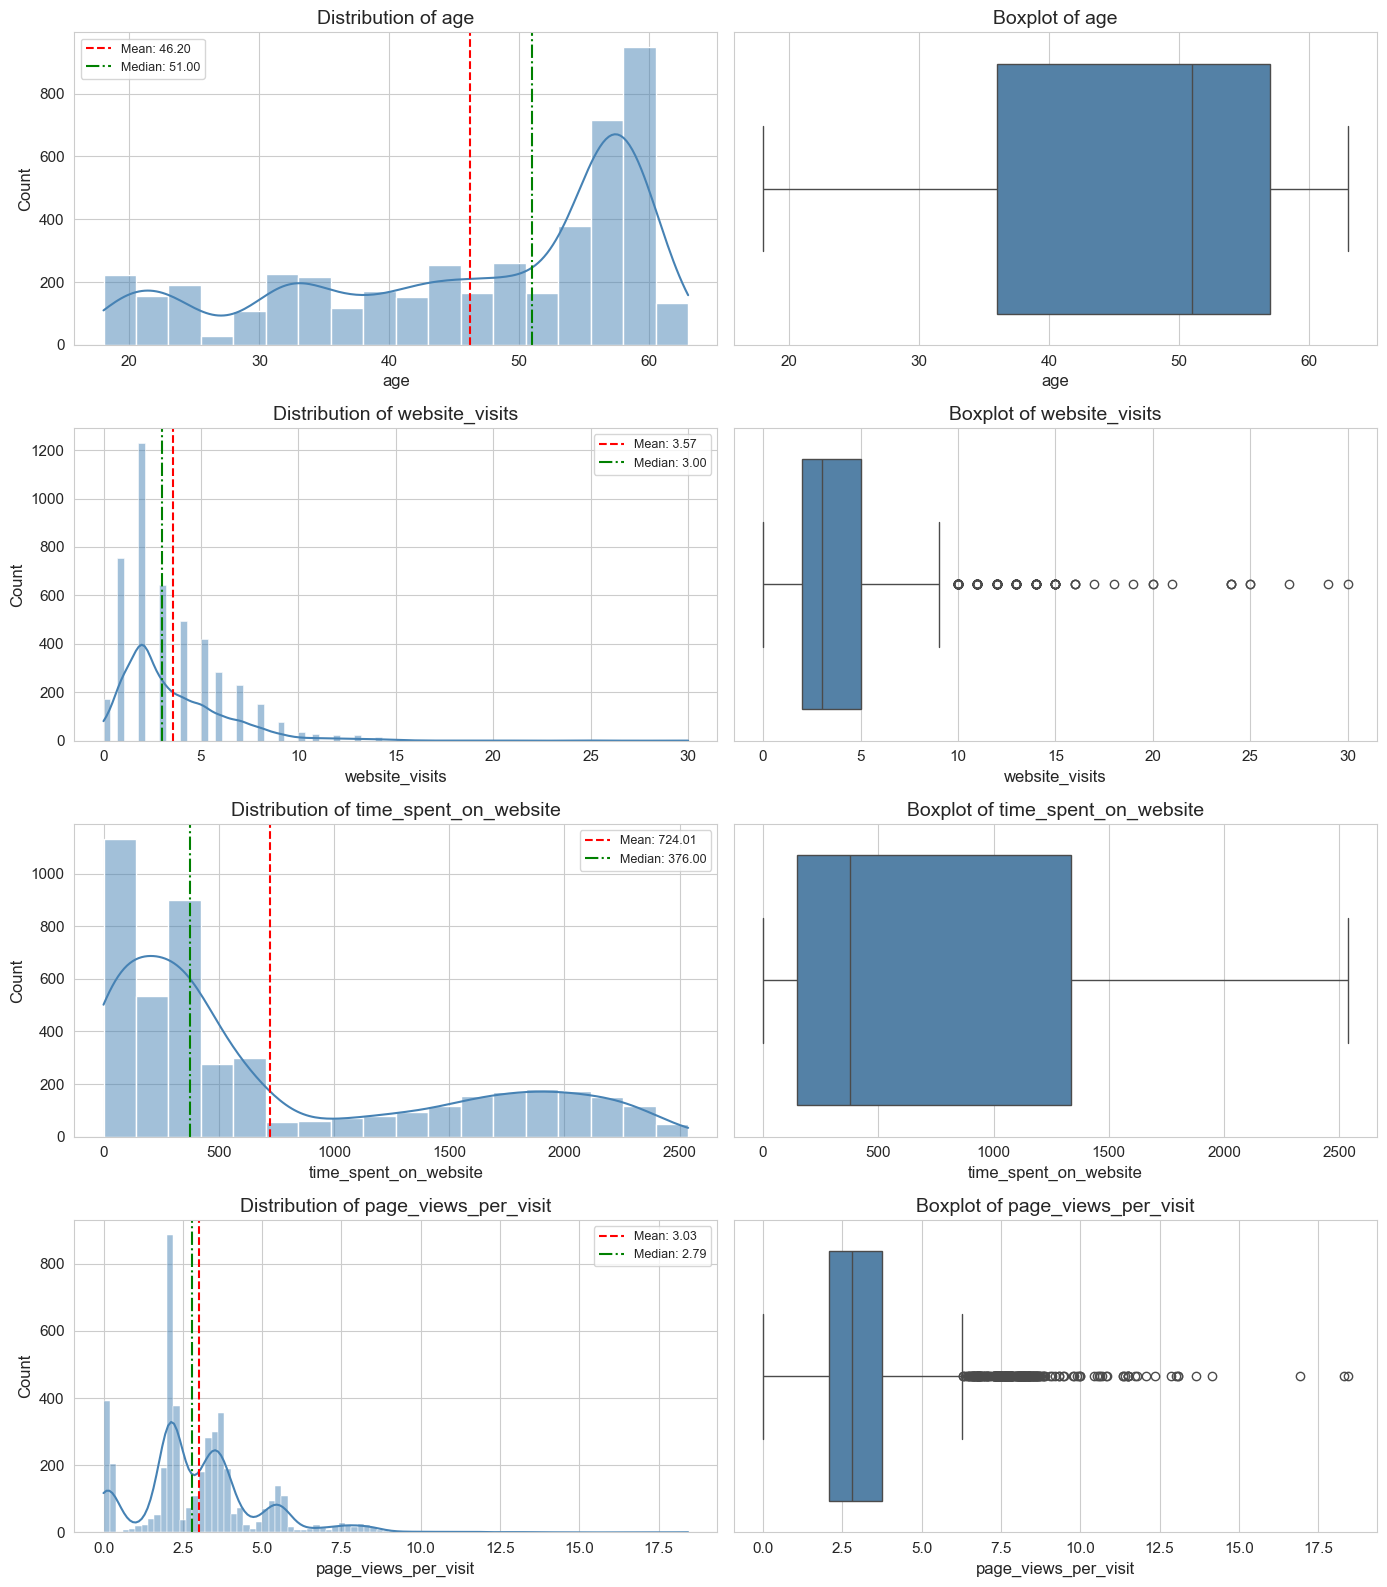

Saved: sec03_numeric_distributions.png


In [10]:
# ------------------------------------------------------------------
# 03a: Numeric feature distributions (histograms + boxplots)
# ------------------------------------------------------------------
numeric_cols = ["age", "website_visits", "time_spent_on_website", "page_views_per_visit"]

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    # Histogram with KDE
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="steelblue", edgecolor="white")
    axes[i, 0].set_title(f"Distribution of {col}")
    axes[i, 0].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.2f}")
    axes[i, 0].axvline(df[col].median(), color="green", linestyle="-.", label=f"Median: {df[col].median():.2f}")
    axes[i, 0].legend(fontsize=9)

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color="steelblue")
    axes[i, 1].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec03_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sec03_numeric_distributions.png")

**Observations — Numeric Features:**

**Row 1, Left — "Distribution of age" (Histogram + KDE)**
* **Purpose:** Show the age distribution of leads
* **Shape:** Left-skewed — bulk of data clusters between 45–60, with a thinner tail toward younger ages. Mean (46.2) < Median (51.0) confirms the left skew.
* **Definition:** Left skew means the majority of values are high, with fewer low values pulling the tail left.
* **Finding:** Lead pool is mostly mid-career (45–60) with a secondary bump around 22–27 (likely students) — two distinct demographic segments.
* **Implication:** Age likely interacts with `current_occupation`. Models should capture that these two age groups may convert at very different rates.
* **Transformation:** Not required. Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are invariant to monotonic transformations — they split on thresholds, so skew doesn't affect them. For Logistic Regression, the StandardScaler in Section 11 handles centering and scaling, which is sufficient.

**Row 1, Right — "Boxplot of age" (Boxplot)**
* **Purpose:** Summarize the five-number summary and flag outliers
* **Shape:** Box spans ~36–57 (IQR=21), median at 51. Whiskers cover full range 18–63. No outlier circles.
* **Finding:** No age outliers — all values are within a reasonable range.
* **Implication:** No outlier treatment needed for age.

**Row 2, Left — "Distribution of website_visits" (Histogram + KDE)**
* **Purpose:** Show how frequently leads visit the website
* **Shape:** Heavily right-skewed — most leads visit 0–5 times, long tail to 30. Mean (3.57) > Median (3.0).
* **Definition:** Right skew means most values are low, with a few extreme highs pulling the tail right.
* **Finding:** Typical lead visits only a few times. The handful visiting 10+ are unusually engaged.
* **Implication:** High-visit leads in the tail could be strong conversion signals, but bivariate analysis needed to confirm.
* **Transformation:** Not required for tree-based models. For Logistic Regression, StandardScaler is applied. A log transform could normalize this skew, but since our primary models are tree-based and unaffected by skew, we keep the raw values to avoid adding unnecessary complexity.

**Row 2, Right — "Boxplot of website_visits" (Boxplot)**
* **Purpose:** Identify spread and outliers for visit count
* **Shape:** Compact box (Q1=2, Q3=5, IQR=3), median at 3. Multiple outlier circles from ~8 to 30.
* **Definition:** Upper fence = Q3 + 1.5×IQR = 9.5. Anything above is flagged as an outlier.
* **Finding:** Many leads flagged as outliers for high visits — these are genuinely engaged, not data errors.
* **Implication:** Do NOT remove. These likely represent high-intent leads.

**Row 3, Left — "Distribution of time_spent_on_website" (Histogram + KDE)**
* **Purpose:** Show total time (seconds) leads spend on the website
* **Shape:** Right-skewed and bimodal — large peak near 0–500s, second flatter hump around 1,500–2,200s. Mean (724s) is nearly 2× the median (376s).
* **Definition:** A bimodal distribution has two peaks, suggesting two distinct behavioral groups in the data.
* **Finding:** Two clear groups — brief browsers (<500s) and deep engagers (1,000–2,500s). This split likely maps to non-converters vs. converters.
* **Implication:** Probably the most important feature. The bivariate analysis should confirm whether the high-time group converts at a much higher rate.
* **Transformation:** Not required for tree-based models — they naturally find the split point between the two modes. For Logistic Regression, StandardScaler is applied. Avoid log transform here: it would compress the two modes closer together and reduce the very separation that makes this feature predictive.

**Row 3, Right — "Boxplot of time_spent_on_website" (Boxplot)**
* **Purpose:** Show spread and outliers for time on website
* **Shape:** Box spans ~149–1,337s (IQR=1,188), median at 376. No outlier circles — full range 0–2,537 falls within whiskers.
* **Finding:** Enormous variability — some leads spend seconds, others 40+ minutes. Widest IQR of any numeric feature.
* **Implication:** No outlier treatment needed. The high variance gives models a wide signal range to separate converters from non-converters.

**Row 4, Left — "Distribution of page_views_per_visit" (Histogram + KDE)**
* **Purpose:** Show average pages viewed per visit
* **Shape:** Right-skewed, concentrated between 1–5 pages. Mean (3.03) ≈ Median (2.79), indicating mild skew. Thin tail to ~18.
* **Definition:** When mean ≈ median despite a right tail, only a few extreme values exist — not enough to drag the average far.
* **Finding:** Most leads view 1–5 pages. A small number view 10+, indicating deep research behavior.
* **Implication:** Likely less predictive than time on website since the distribution is less clearly bimodal.
* **Transformation:** Not required. Mild skew with mean ≈ median means the distribution is close enough to normal that no correction is needed for any of our models.

**Row 4, Right — "Boxplot of page_views_per_visit" (Boxplot)**
* **Purpose:** Identify outliers for page views
* **Shape:** Compact box (Q1≈2.1, Q3≈3.8, IQR≈1.7), median at ~2.8. Dense cluster of outlier circles from ~6 to ~18.4.
* **Definition:** Upper fence = 3.8 + 1.5×1.7 ≈ 6.35. Values above are flagged as outliers.
* **Finding:** Substantial number of leads with unusually deep browsing — not errors, but leads doing serious research.
* **Implication:** Keep these outliers. Combined with time on website, the engineered `engagement_score` will bundle these signals together.

**Transformation Summary:**
| Feature | Transform Needed? | Reason |
|---------|-------------------|--------|
| `age` | No | Tree models are skew-invariant; StandardScaler handles LR |
| `website_visits` | No | Tree models unaffected; log transform possible but unnecessary complexity |
| `time_spent_on_website` | No | Bimodal shape is a feature, not a problem — don't compress it |
| `page_views_per_visit` | No | Mild skew, mean ≈ median — already well-behaved |

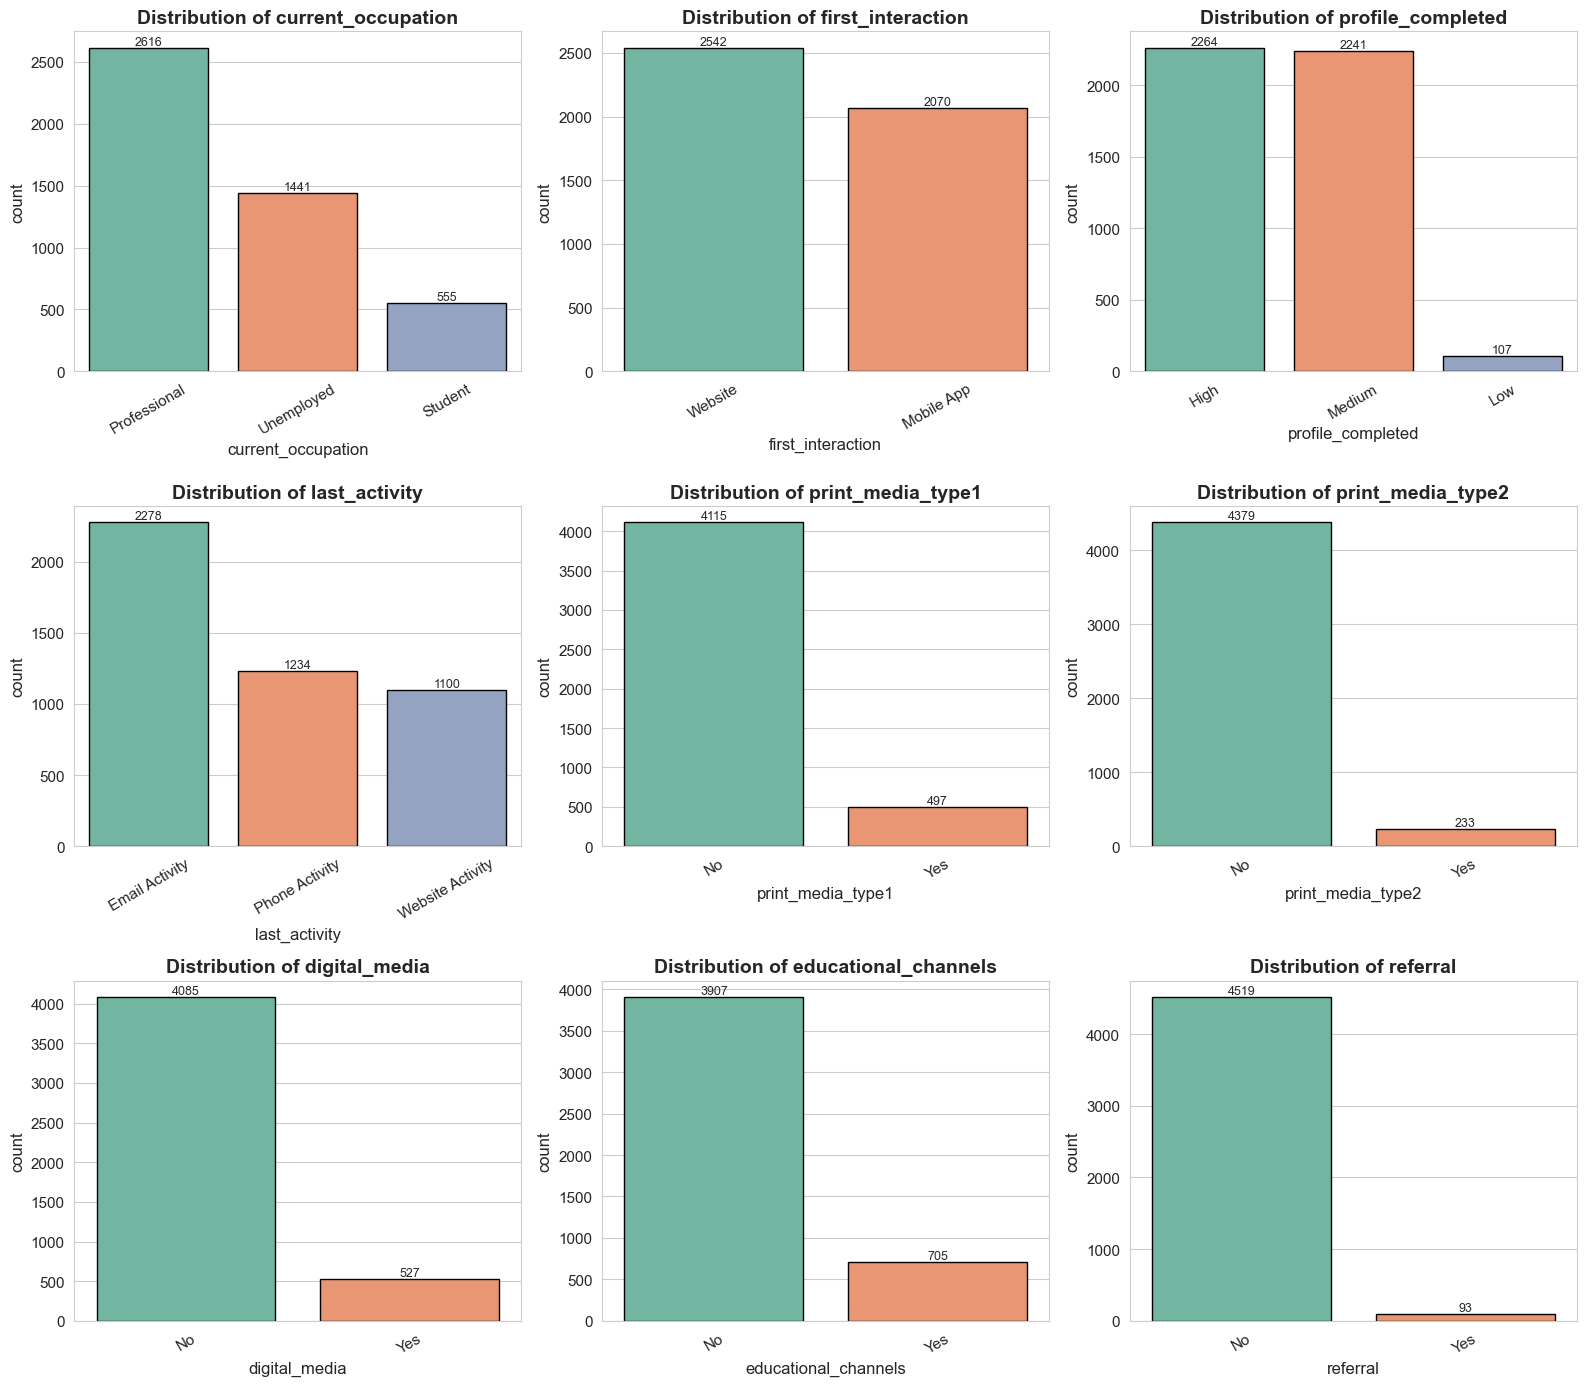

Saved: sec03_categorical_distributions.png


In [11]:
# ------------------------------------------------------------------
# 03b: Categorical feature distributions (count plots)
# ------------------------------------------------------------------
cat_cols = ["current_occupation", "first_interaction", "profile_completed",
            "last_activity", "print_media_type1", "print_media_type2",
            "digital_media", "educational_channels", "referral"]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    ax = axes[i]
    sns.countplot(data=df, x=col, order=order, palette="Set2", ax=ax, edgecolor="black")
    ax.set_title(f"Distribution of {col}", fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    # Add count labels
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec03_categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sec03_categorical_distributions.png")

**Observations — Categorical Features:**

**Row 1, Left — "Distribution of current_occupation" (Count Plot)**
* **Purpose:** Show the breakdown of leads by occupation type
* **Shape:** Three categories with clear hierarchy — Professional (2,616), Unemployed (1,441), Student (555)
* **Finding:** Professionals dominate at 56.7% of all leads. Students are the smallest group at 12%.
* **Implication:** Model predictions will be most informed by Professional behavior due to sample size. Conversion rates by occupation (bivariate analysis) will reveal whether the smallest group (Students) actually converts at a higher rate despite fewer leads.

**Row 1, Center — "Distribution of first_interaction" (Count Plot)**
* **Purpose:** Show which channel leads first used to discover ExtraaLearn
* **Shape:** Two categories, relatively balanced — Website (2,542) vs. Mobile App (2,070)
* **Finding:** Website edges out Mobile App by ~10% (55.1% vs. 44.9%), but the split is fairly even.
* **Implication:** Neither channel overwhelmingly dominates lead generation. The bivariate analysis will determine if one channel produces higher-quality (more convertible) leads than the other.

**Row 1, Right — "Distribution of profile_completed" (Count Plot)**
* **Purpose:** Show how much of their profile leads have filled out
* **Shape:** High (2,264) and Medium (2,241) are nearly tied, Low (107) is negligible
* **Finding:** 97.7% of leads have Medium or High profile completion. Only 2.3% are Low.
* **Implication:** The Low category has very few observations, which could make it unreliable for modeling. The real question is whether High converts better than Medium — that's where the actionable difference lies.

**Row 2, Left — "Distribution of last_activity" (Count Plot)**
* **Purpose:** Show the most recent interaction type between the lead and ExtraaLearn
* **Shape:** Email Activity leads (2,278), followed by Phone Activity (1,234) and Website Activity (1,100)
* **Finding:** Email is the dominant last touchpoint at 49.4%. Phone and Website are roughly equal.
* **Implication:** The bivariate analysis will reveal which last activity type actually drives the highest conversion — the most common touchpoint isn't necessarily the most effective one.

**Row 2, Center — "Distribution of print_media_type1" (Count Plot)**
* **Purpose:** Show how many leads saw ExtraaLearn's newspaper ad
* **Shape:** Extremely imbalanced — No (4,115) vs. Yes (497). Only 10.8% were exposed.
* **Finding:** The vast majority of leads did not see the newspaper ad.
* **Implication:** Small exposed group limits statistical power. If newspaper exposure shows a meaningful conversion lift in bivariate analysis, it's a signal worth pursuing despite the small sample.

**Row 2, Right — "Distribution of print_media_type2" (Count Plot)**
* **Purpose:** Show how many leads saw ExtraaLearn's magazine ad
* **Shape:** Even more imbalanced than newspaper — No (4,379) vs. Yes (233). Only 5.1% were exposed.
* **Finding:** Magazine is the least-used print channel with the smallest exposed group.
* **Implication:** Very small sample of exposed leads (233) means any conversion rate differences should be interpreted cautiously. Models may not get a strong signal from this feature.

**Row 3, Left — "Distribution of digital_media" (Count Plot)**
* **Purpose:** Show how many leads saw ExtraaLearn's digital ads
* **Shape:** Heavily imbalanced — No (4,085) vs. Yes (527). 11.4% were exposed.
* **Finding:** Similar exposure rate to newspaper (~11%), much higher than magazine (~5%).
* **Implication:** Digital media reaches slightly more leads than print. The bivariate lift analysis will show whether digital ads attract higher-quality leads.

**Row 3, Center — "Distribution of educational_channels" (Count Plot)**
* **Purpose:** Show how many leads heard about ExtraaLearn through education forums, threads, or websites
* **Shape:** Imbalanced — No (3,907) vs. Yes (705). 15.3% were exposed.
* **Finding:** Highest exposure rate among all marketing channels — more leads come through educational channels than any other single marketing flag.
* **Implication:** If educational channels also show a high conversion lift, this is the most scalable marketing channel to invest in since it already has the largest reach.

**Row 3, Right — "Distribution of referral" (Count Plot)**
* **Purpose:** Show how many leads came through word-of-mouth referral
* **Shape:** Most extreme imbalance — No (4,519) vs. Yes (93). Only 2.0% were referred.
* **Finding:** Referral is the rarest lead source by far.
* **Implication:** With only 93 referred leads, any conversion rate calculation will have wide confidence intervals. If referrals do convert well, building a referral program could be a high-impact recommendation — but the data is too thin to be conclusive on its own.

**Overall Categorical Summary:**
| Feature | Dominant Category | % of Total | Key Concern |
|---------|------------------|------------|-------------|
| `current_occupation` | Professional | 56.7% | Model heavily trained on this group |
| `first_interaction` | Website | 55.1% | Fairly balanced split |
| `profile_completed` | High | 49.1% | Low category nearly empty (107) |
| `last_activity` | Email Activity | 49.4% | Most common ≠ most effective |
| `print_media_type1` | No | 89.2% | Small exposed group (497) |
| `print_media_type2` | No | 94.9% | Very small exposed group (233) |
| `digital_media` | No | 88.6% | Small exposed group (527) |
| `educational_channels` | No | 84.7% | Largest marketing channel reach (705) |
| `referral` | No | 98.0% | Extremely small sample (93) |

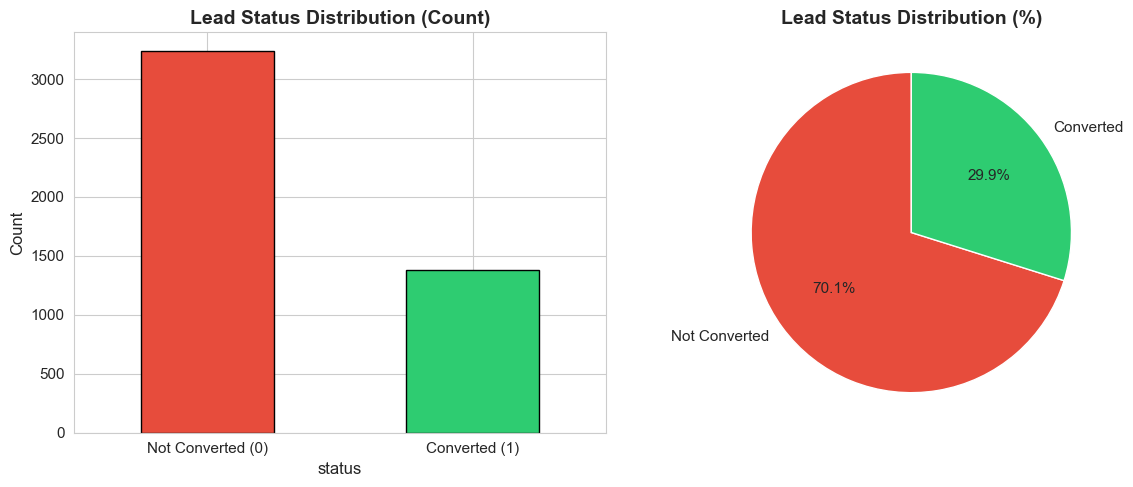

Saved: sec03_target_distribution.png


In [12]:
# ------------------------------------------------------------------
# 03c: Target variable visualization
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ["#e74c3c", "#2ecc71"]
df["status"].value_counts().plot(kind="bar", ax=axes[0], color=colors, edgecolor="black")
axes[0].set_title("Lead Status Distribution (Count)", fontweight="bold")
axes[0].set_xticklabels(["Not Converted (0)", "Converted (1)"], rotation=0)
axes[0].set_ylabel("Count")

# Pie chart
df["status"].value_counts().plot(kind="pie", ax=axes[1], autopct="%1.1f%%",
                                  colors=colors, startangle=90,
                                  labels=["Not Converted", "Converted"])
axes[1].set_ylabel("")
axes[1].set_title("Lead Status Distribution (%)", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec03_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sec03_target_distribution.png")

**Observations — Target Variable:**

**Left — "Lead Status Distribution (Count)" (Bar Chart)**
* **Purpose:** Show the raw count of converted vs. not converted leads
* **Shape:** Clear class imbalance — Not Converted (3,235) is more than double Converted (1,377)
* **Finding:** Roughly a 70/30 split. The majority class (not converted) dominates the dataset.
* **Implication:** A model that predicts "not converted" for every lead would score 70% accuracy while being completely useless. This confirms we must evaluate using Recall and F1, not accuracy.

**Right — "Lead Status Distribution (%)" (Pie Chart)**
* **Purpose:** Show the proportional split between the two classes
* **Shape:** 70.1% Not Converted, 29.9% Converted
* **Finding:** Nearly 1 in 3 leads converts — this is not a rare event problem (like fraud detection at <1%), but it's imbalanced enough that accuracy is misleading.
* **Implication:** The 30% conversion rate is actually a healthy baseline for a lead generation business. The goal isn't to fix a broken funnel — it's to identify *which* leads fall into that 30% so the sales team can prioritize them instead of treating all leads equally.

---
## Section 04 — Exploratory Data Analysis: Bivariate Analysis

Examining how each feature relates to the target variable `status` (converted vs. not converted).

**EDA Questions to address:**
1. How does current occupation affect lead status?
2. Do the first channels of interaction impact lead status?
3. Which way of interaction works best?
4. Which marketing channels have the highest conversion rate?
5. Does profile completion increase chances of conversion?

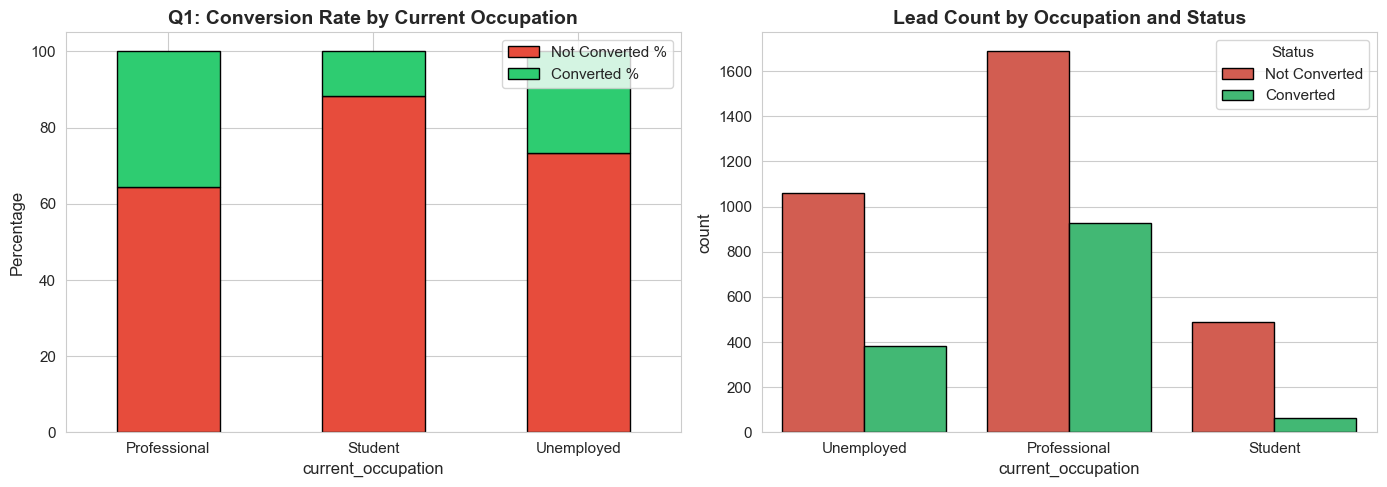

Conversion Rate by Occupation:

                    Total Leads  Converted  Conversion Rate
current_occupation                                         
Professional               2616        929            35.51
Student                     555         65            11.71
Unemployed                 1441        383            26.58

Saved: sec04_q1_occupation_vs_status.png


In [13]:
# ------------------------------------------------------------------
# 04a: Q1 — Current Occupation vs Status
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
ct_occ = pd.crosstab(df["current_occupation"], df["status"], normalize="index").mul(100)
ct_occ.columns = ["Not Converted %", "Converted %"]
ct_occ.plot(kind="bar", stacked=True, ax=axes[0], color=["#e74c3c", "#2ecc71"], edgecolor="black")
axes[0].set_title("Q1: Conversion Rate by Current Occupation", fontweight="bold")
axes[0].set_ylabel("Percentage")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(loc="upper right")

# Count plot with hue
sns.countplot(data=df, x="current_occupation", hue="status", palette={0: "#e74c3c", 1: "#2ecc71"}, ax=axes[1], edgecolor="black")
axes[1].set_title("Lead Count by Occupation and Status", fontweight="bold")
axes[1].legend(title="Status", labels=["Not Converted", "Converted"])

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec04_q1_occupation_vs_status.png", dpi=150, bbox_inches="tight")
plt.show()

# Conversion rates table
occ_conv = df.groupby("current_occupation")["status"].agg(["count", "sum", "mean"])
occ_conv.columns = ["Total Leads", "Converted", "Conversion Rate"]
occ_conv["Conversion Rate"] = (occ_conv["Conversion Rate"] * 100).round(2)
print("Conversion Rate by Occupation:\n")
print(occ_conv)
print("\nSaved: sec04_q1_occupation_vs_status.png")

**Observations — Q1: Current Occupation vs Status:**

**Left — "Q1: Conversion Rate by Current Occupation" (Stacked Bar)**
* **Purpose:** Show the proportion of converted vs. not converted within each occupation group
* **Shape:** Professionals have the largest green (converted) segment at ~35%, Unemployed at ~27%, Students at ~11%
* **Finding:** Professionals convert at 3× the rate of Students (35.5% vs. 11.7%). Unemployed fall in between at 26.6%.
* **Implication:** Occupation is a strong predictor of conversion. The Professional-to-Student gap is too large to be random — the chi-square test in Section 04h will confirm statistical significance.

**Right — "Lead Count by Occupation and Status" (Grouped Bar)**
* **Purpose:** Show the raw volume of converted and not converted leads per occupation
* **Shape:** Professionals dominate both in total volume (~1,690 not converted, ~930 converted) and in absolute conversions. Students have the fewest leads overall (~490 not converted, ~65 converted).
* **Finding:** Even though Professionals have the most leads, they also convert at the highest rate — it's not just a volume effect. Students are both the smallest group and the least likely to convert.
* **Implication:** The sales team should prioritize Professional leads — they bring both volume and quality. Students at 11.7% conversion may not justify heavy outreach unless the cost per lead is very low.

**Conversion Rate Table:**
| Occupation | Total Leads | Converted | Rate |
|------------|-------------|-----------|------|
| Professional | 2,616 | 929 | 35.5% |
| Unemployed | 1,441 | 383 | 26.6% |
| Student | 555 | 65 | 11.7% |

**Key Takeaway:** This supports the hypothesis that ability to pay drives conversion — Professionals likely have personal income or employer education budgets, Unemployed may be investing in reskilling to re-enter the workforce (moderate motivation, tighter budget), and Students face the most financial friction. This reinforces our future data recommendation to capture income-level proxies and employer-sponsored education flags.

**Observation — Q1: Current Occupation vs Status:**
- Compare conversion rates across Professionals, Students, and Unemployed.
- Identify which occupation group is the most valuable lead segment for ExtraaLearn.

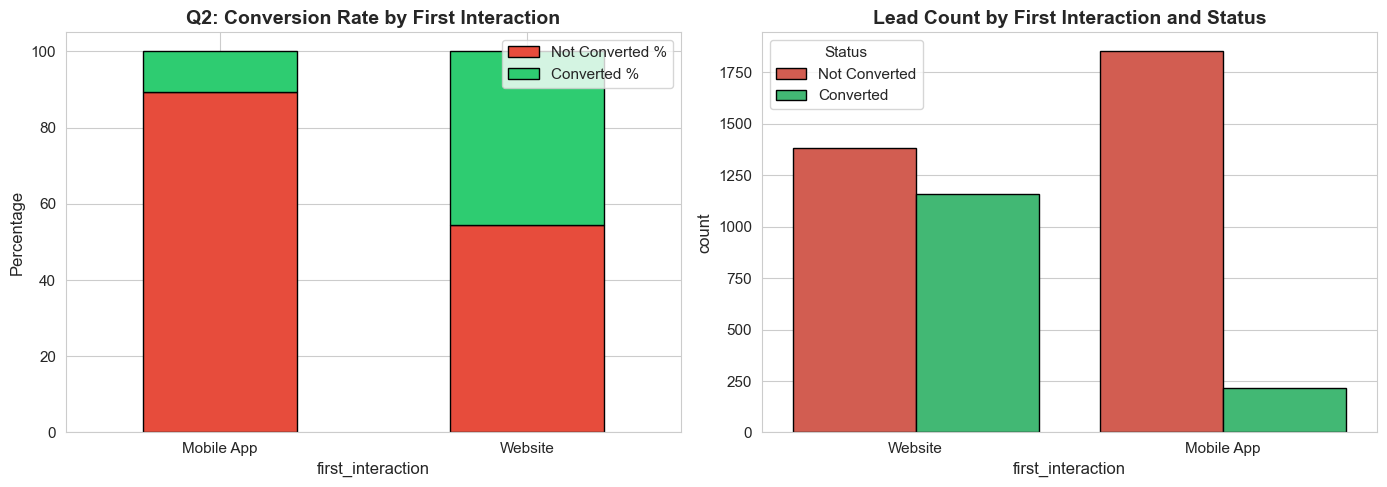

Conversion Rate by First Interaction:

                   Total Leads  Converted  Conversion Rate
first_interaction                                         
Mobile App                2070        218            10.53
Website                   2542       1159            45.59

Saved: sec04_q2_first_interaction_vs_status.png


In [14]:
# ------------------------------------------------------------------
# 04b: Q2 — First Interaction Channel vs Status
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_fi = pd.crosstab(df["first_interaction"], df["status"], normalize="index").mul(100)
ct_fi.columns = ["Not Converted %", "Converted %"]
ct_fi.plot(kind="bar", stacked=True, ax=axes[0], color=["#e74c3c", "#2ecc71"], edgecolor="black")
axes[0].set_title("Q2: Conversion Rate by First Interaction", fontweight="bold")
axes[0].set_ylabel("Percentage")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

sns.countplot(data=df, x="first_interaction", hue="status", palette={0: "#e74c3c", 1: "#2ecc71"}, ax=axes[1], edgecolor="black")
axes[1].set_title("Lead Count by First Interaction and Status", fontweight="bold")
axes[1].legend(title="Status", labels=["Not Converted", "Converted"])

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec04_q2_first_interaction_vs_status.png", dpi=150, bbox_inches="tight")
plt.show()

fi_conv = df.groupby("first_interaction")["status"].agg(["count", "sum", "mean"])
fi_conv.columns = ["Total Leads", "Converted", "Conversion Rate"]
fi_conv["Conversion Rate"] = (fi_conv["Conversion Rate"] * 100).round(2)
print("Conversion Rate by First Interaction:\n")
print(fi_conv)
print("\nSaved: sec04_q2_first_interaction_vs_status.png")

**Observations — Q2: First Interaction vs Status:**

**Left — "Q2: Conversion Rate by First Interaction" (Stacked Bar)**
* **Purpose:** Show the conversion proportion within each first interaction channel
* **Shape:** Website has a large green (converted) segment at ~45%, Mobile App's green sliver is only ~10%
* **Finding:** Website converts at 4.3× the rate of Mobile App (45.6% vs. 10.5%). This is the single largest conversion gap we've seen across any feature so far.
* **Implication:** The first interaction channel is likely one of the strongest predictors in the model. This gap is too dramatic to ignore.

**Right — "Lead Count by First Interaction and Status" (Grouped Bar)**
* **Purpose:** Show raw volumes of converted and not converted per channel
* **Shape:** Website has ~1,380 not converted and ~1,160 converted — nearly balanced. Mobile App has ~1,850 not converted but only ~220 converted — heavily lopsided.
* **Finding:** Website produces 5.3× more absolute conversions than Mobile App (1,159 vs. 218), despite only having 23% more total leads. Website wins on both rate and volume.
* **Implication:** Mobile App brings nearly as many leads as Website (2,070 vs. 2,542) but converts at a fraction of the rate. This raises a critical question: is the Mobile App experience itself the problem (poor UX, missing information, harder to browse), or does the app simply attract a different, lower-intent audience?

**Conversion Rate Table:**
| Channel | Total Leads | Converted | Rate |
|---------|-------------|-----------|------|
| Website | 2,542 | 1,159 | 45.6% |
| Mobile App | 2,070 | 218 | 10.5% |

**Key Takeaway:** This is actionable right now — even before modeling. ExtraaLearn should audit the Mobile App experience against the Website to identify what's different. If the content and flow are similar, then app users are likely a lower-intent segment (casual browsers). If the experiences differ significantly, fixing the app could unlock conversions from nearly half the lead pool. Either way, this should be a top recommendation: investigate why Mobile App converts at less than a quarter of Website's rate, and add a future data recommendation to track which device/platform leads use throughout their journey (not just first interaction).

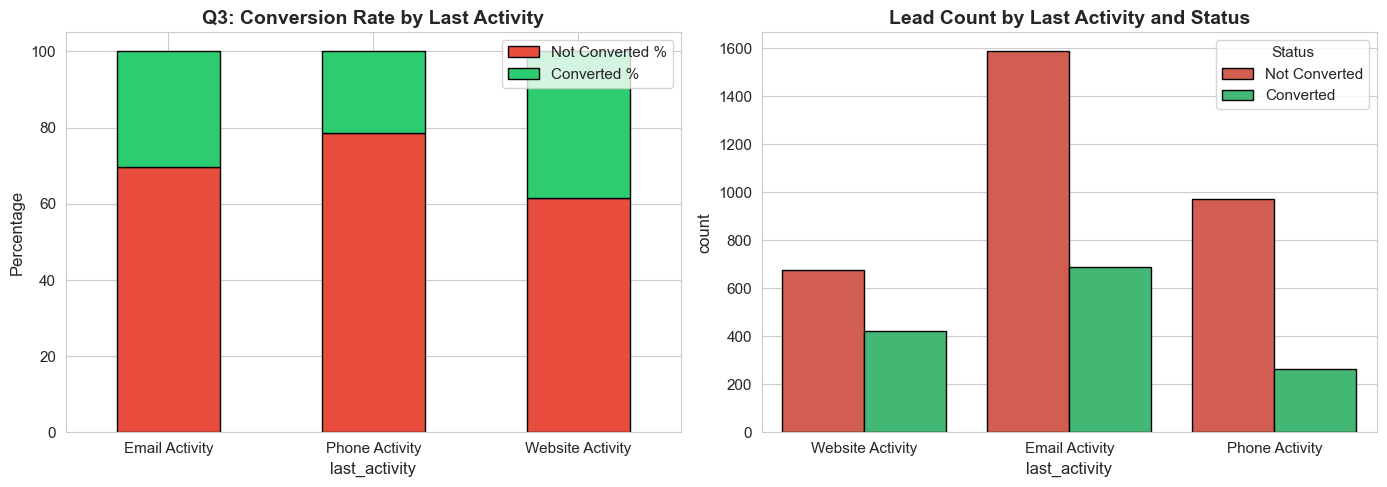

Conversion Rate by Last Activity:

                  Total Leads  Converted  Conversion Rate
last_activity                                            
Email Activity           2278        691            30.33
Phone Activity           1234        263            21.31
Website Activity         1100        423            38.45

Saved: sec04_q3_last_activity_vs_status.png


In [15]:
# ------------------------------------------------------------------
# 04c: Q3 — Last Activity (Interaction Mode) vs Status
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_la = pd.crosstab(df["last_activity"], df["status"], normalize="index").mul(100)
ct_la.columns = ["Not Converted %", "Converted %"]
ct_la.plot(kind="bar", stacked=True, ax=axes[0], color=["#e74c3c", "#2ecc71"], edgecolor="black")
axes[0].set_title("Q3: Conversion Rate by Last Activity", fontweight="bold")
axes[0].set_ylabel("Percentage")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

sns.countplot(data=df, x="last_activity", hue="status", palette={0: "#e74c3c", 1: "#2ecc71"}, ax=axes[1], edgecolor="black")
axes[1].set_title("Lead Count by Last Activity and Status", fontweight="bold")
axes[1].legend(title="Status", labels=["Not Converted", "Converted"])

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec04_q3_last_activity_vs_status.png", dpi=150, bbox_inches="tight")
plt.show()

la_conv = df.groupby("last_activity")["status"].agg(["count", "sum", "mean"])
la_conv.columns = ["Total Leads", "Converted", "Conversion Rate"]
la_conv["Conversion Rate"] = (la_conv["Conversion Rate"] * 100).round(2)
print("Conversion Rate by Last Activity:\n")
print(la_conv)
print("\nSaved: sec04_q3_last_activity_vs_status.png")

**Observations — Q3: Last Activity vs Status:**

**Left — "Q3: Conversion Rate by Last Activity" (Stacked Bar)**
* **Purpose:** Show conversion proportion within each last interaction type
* **Shape:** Website Activity has the largest green segment at approx. 38%, Email Activity at approx. 30%, Phone Activity the smallest at approx. 21%
* **Finding:** Website Activity converts at nearly 2x the rate of Phone Activity (38.5% vs. 21.3%). Email sits in the middle at 30.3%.
* **Implication:** The last touchpoint matters — leads whose final interaction was on the website are the most likely to convert.

**Right — "Lead Count by Last Activity and Status" (Grouped Bar)**
* **Purpose:** Show raw volumes of converted and not converted per activity type
* **Shape:** Email Activity has the highest total volume (approx. 1,600 not converted, approx. 690 converted). Website Activity has fewer total leads but a more favorable ratio (approx. 680 not converted, approx. 420 converted). Phone Activity has the fewest conversions (approx. 260).
* **Finding:** Email Activity produces the most absolute conversions (691) due to sheer volume, but Website Activity is the most *efficient* channel at 38.5%. Phone Activity underperforms on both rate and volume.
* **Implication:** The sales team should be cautious about over-relying on phone-based follow-ups — they have the lowest conversion rate. Website-based interactions (live chat, profile updates) appear more effective as a final touchpoint.

**Conversion Rate Table:**
| Last Activity | Total Leads | Converted | Rate |
|---------------|-------------|-----------|------|
| Website Activity | 1,100 | 423 | 38.5% |
| Email Activity | 2,278 | 691 | 30.3% |
| Phone Activity | 1,234 | 263 | 21.3% |

**Key Takeaway:** There's a consistent theme emerging — website-based interactions outperform other channels (both as first interaction in Q2 and as last activity here). This suggests leads who engage digitally at their own pace convert better than those who require human outreach. Phone activity may actually signal a lower-intent lead who needs more convincing, or it could indicate the phone experience itself is less effective at closing. ExtraaLearn should consider investing in the website experience (live chat, better content, smoother checkout) over expanding the phone sales team. A future project could model which specific leads would benefit from a phone call vs. digital nurturing, so the sales team's time is spent on leads where calls actually move the needle.

Q4: Marketing Channel Conversion Rates:

             Channel  Exposed (Yes)  Conv Rate (Exposed)  Conv Rate (Not Exposed)  Lift
   print_media_type1            497                31.99                    29.60  2.39
   print_media_type2            233                32.19                    29.73  2.46
       digital_media            527                31.88                    29.60  2.28
educational_channels            705                27.94                    30.20 -2.26
            referral             93                67.74                    29.08 38.66


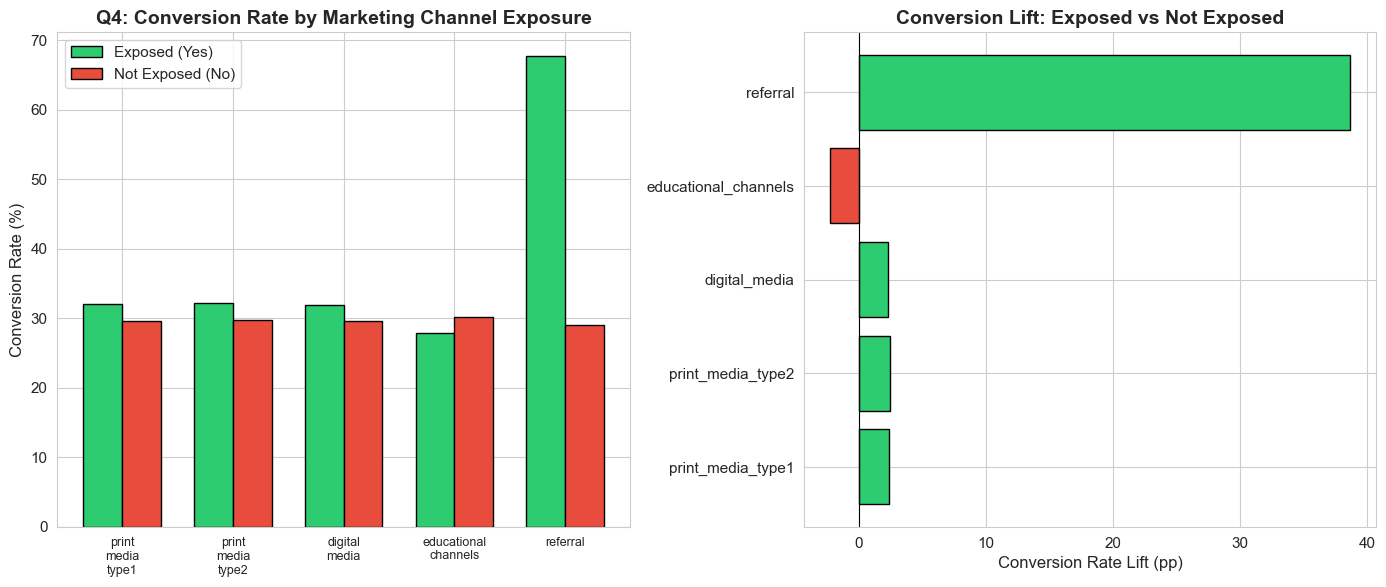


Saved: sec04_q4_marketing_channels.png, sec04_channel_conversion_rates.csv


In [16]:
# ------------------------------------------------------------------
# 04d: Q4 — Marketing Channels Conversion Rates
# ------------------------------------------------------------------
channel_cols = ["print_media_type1", "print_media_type2", "digital_media",
                "educational_channels", "referral"]

channel_data = []
for col in channel_cols:
    yes_mask = (df[col] == "Yes") if df[col].dtype == "object" else (df[col] == 1)
    no_mask = ~yes_mask
    yes_conv = df[yes_mask]["status"].mean() * 100
    no_conv = df[no_mask]["status"].mean() * 100
    total_exposed = yes_mask.sum()
    channel_data.append({
        "Channel": col,
        "Exposed (Yes)": total_exposed,
        "Conv Rate (Exposed)": round(yes_conv, 2),
        "Conv Rate (Not Exposed)": round(no_conv, 2),
        "Lift": round(yes_conv - no_conv, 2)
    })

channel_df = pd.DataFrame(channel_data)
print("Q4: Marketing Channel Conversion Rates:\n")
print(channel_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Conversion rate comparison
x_idx = np.arange(len(channel_cols))
width = 0.35
axes[0].bar(x_idx - width/2, channel_df["Conv Rate (Exposed)"], width, label="Exposed (Yes)", color="#2ecc71", edgecolor="black")
axes[0].bar(x_idx + width/2, channel_df["Conv Rate (Not Exposed)"], width, label="Not Exposed (No)", color="#e74c3c", edgecolor="black")
axes[0].set_xticks(x_idx)
axes[0].set_xticklabels([c.replace("_", "\n") for c in channel_cols], fontsize=9)
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].set_title("Q4: Conversion Rate by Marketing Channel Exposure", fontweight="bold")
axes[0].legend()

# Lift chart
colors_lift = ["#2ecc71" if x > 0 else "#e74c3c" for x in channel_df["Lift"]]
axes[1].barh(channel_df["Channel"], channel_df["Lift"], color=colors_lift, edgecolor="black")
axes[1].set_xlabel("Conversion Rate Lift (pp)")
axes[1].set_title("Conversion Lift: Exposed vs Not Exposed", fontweight="bold")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec04_q4_marketing_channels.png", dpi=150, bbox_inches="tight")
plt.show()

channel_df.to_csv(f"{DATA_DIR}sec04_channel_conversion_rates.csv", index=False)
print("\nSaved: sec04_q4_marketing_channels.png, sec04_channel_conversion_rates.csv")

**Observations — Q4: Marketing Channels vs Status:**

**Left — "Q4: Conversion Rate by Marketing Channel Exposure" (Grouped Bar)**
* **Purpose:** Compare conversion rates between leads exposed (Yes) and not exposed (No) to each marketing channel
* **How Calculated:** Conversion rate = (number of converted leads in group / total leads in group) x 100. For example, referral exposed: 63 converted out of 93 total exposed leads = (63/93) x 100 = 67.7%.
* **Shape:** Four channels (print 1, print 2, digital, educational) show nearly identical bars — exposed and not exposed convert at roughly the same rate (approx. 28–32%). Referral is the dramatic outlier with a massive gap: 67.7% exposed vs. 29.1% not exposed.
* **Finding:** Print, digital, and educational channels show almost no difference in conversion rates between exposed and unexposed leads. Referral stands alone with a conversion rate more than 2x the baseline.
* **Implication:** Most marketing channels don't appear to drive conversions — exposure to newspaper, magazine, digital, or educational ads has minimal impact on whether a lead converts.

**Right — "Conversion Lift: Exposed vs Not Exposed" (Horizontal Bar)**
* **Purpose:** Show the percentage point (pp) difference in conversion rate between exposed and not exposed for each channel
* **How Calculated:** Lift = conversion rate of exposed group minus conversion rate of unexposed group. For example, referral lift = 67.7% - 29.1% = +38.7pp. A positive lift means exposure is associated with higher conversion. A negative lift means exposure is associated with *lower* conversion.
* **Shape:** Referral dominates at +38.7pp. Print 1, print 2, and digital show tiny positive lifts (+2.3 to +2.5pp). Educational channels is the only negative lift at -2.3pp.
* **Finding:** Referral has an extraordinary +38.7pp lift. The other four channels hover near zero — essentially noise.
* **Implication:** Educational channels actually has a slight *negative* association with conversion, meaning leads who heard about ExtraaLearn through forums or educational websites convert at a slightly lower rate than those who didn't.

**Conversion Rate Table:**
| Channel | Exposed (Yes) | Not Exposed (No) | Conv Rate (Exposed) | Conv Rate (Not Exposed) | Lift (pp) |
|---------|---------------|-------------------|---------------------|-------------------------|-----------|
| referral | 93 | 4,519 | 67.7% (63/93) | 29.1% (1,314/4,519) | +38.7 |
| print_media_type2 | 233 | 4,379 | 32.2% (75/233) | 29.7% (1,302/4,379) | +2.5 |
| print_media_type1 | 497 | 4,115 | 32.0% (159/497) | 29.6% (1,218/4,115) | +2.4 |
| digital_media | 527 | 4,085 | 31.9% (168/527) | 29.6% (1,209/4,085) | +2.3 |
| educational_channels | 705 | 3,907 | 27.9% (197/705) | 30.2% (1,180/3,907) | -2.3 |

*Verify: Each row's Exposed + Not Exposed = 4,612 total leads. Conversion rate = converted count / group total x 100.*

**Key Takeaways:**
* **Referral is by far the highest-converting channel** at 67.7% — but with only 93 leads, the sample is small. This is the caveat we flagged in the univariate analysis. Even so, a 38.7pp lift is so large that it's very unlikely to be pure noise. The chi-square test will confirm significance.
* **Print, digital, and educational channels show negligible lift** (under 3pp in either direction). This suggests these channels generate awareness but don't meaningfully change a lead's likelihood of converting. ExtraaLearn may be spending marketing budget on channels that bring traffic but not paying customers.
* **The business recommendation is clear:** Invest heavily in building a referral program. If ExtraaLearn can scale referrals from 93 to even 500 leads while maintaining a similar conversion rate, that's far more valuable than any print or digital campaign currently running.
* **Caution on educational channels:** The -2.3pp lift doesn't mean educational channels *cause* lower conversion — it could mean leads from forums are comparison-shopping across multiple EdTech providers and are harder to close. A future study should audit which specific forums, threads, and educational websites are driving this traffic and what content or sentiment about ExtraaLearn exists there — are leads seeing negative reviews, pricing complaints, or competitor comparisons that discourage conversion?

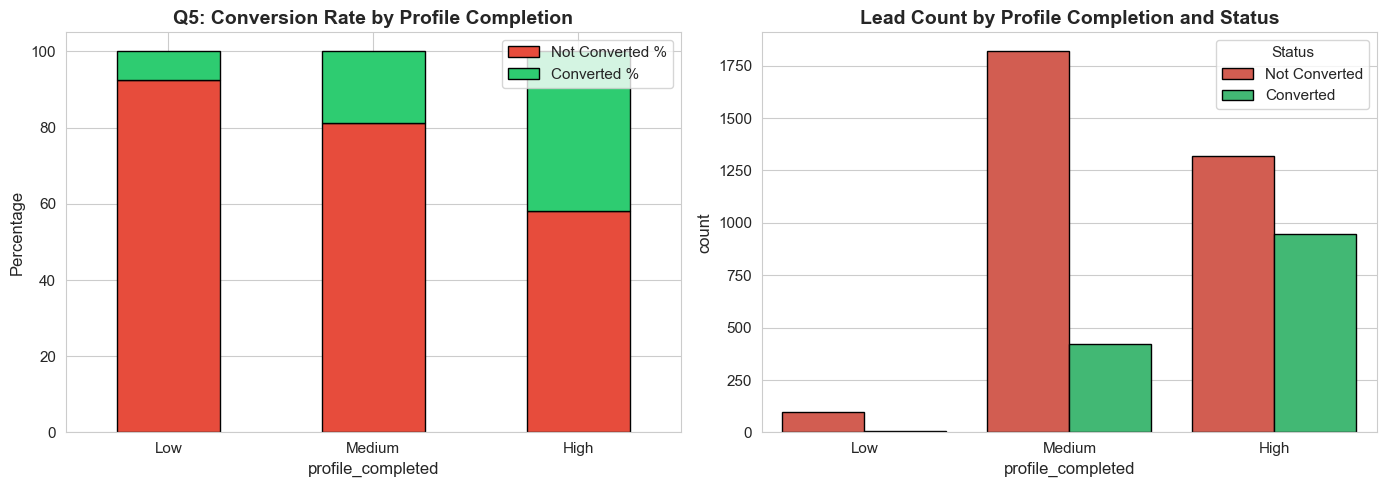

Conversion Rate by Profile Completion:

                   Total Leads  Converted  Conversion Rate
profile_completed                                         
Low                        107          8             7.48
Medium                    2241        423            18.88
High                      2264        946            41.78

Saved: sec04_q5_profile_completion_vs_status.png


In [17]:
# ------------------------------------------------------------------
# 04e: Q5 — Profile Completion vs Status
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ordered categories
profile_order = ["Low", "Medium", "High"]

ct_pc = pd.crosstab(df["profile_completed"], df["status"], normalize="index").mul(100)
ct_pc = ct_pc.reindex(profile_order)
ct_pc.columns = ["Not Converted %", "Converted %"]
ct_pc.plot(kind="bar", stacked=True, ax=axes[0], color=["#e74c3c", "#2ecc71"], edgecolor="black")
axes[0].set_title("Q5: Conversion Rate by Profile Completion", fontweight="bold")
axes[0].set_ylabel("Percentage")
axes[0].set_xticklabels(profile_order, rotation=0)

sns.countplot(data=df, x="profile_completed", hue="status",
              order=profile_order, palette={0: "#e74c3c", 1: "#2ecc71"}, ax=axes[1], edgecolor="black")
axes[1].set_title("Lead Count by Profile Completion and Status", fontweight="bold")
axes[1].legend(title="Status", labels=["Not Converted", "Converted"])

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec04_q5_profile_completion_vs_status.png", dpi=150, bbox_inches="tight")
plt.show()

pc_conv = df.groupby("profile_completed")["status"].agg(["count", "sum", "mean"]).reindex(profile_order)
pc_conv.columns = ["Total Leads", "Converted", "Conversion Rate"]
pc_conv["Conversion Rate"] = (pc_conv["Conversion Rate"] * 100).round(2)
print("Conversion Rate by Profile Completion:\n")
print(pc_conv)
print("\nSaved: sec04_q5_profile_completion_vs_status.png")

**Observations — Q5: Profile Completion vs Status:**

**Left — "Q5: Conversion Rate by Profile Completion" (Stacked Bar)**
* **Purpose:** Show conversion proportion within each profile completion level (Low = 0–50%, Medium = 50–75%, High = 75–100%)
* **Shape:** Clear staircase pattern — the green (converted) segment grows from left to right. Low has a tiny sliver (approx. 7%), Medium shows a moderate segment (approx. 19%), High has the largest (approx. 42%).
* **Finding:** Conversion rate increases dramatically with profile completion: High converts at 5.6x the rate of Low (41.8% vs. 7.5%) and 2.2x the rate of Medium (41.8% vs. 18.9%).
* **Implication:** Profile completion is one of the strongest predictors of conversion. There is a clear monotonic relationship — more profile = more conversion.

**Right — "Lead Count by Profile Completion and Status" (Grouped Bar)**
* **Purpose:** Show raw volumes of converted and not converted per profile completion level
* **Shape:** Low is nearly invisible (approx. 100 not converted, approx. 8 converted). Medium has the highest not-converted count (approx. 1,800) with a modest converted count (approx. 400). High has the most balanced ratio (approx. 1,320 not converted, approx. 950 converted).
* **Finding:** High profile completion produces 2.2x more absolute conversions than Medium (946 vs. 423) despite having nearly the same total leads (2,264 vs. 2,241). Low has almost no conversions — only 8 out of 107.
* **Implication:** The jump from Medium to High is where the real conversion gains happen. Medium leads are the biggest opportunity — there are 2,241 of them converting at only 18.9%. If ExtraaLearn can nudge even a fraction of those to complete their profiles to High, the conversion rate could roughly double for those leads.

**Conversion Rate Table:**
| Profile Level | Definition | Total Leads | Converted | Rate |
|---------------|------------|-------------|-----------|------|
| High | 75–100% filled | 2,264 | 946 (946/2,264) | 41.8% |
| Medium | 50–75% filled | 2,241 | 423 (423/2,241) | 18.9% |
| Low | 0–50% filled | 107 | 8 (8/107) | 7.5% |

**Key Takeaways:**
* **Profile completion is likely a proxy for intent** — leads who invest the time to fill out 75%+ of their profile are signaling serious interest. It's not that completing the profile *causes* conversion; it's that high-intent leads do both.
* **The Medium-to-High gap is the actionable opportunity.** There are 2,241 Medium leads sitting at 18.9% conversion. UX interventions to push them toward High completion (progress bars, email nudges, incentives like "complete your profile to unlock a free webinar") could move a meaningful number into the High-conversion bracket.
* **Low profile leads (107) are essentially non-converters** at 7.5%. These may be leads who bounced early or created a profile accidentally. They're likely not worth sales team effort unless they re-engage.
* **This ties back to our future data recommendation** (item 6 in context.md) — we need to know how long the profile is and which specific fields get abandoned. If Medium leads are dropping off at a particular field (e.g., phone number, employer), removing or making that field optional could reduce friction.

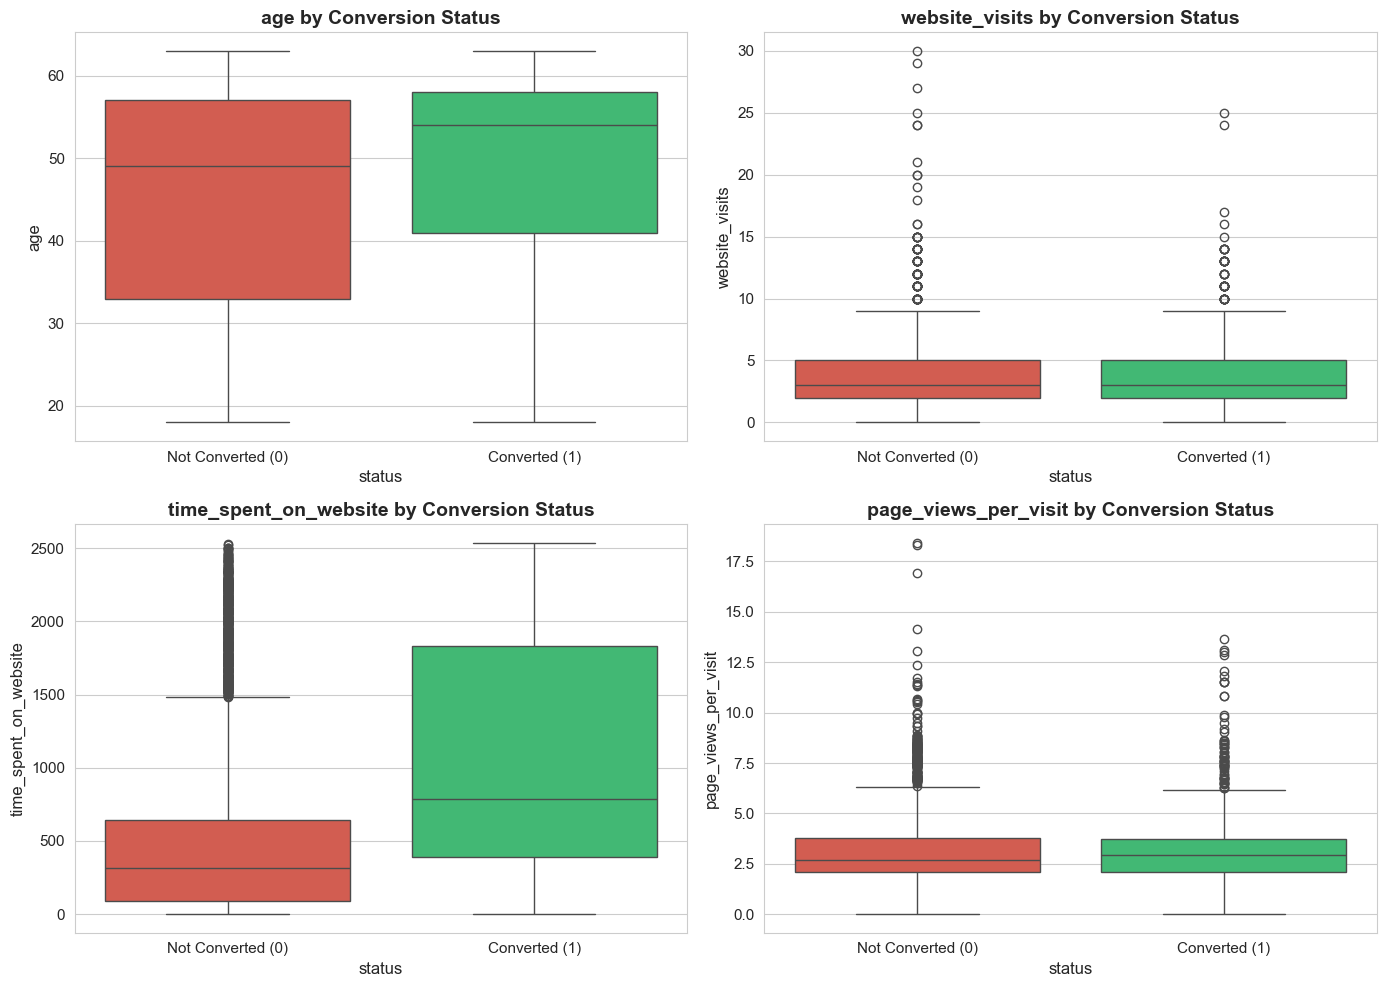

Saved: sec04_numeric_vs_status_boxplots.png


In [19]:
# ------------------------------------------------------------------
# 04f: Numeric Features vs Status (boxplots)
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x="status", y=col, palette={"0": "#e74c3c", "1": "#2ecc71"},
                ax=axes[i])
    axes[i].set_title(f"{col} by Conversion Status", fontweight="bold")
    axes[i].set_xticklabels(["Not Converted (0)", "Converted (1)"])

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec04_numeric_vs_status_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sec04_numeric_vs_status_boxplots.png")

**Observations — Numeric Features by Conversion Status (Boxplots):**

**Row 1, Left — "age by Conversion Status" (Boxplot)**
* **Purpose:** Compare age distributions between converted and not converted leads
* **Shape:** Both boxes span a similar range (approx. 35–57), but the converted group's median (approx. 51) sits slightly higher than not converted (approx. 49). The converted box is also shifted slightly upward overall.
* **Finding:** The difference in age between the two groups is small. Both groups span the full 18–63 range with similar IQRs.
* **Implication:** Age alone is a weak separator of converters vs. non-converters. The distributions overlap heavily, meaning a model can't rely on age by itself. However, age combined with occupation (e.g., older professionals) may form a stronger signal — this is where feature interactions matter.

**Row 1, Right — "website_visits by Conversion Status" (Boxplot)**
* **Purpose:** Compare website visit frequency between converted and not converted leads
* **Shape:** Nearly identical boxes — both groups have a median around 3, IQR from approx. 2–5, and similar outlier patterns extending to 25–30.
* **Finding:** Website visit count does not meaningfully differ between converters and non-converters. Both groups visit roughly the same number of times.
* **Implication:** This is surprising — you might expect converters to visit more often. But visit *count* appears to be noise. What matters more is what they do during those visits (time spent, pages viewed), not how many times they come back. This confirms that `website_visits` will likely rank low in feature importance.

**Row 2, Left — "time_spent_on_website by Conversion Status" (Boxplot)**
* **Purpose:** Compare total time on website between converted and not converted leads
* **Shape:** Dramatically different distributions. Not converted has a compact box clustered low (median approx. 300s, Q3 approx. 600s) with a dense cluster of outliers above 1,400s. Converted has a much taller box (median approx. 800s, Q3 approx. 1,850s) spanning nearly the full range.
* **Finding:** This is the strongest visual separator of any numeric feature. Converted leads spend substantially more time on the website — their median is roughly 2.5x the non-converted median. The not-converted outliers above 1,400s likely represent the "almost converters" who engaged deeply but didn't close.
* **Implication:** Confirms what the bimodal distribution in Section 03 suggested — the two humps map to non-converters (low time) and converters (high time). This will almost certainly be the top feature in every model. The business action is clear: leads crossing a time threshold (perhaps 10–15 minutes) should trigger an automatic alert to the sales team for immediate follow-up while the lead is still engaged.

**Row 2, Right — "page_views_per_visit by Conversion Status" (Boxplot)**
* **Purpose:** Compare average page views per visit between converted and not converted leads
* **Shape:** Very similar core distributions — both medians sit around 2.8–3.0, both IQRs span roughly 2.1–3.8. Both groups have similar clusters of outliers extending to 12–18 pages.
* **Finding:** Like website visits, page views per visit shows almost no difference between converters and non-converters. The outlier patterns are also similar in both groups.
* **Implication:** Page views alone don't distinguish converters. This makes sense when combined with the time finding — a converter spending 15 minutes on 3 pages is reading deeply, while a non-converter viewing 3 pages in 2 minutes is skimming. The *depth* of engagement (time) matters more than the *breadth* (pages visited). This feature will likely rank low in importance unless combined with time in the engineered `engagement_score`.

**Summary — Which Numeric Features Actually Separate Converters?**
| Feature | Separates Converters? | Strength |
|---------|----------------------|----------|
| `time_spent_on_website` | Yes — dramatically different distributions | Strong |
| `age` | Barely — slight upward shift for converters | Weak |
| `website_visits` | No — nearly identical distributions | None |
| `page_views_per_visit` | No — nearly identical distributions | None |

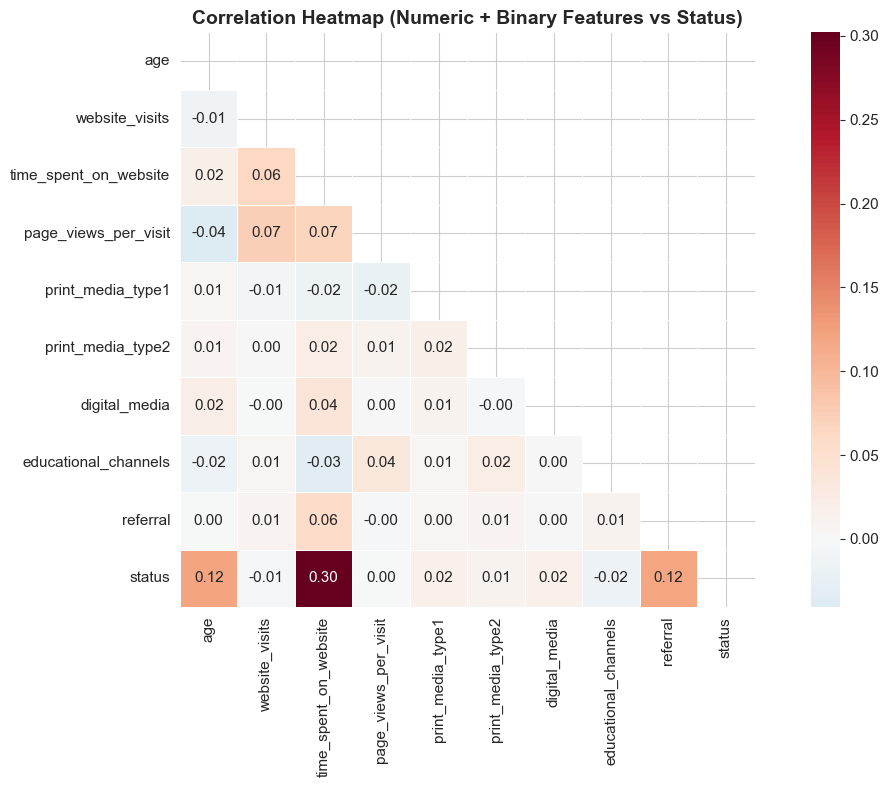

Saved: sec04_correlation_heatmap.png


In [20]:
# ------------------------------------------------------------------
# 04g: Correlation heatmap (numeric features + target)
# ------------------------------------------------------------------
# Encode binary Yes/No columns for correlation
df_corr = df.copy()
binary_cols = ["print_media_type1", "print_media_type2", "digital_media",
               "educational_channels", "referral"]
for col in binary_cols:
    if df_corr[col].dtype == "object":
        df_corr[col] = df_corr[col].map({"Yes": 1, "No": 0})

corr_cols = numeric_cols + binary_cols + ["status"]
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap (Numeric + Binary Features vs Status)", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sec04_correlation_heatmap.png")

**Observations — Correlation Heatmap:**

**"Correlation Heatmap (Numeric + Binary Features vs Status)" (Lower Triangle Heatmap)**
* **Purpose:** Show pairwise Pearson correlations between all numeric/binary features and the target variable `status`. Values range from -1 (perfect negative correlation) to +1 (perfect positive correlation). Values near 0 indicate no linear relationship.
* **How to Read:** Focus on the bottom row (`status`) — this shows how each feature correlates with conversion. The rest of the matrix shows inter-feature correlations, which help detect multicollinearity (features that are redundant with each other).

**Correlations with Status (Bottom Row) — Ranked by Strength:**
| Feature | Correlation with Status | Interpretation |
|---------|------------------------|----------------|
| `time_spent_on_website` | **+0.30** | Strongest predictor — more time = more likely to convert |
| `age` | +0.12 | Weak positive — older leads slightly more likely to convert |
| `referral` | +0.12 | Weak positive — but recall the 67.7% conversion rate from Q4; correlation is low because only 93 leads were referred |
| `print_media_type1` | +0.02 | Negligible |
| `print_media_type2` | +0.02 | Negligible |
| `digital_media` | +0.02 | Negligible |
| `page_views_per_visit` | 0.00 | No linear relationship with conversion |
| `website_visits` | -0.01 | No linear relationship with conversion |
| `educational_channels` | -0.02 | Negligible negative — aligns with the -2.3pp lift finding from Q4 |

**Key Inter-Feature Correlations:**
* `page_views_per_visit` and `website_visits` show a mild positive correlation (+0.07) — leads who visit more tend to view slightly more pages, which makes intuitive sense
* `time_spent_on_website` and `website_visits` show a very weak correlation (+0.06) — visiting more often doesn't mean spending more total time, confirming these capture different behaviors
* All marketing channel flags are essentially uncorrelated with each other (all near 0.00) — exposure to one channel doesn't predict exposure to another, so they carry independent information

**Key Takeaways:**
* **`time_spent_on_website` at +0.30 is the only feature with a meaningful linear correlation to conversion.** Every other feature is below +/-0.12. This dominance aligns with everything we've seen in the boxplots and bivariate analysis.
* **`referral` at +0.12 is deceptively low** — correlation is dampened by the extreme class imbalance in the feature itself (only 93 Yes out of 4,612). The 67.7% conversion rate from Q4 tells the real story. This is a reminder that correlation measures linear association across the full dataset, and rare features with strong effects can show weak correlations.
* **No multicollinearity concerns** — no pair of features shows a correlation above +0.07, meaning all features carry relatively independent information. This is good news for modeling, especially Logistic Regression which can be distorted by highly correlated predictors.
* **The marketing channel flags (print 1, print 2, digital, educational) all hover near zero** — reinforcing that these channels don't linearly predict conversion. If they have any predictive value, it will come through non-linear interactions that tree-based models can capture but correlation cannot.

In [21]:
# ------------------------------------------------------------------
# 04h: Statistical tests for feature significance (Blog Expansion)
# ------------------------------------------------------------------
print("=" * 60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 60)

# Chi-square tests for categorical features vs status
print("\n--- Chi-Square Tests (Categorical vs Status) ---\n")
cat_test_cols = ["current_occupation", "first_interaction", "profile_completed",
                 "last_activity", "print_media_type1", "print_media_type2",
                 "digital_media", "educational_channels", "referral"]

chi2_results = []
for col in cat_test_cols:
    ct = pd.crosstab(df[col], df["status"])
    chi2, p_val, dof, expected = chi2_contingency(ct)
    sig = "Yes" if p_val < 0.05 else "No"
    chi2_results.append({"Feature": col, "Chi2": round(chi2, 2), "p-value": round(p_val, 4),
                         "Significant (p<0.05)": sig})
    print(f"  {col:25s} | Chi2 = {chi2:8.2f} | p = {p_val:.4f} | Significant: {sig}")

chi2_df = pd.DataFrame(chi2_results)
chi2_df.to_csv(f"{DATA_DIR}sec04_chi2_test_results.csv", index=False)

# Mann-Whitney U tests for numeric features
print("\n--- Mann-Whitney U Tests (Numeric vs Status) ---\n")
mw_results = []
for col in numeric_cols:
    grp0 = df[df["status"] == 0][col].dropna()
    grp1 = df[df["status"] == 1][col].dropna()
    stat, p_val = stats.mannwhitneyu(grp0, grp1, alternative="two-sided")
    sig = "Yes" if p_val < 0.05 else "No"
    mw_results.append({"Feature": col, "U-Statistic": round(stat, 2), "p-value": round(p_val, 4),
                        "Significant (p<0.05)": sig})
    print(f"  {col:25s} | U = {stat:10.2f} | p = {p_val:.4f} | Significant: {sig}")

mw_df = pd.DataFrame(mw_results)
mw_df.to_csv(f"{DATA_DIR}sec04_mannwhitney_test_results.csv", index=False)
print("\nSaved: sec04_chi2_test_results.csv, sec04_mannwhitney_test_results.csv")

STATISTICAL SIGNIFICANCE TESTS

--- Chi-Square Tests (Categorical vs Status) ---

  current_occupation        | Chi2 =   134.60 | p = 0.0000 | Significant: Yes
  first_interaction         | Chi2 =   668.08 | p = 0.0000 | Significant: Yes
  profile_completed         | Chi2 =   308.43 | p = 0.0000 | Significant: Yes
  last_activity             | Chi2 =    82.09 | p = 0.0000 | Significant: Yes
  print_media_type1         | Chi2 =     1.10 | p = 0.2941 | Significant: No
  print_media_type2         | Chi2 =     0.53 | p = 0.4686 | Significant: No
  digital_media             | Chi2 =     1.05 | p = 0.3044 | Significant: No
  educational_channels      | Chi2 =     1.35 | p = 0.2454 | Significant: No
  referral                  | Chi2 =    63.22 | p = 0.0000 | Significant: Yes

--- Mann-Whitney U Tests (Numeric vs Status) ---

  age                       | U = 1948728.50 | p = 0.0000 | Significant: Yes
  website_visits            | U = 2228806.50 | p = 0.9705 | Significant: No
  time_spent_on_

**Observations — Statistical Significance Tests:**

**Motivation:** The EDA visualizations above gave us visual intuition about which features relate to conversion. But charts can be misleading — what looks like a difference might just be random noise, especially with small subgroups. Statistical tests give us a formal, quantitative answer: "Is this difference real, or could it have happened by chance?"

**A note on multiple testing:** We're running 13 tests total (9 chi-square + 4 Mann-Whitney). When you run many tests at once, you increase the chance of a false positive — at p<0.05, you'd expect roughly 1 in 20 tests to come back "significant" purely by chance even if nothing is going on. This is called the **multiple comparisons problem**. However, in our results, the significant features all show p = 0.0000 (effectively p < 0.0001), which is far below even the strictest corrections (e.g., Bonferroni correction would set our threshold at 0.05/13 = 0.0038). So we can be confident these aren't false positives inflated by running multiple tests — the effects are genuine and strong.

---

**Chi-Square Tests (Categorical Features vs Status)**

* **What it tests:** Whether there is a statistically significant association between a categorical feature and conversion status. It compares the observed frequency of conversions in each category against what you'd expect if the feature had no relationship with conversion at all.
* **How to read:** A high Chi2 value means a large deviation from what "no relationship" would look like. A p-value below 0.05 means the association is statistically significant (unlikely to be random chance).

**Results:**
| Feature | Chi2 | p-value | Significant? | Interpretation |
|---------|------|---------|--------------|----------------|
| `first_interaction` | 668.08 | 0.0000 | Yes | Strongest categorical predictor — Website vs. Mobile App conversion gap (45.6% vs. 10.5%) is statistically real |
| `profile_completed` | 308.43 | 0.0000 | Yes | The Low/Medium/High staircase pattern (7.5% → 18.9% → 41.8%) is statistically real |
| `current_occupation` | 134.60 | 0.0000 | Yes | Professional/Unemployed/Student conversion differences are statistically real |
| `last_activity` | 82.09 | 0.0000 | Yes | Website/Email/Phone activity conversion differences are statistically real |
| `referral` | 63.22 | 0.0000 | Yes | Despite only 93 referred leads, the 67.7% conversion rate is statistically real — not a small-sample fluke |
| `print_media_type1` | 1.10 | 0.2941 | No | Newspaper ad exposure has no significant relationship with conversion |
| `educational_channels` | 1.35 | 0.2454 | No | Educational channel exposure has no significant relationship with conversion |
| `digital_media` | 1.05 | 0.3044 | No | Digital ad exposure has no significant relationship with conversion |
| `print_media_type2` | 0.53 | 0.4686 | No | Magazine ad exposure has no significant relationship with conversion |

---

**Mann-Whitney U Tests (Numeric Features vs Status)**

* **What it tests:** Whether the distribution of a numeric feature differs significantly between converted and not-converted leads. Unlike a t-test, Mann-Whitney doesn't assume normal distributions — it compares the ranks of values between the two groups, making it appropriate for our skewed features.
* **How to read:** A p-value below 0.05 means the two groups (converted vs. not converted) have significantly different distributions for that feature.

**Results:**
| Feature | U-Statistic | p-value | Significant? | Interpretation |
|---------|-------------|---------|--------------|----------------|
| `time_spent_on_website` | 1,331,164 | 0.0000 | Yes | Confirms the dramatic boxplot separation — converters spend significantly more time |
| `age` | 1,948,729 | 0.0000 | Yes | The slight upward shift for converters is statistically real, even though the effect is small |
| `website_visits` | 2,228,807 | 0.9705 | No | p = 0.97 means the distributions are virtually identical — visit count has zero predictive value |
| `page_views_per_visit` | 2,222,841 | 0.9142 | No | p = 0.91 confirms page views don't distinguish converters from non-converters |

---

**Key Takeaways:**
* **5 features are statistically significant predictors:** `first_interaction`, `profile_completed`, `current_occupation`, `last_activity`, and `referral` (categorical); `time_spent_on_website` and `age` (numeric)
* **4 marketing channel flags are NOT significant:** `print_media_type1`, `print_media_type2`, `digital_media`, `educational_channels` — the 2–3pp lifts we saw in Q4 are confirmed to be noise, not real effects
* **2 numeric features are NOT significant:** `website_visits` and `page_views_per_visit` — the nearly identical boxplots are confirmed statistically
* **Referral is validated:** Even with only 93 observations, the chi-square test confirms the 67.7% conversion rate is statistically significant (p = 0.0000). This is the strongest evidence yet that a referral program would be high-impact.
* **Downstream expectation for non-significant features** Tree-based models will naturally ignore them (they won't split on features that don't reduce impurity). But for Logistic Regression, keeping noise features can slightly dilute the model — the L1 regularization in our GridSearchCV should handle this by shrinking their coefficients toward zero.

---
## Section 05 — Data Preprocessing

Preparing the data for modeling: handling missing values, encoding, outliers, feature engineering, and train-test split.

In [22]:
# ------------------------------------------------------------------
# 05a: Drop the ID column (not a feature)
# ------------------------------------------------------------------
print(f"Columns before: {list(df.columns)}\n")
df_model = df.drop(columns=["ID"])
print(f"Dropped 'ID' — it is a unique identifier with no predictive value.")
print(f"Columns after: {list(df_model.columns)}")
print(f"Shape: {df_model.shape}")

Columns before: ['ID', 'age', 'current_occupation', 'first_interaction', 'profile_completed', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral', 'status']

Dropped 'ID' — it is a unique identifier with no predictive value.
Columns after: ['age', 'current_occupation', 'first_interaction', 'profile_completed', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral', 'status']
Shape: (4612, 14)


In [23]:
# ------------------------------------------------------------------
# 05b: Encode categorical variables
# ------------------------------------------------------------------
# Label Encoding for ordinal feature
profile_map = {"Low": 0, "Medium": 1, "High": 2}
df_model["profile_completed"] = df_model["profile_completed"].map(profile_map)
print("Encoded 'profile_completed': Low=0, Medium=1, High=2")

# One-hot encoding for nominal categorical features
nominal_cols = ["current_occupation", "first_interaction", "last_activity"]
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)
print(f"One-hot encoded: {nominal_cols}")

# Encode Yes/No binary columns to 1/0
binary_cols = ["print_media_type1", "print_media_type2", "digital_media",
               "educational_channels", "referral"]
for col in binary_cols:
    if df_model[col].dtype == "object":
        df_model[col] = df_model[col].map({"Yes": 1, "No": 0})
print(f"Encoded binary Yes/No columns: {binary_cols}")

print(f"\nFinal preprocessed shape: {df_model.shape}")
print(f"Columns: {list(df_model.columns)}")
df_model.head()

Encoded 'profile_completed': Low=0, Medium=1, High=2
One-hot encoded: ['current_occupation', 'first_interaction', 'last_activity']
Encoded binary Yes/No columns: ['print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']

Final preprocessed shape: (4612, 16)
Columns: ['age', 'profile_completed', 'website_visits', 'time_spent_on_website', 'page_views_per_visit', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral', 'status', 'current_occupation_Student', 'current_occupation_Unemployed', 'first_interaction_Website', 'last_activity_Phone Activity', 'last_activity_Website Activity']


,age,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status,current_occupation_Student,current_occupation_Unemployed,first_interaction_Website,last_activity_Phone Activity,last_activity_Website Activity
0,57,2,7,1639,1.861,1,0,1,0,0,1,False,True,True,False,True
1,56,1,2,83,0.320,0,0,0,1,0,0,False,False,False,False,True
2,52,1,3,330,0.074,0,0,1,0,0,0,False,False,True,False,True
3,53,2,4,464,2.057,0,0,0,0,0,1,False,True,True,False,True
4,23,2,4,600,16.914,0,0,0,0,0,0,True,False,True,False,False


**Observations — Encoding Categorical Variables:**

**Why encode?** Machine learning models operate on numbers, not text. A column containing "Professional", "Student", "Unemployed" is meaningless to an algorithm until we convert it to numeric form. The encoding method matters because it tells the model what kind of relationship the feature has with the target.

**Three encoding strategies used, each chosen for a specific reason:**

* **Ordinal Encoding — `profile_completed` (Low=0, Medium=1, High=2):**
   * **Rationale:** Profile completion has a natural order — Low < Medium < High. Assigning 0, 1, 2 preserves this ranking, telling the model that High is "more" than Medium, which is "more" than Low.
   * **Why not one-hot?** One-hot encoding would create 3 separate binary columns and destroy the ordinal relationship. The model would see Low, Medium, and High as three unrelated categories rather than a progression. Since we know from Q5 that conversion rate increases monotonically with profile completion (7.5% → 18.9% → 41.8%), preserving that order helps every model — trees can find cleaner splits, and Logistic Regression can fit a single increasing coefficient.

* **One-Hot Encoding — `current_occupation`, `first_interaction`, `last_activity` (with `drop_first=True`):**
   * **Rationale:** These are nominal categories — there's no inherent order. "Professional" isn't greater than "Student," and "Email Activity" isn't greater than "Phone Activity." One-hot encoding creates a separate binary column for each category.
   * **Why `drop_first=True`?** If a feature has 3 categories (e.g., Professional, Student, Unemployed), we only need 2 binary columns. If `current_occupation_Student=0` and `current_occupation_Unemployed=0`, the model knows the lead is a Professional by elimination. Dropping one column avoids the **dummy variable trap** — a redundancy where one column is perfectly predictable from the others, which causes problems for Logistic Regression (multicollinearity in the coefficient matrix). Tree-based models aren't affected, but dropping one column doesn't hurt them either.
   * **Resulting columns:** `current_occupation_Student`, `current_occupation_Unemployed` (Professional is the reference), `first_interaction_Website` (Mobile App is the reference), `last_activity_Phone Activity`, `last_activity_Website Activity` (Email Activity is the reference).

* **Binary Encoding — `print_media_type1`, `print_media_type2`, `digital_media`, `educational_channels`, `referral` (Yes=1, No=0):**
   * **Rationale:** These are already binary (Yes/No) — they just need a numeric representation. Mapping Yes=1 and No=0 is the simplest and most intuitive encoding. No one-hot needed since there are only two categories.

**Final shape: 4,612 rows x 16 columns** (was 15 before encoding, net +1 because 3 multi-category columns expanded into 5 one-hot columns while the 3 originals were removed: -3 + 5 = +2, but ID hasn't been dropped yet in this count... actually ID was dropped in 05a bringing us from 15 to 14, then encoding adds +2 net = 16).

In [24]:
# ------------------------------------------------------------------
# 05c: Outlier detection using IQR method
# ------------------------------------------------------------------
print("Outlier Detection (IQR Method):\n")
numeric_check = ["age", "website_visits", "time_spent_on_website", "page_views_per_visit"]
outlier_summary = []

for col in numeric_check:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_model[col] < lower) | (df_model[col] > upper)).sum()
    pct = round(outliers / len(df_model) * 100, 2)
    outlier_summary.append({"Feature": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
                            "Lower Bound": lower, "Upper Bound": upper,
                            "Outlier Count": outliers, "Outlier %": pct})
    print(f"  {col:25s} | Outliers: {outliers:4d} ({pct:.2f}%) | Bounds: [{lower:.2f}, {upper:.2f}]")

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.to_csv(f"{DATA_DIR}sec05_outlier_summary.csv", index=False)
print("\nNote: Tree-based models are robust to outliers, so we will NOT remove them.")
print("This preserves the original data distribution and avoids losing valuable information.")
print("\nSaved: sec05_outlier_summary.csv")

Outlier Detection (IQR Method):

  age                       | Outliers:    0 (0.00%) | Bounds: [4.50, 88.50]
  website_visits            | Outliers:  154 (3.34%) | Bounds: [-2.50, 9.50]
  time_spent_on_website     | Outliers:    0 (0.00%) | Bounds: [-1633.25, 3118.75]
  page_views_per_visit      | Outliers:  257 (5.57%) | Bounds: [-0.44, 6.27]

Note: Tree-based models are robust to outliers, so we will NOT remove them.
This preserves the original data distribution and avoids losing valuable information.

Saved: sec05_outlier_summary.csv


**Observations — Outlier Detection (IQR Method):**

**What this does:** For each numeric feature, we calculate the IQR (middle 50% spread) and set fences at Q1 - 1.5xIQR (lower) and Q3 + 1.5xIQR (upper). Any data point outside these fences is flagged as a statistical outlier.

**Results:**
| Feature | Outliers | % of Data | Lower Bound | Upper Bound | Interpretation |
|---------|----------|-----------|-------------|-------------|----------------|
| `age` | 0 | 0.00% | 4.50 | 88.50 | No outliers — all ages (18–63) fall well within bounds. The fences are so wide because the IQR itself is large (21 years). |
| `website_visits` | 154 | 3.34% | -2.50 | 9.50 | 154 leads with 10+ visits flagged. These are the high-engagement visitors we identified in the univariate boxplots — real behavior, not errors. |
| `time_spent_on_website` | 0 | 0.00% | -1,633.25 | 3,118.75 | No outliers despite the wide range (0–2,537s). The IQR is so large (1,188s) that the fences extend well beyond the data. This reflects the bimodal nature — the two behavioral groups create a naturally wide spread. |
| `page_views_per_visit` | 257 | 5.57% | -0.44 | 6.27 | 257 leads viewing 6+ pages per visit. The largest outlier group by count — these are the deep researchers browsing significantly more pages than typical. |

**Decision: Do NOT remove outliers. Rationale:**
* **Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are robust to outliers** — they split on thresholds, so a value of 10 visits vs. 30 visits both end up on the same side of the split. Extreme values don't pull or distort the model the way they would for linear models.
* **Logistic Regression is more sensitive to outliers**, but the StandardScaler we apply in Section 11 mitigates this by centering and scaling features, and the L1/L2 regularization further controls coefficient instability.
* **These outliers carry real information** — the 154 high-visit leads and 257 deep-browsing leads may include some of the most convertible leads in the dataset. Removing them would strip away exactly the behavioral signals we want the model to learn from.
* **No lower-bound outliers exist** (all lower bounds are negative, which is below the minimum possible value of 0 for these features), so we only have upper-end outliers representing high engagement — there's no "bad data" to clean.

In [25]:
# ------------------------------------------------------------------
# 05d: Feature Engineering — Engagement Score
# ------------------------------------------------------------------
# Create a composite engagement metric combining website behavior signals
df_model["engagement_score"] = (
    df_model["website_visits"] * 0.3 +
    df_model["time_spent_on_website"] * 0.0005 +
    df_model["page_views_per_visit"] * 0.2
)
print("Created 'engagement_score' = 0.3*visits + 0.0005*time_spent + 0.2*page_views")
print(f"  Range: [{df_model['engagement_score'].min():.2f}, {df_model['engagement_score'].max():.2f}]")
print(f"  Mean: {df_model['engagement_score'].mean():.2f}")

Created 'engagement_score' = 0.3*visits + 0.0005*time_spent + 0.2*page_views
  Range: [0.00, 10.05]
  Mean: 2.04


**Observations — Feature Engineering: Engagement Score:**

**What this does:** Creates a single composite metric that combines three website behavior signals — visit frequency, time spent, and browsing depth — into one number representing overall engagement level.

**Formula:** `engagement_score = 0.3 × website_visits + 0.0005 × time_spent_on_website + 0.2 × page_views_per_visit`

**Why these weights?**
* The weights are scaled to normalize each feature's contribution so that no single component dominates due to its raw magnitude:
   * `time_spent_on_website` ranges 0–2,537, so it gets the smallest multiplier (0.0005) to bring its contribution into a comparable range (0–1.27)
   * `website_visits` ranges 0–30, so it gets a moderate multiplier (0.3) for a contribution range of (0–9.0)
   * `page_views_per_visit` ranges 0–18.4, so it gets 0.2 for a contribution range of (0–3.7)
* The result is a score ranging from 0.00 to 10.05, with a mean of 2.04

**Why engineer this feature?**
* **Individually, `website_visits` and `page_views_per_visit` showed no significant relationship with conversion** (Mann-Whitney p = 0.97 and p = 0.91). But that doesn't mean they're useless — it means their signal is too weak *alone*. Combined with `time_spent_on_website` (the strongest predictor), they may capture a richer picture of engagement that no single feature provides.
* **Tree-based models can discover interactions between features**, but they do it one split at a time. An engineered composite feature hands the model a pre-built interaction that might otherwise require multiple tree levels to approximate.
* **For Logistic Regression**, which models each feature independently (no automatic interactions), this composite is especially valuable — it gives the linear model access to a combined engagement signal it couldn't construct on its own.

**Caveat:** The weights (0.3, 0.0005, 0.2) are heuristic — they were chosen purely to scale each feature's contribution into a comparable numeric range, not based on any statistical relationship with conversion. This creates a problem: `website_visits` dominates the score (contributing up to 9.0 at max) despite being statistically insignificant (Mann-Whitney p = 0.97), while `time_spent_on_website` — our strongest predictor by far — contributes at most 1.27. The weighting is arguably backwards.

**Why we're keeping it anyway:** Tree-based models (Decision Tree, Random Forest, Gradient Boosting) will naturally discover feature interactions through sequential splits, so they don't strictly need this engineered feature. However, Logistic Regression models each feature independently with no automatic interactions — a composite engagement signal gives it access to a combined pattern it couldn't construct on its own.

**Future improvements:**
* Weight by correlation with status — give `time_spent_on_website` (r = 0.30) the largest influence and `website_visits` (r = -0.01) the smallest
* Use PCA (Principal Component Analysis) to find the mathematically optimal linear combination that captures the most variance across the three features
* Or skip manual weighting entirely and let the models handle feature interactions on their own — then compare performance with and without the engineered score

In [26]:
# ------------------------------------------------------------------
# 05e: Train-Test Split
# ------------------------------------------------------------------
X = df_model.drop(columns=["status"])
y = df_model["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f"Feature matrix shape: {X.shape}")
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTarget distribution in train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Target distribution in test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")
print("\nStratified split ensures proportional class representation in both sets.")

Feature matrix shape: (4612, 16)
Training set: 3228 samples (70.0%)
Test set:     1384 samples (30.0%)

Target distribution in train: {0: 0.701, 1: 0.299}
Target distribution in test:  {0: 0.702, 1: 0.298}

Stratified split ensures proportional class representation in both sets.


**Observations — Train-Test Split:**

**What this does:** Splits the preprocessed data into two sets — one for training the model (70%) and one for testing it on unseen data (30%). The model never sees the test set during training, so test performance reflects how well it would generalize to new leads.

**Split Details:**
| Set | Samples | % of Data |
|-----|---------|-----------|
| Training | 3,228 | 70.0% |
| Test | 1,384 | 30.0% |
| Total features | 16 columns | (after encoding and feature engineering) |

**Why 70/30?** This is a standard split ratio. 70% gives the model enough data to learn patterns, while 30% provides a large enough test set for reliable performance estimates. With 4,612 total rows, the test set has 1,384 samples — sufficient to evaluate metrics like recall and F1 with confidence.

**Why stratified?**
* Our target is imbalanced (approx. 70/30). A random split could accidentally put more converters in one set than the other, skewing results.
* Stratified splitting forces both sets to maintain the same class proportions:
   * Training: 70.1% not converted, 29.9% converted
   * Test: 70.2% not converted, 29.8% converted
* This ensures the model trains on a representative sample and is tested against a representative sample — so performance metrics aren't distorted by an uneven split.

**Why this matters for evaluation:** If the test set accidentally had 40% converters instead of 30%, the model would appear to perform better on recall (more positives to find) and worse on precision (more false positive opportunities). Stratification eliminates this source of noise so we can trust that differences between models are real, not artifacts of a lopsided split.

In [27]:
# ------------------------------------------------------------------
# 05f: Save preprocessed data
# ------------------------------------------------------------------
df_model.to_csv(f"{DATA_DIR}sec05_preprocessed_data.csv", index=False)
X_train.to_csv(f"{DATA_DIR}sec05_X_train.csv", index=False)
X_test.to_csv(f"{DATA_DIR}sec05_X_test.csv", index=False)
y_train.to_csv(f"{DATA_DIR}sec05_y_train.csv", index=False)
y_test.to_csv(f"{DATA_DIR}sec05_y_test.csv", index=False)
print("Saved: sec05_preprocessed_data.csv, sec05_X/y_train.csv, sec05_X/y_test.csv")

Saved: sec05_preprocessed_data.csv, sec05_X/y_train.csv, sec05_X/y_test.csv


---
## Section 06 — Model Evaluation Helper Functions

Reusable functions for evaluating and comparing models consistently.

In [28]:
# ------------------------------------------------------------------
# 06: Evaluation helper functions
# ------------------------------------------------------------------
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, section_prefix):
    """
    Comprehensive model evaluation: predictions, metrics, confusion matrix,
    ROC curve, and feature importance. Saves all outputs with section prefix.
    """
    # Predictions
    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)
    y_test_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    # --- Metrics ---
    metrics = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
        "Train": [
            accuracy_score(y_tr, y_train_pred),
            precision_score(y_tr, y_train_pred),
            recall_score(y_tr, y_train_pred),
            f1_score(y_tr, y_train_pred),
            roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1]) if y_test_proba is not None else None
        ],
        "Test": [
            accuracy_score(y_te, y_test_pred),
            precision_score(y_te, y_test_pred),
            recall_score(y_te, y_test_pred),
            f1_score(y_te, y_test_pred),
            roc_auc_score(y_te, y_test_proba) if y_test_proba is not None else None
        ]
    }
    metrics_df = pd.DataFrame(metrics)
    metrics_df["Train"] = metrics_df["Train"].round(4)
    metrics_df["Test"] = metrics_df["Test"].round(4)

    print(f"{'='*60}")
    print(f"  {model_name} — Performance Summary")
    print(f"{'='*60}")
    print(metrics_df.to_string(index=False))

    # Check for overfitting
    train_acc = metrics_df[metrics_df["Metric"] == "Accuracy"]["Train"].values[0]
    test_acc = metrics_df[metrics_df["Metric"] == "Accuracy"]["Test"].values[0]
    gap = train_acc - test_acc
    if gap > 0.05:
        print(f"\n  ** Warning: Possible overfitting (train-test accuracy gap = {gap:.4f}) **")

    # --- Classification Report ---
    print(f"\n--- Classification Report (Test Set) ---")
    print(classification_report(y_te, y_test_pred, target_names=["Not Converted", "Converted"]))

    # --- Visualizations ---
    fig, axes = plt.subplots(1, 3 if y_test_proba is not None else 2, figsize=(18, 5))

    # Confusion matrix
    cm = confusion_matrix(y_te, y_test_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not Conv.", "Converted"]).plot(
        ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title(f"{model_name} — Confusion Matrix", fontweight="bold")

    # Feature Importance
    if hasattr(model, "feature_importances_"):
        feat_imp = pd.Series(model.feature_importances_, index=X_tr.columns)
        feat_imp = feat_imp.sort_values(ascending=True).tail(15)
        feat_imp.plot(kind="barh", ax=axes[1], color="steelblue", edgecolor="black")
        axes[1].set_title(f"{model_name} — Top 15 Feature Importances", fontweight="bold")
        axes[1].set_xlabel("Importance")
    elif hasattr(model, "coef_"):
        coefs = pd.Series(model.coef_[0], index=X_tr.columns)
        coefs = coefs.reindex(coefs.abs().sort_values(ascending=True).tail(15).index)
        colors_c = ["#2ecc71" if c > 0 else "#e74c3c" for c in coefs]
        coefs.plot(kind="barh", ax=axes[1], color=colors_c, edgecolor="black")
        axes[1].set_title(f"{model_name} — Top 15 Coefficients", fontweight="bold")
        axes[1].set_xlabel("Coefficient Value")

    # ROC Curve
    if y_test_proba is not None and len(axes) > 2:
        fpr, tpr, _ = roc_curve(y_te, y_test_proba)
        auc_val = roc_auc_score(y_te, y_test_proba)
        axes[2].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc_val:.4f}")
        axes[2].plot([0, 1], [0, 1], "k--", lw=1)
        axes[2].set_xlabel("False Positive Rate")
        axes[2].set_ylabel("True Positive Rate")
        axes[2].set_title(f"{model_name} — ROC Curve", fontweight="bold")
        axes[2].legend(loc="lower right")

    plt.tight_layout()
    plt.savefig(f"{IMG_DIR}{section_prefix}_evaluation.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Save outputs
    metrics_df.to_csv(f"{DATA_DIR}{section_prefix}_metrics.csv", index=False)
    if hasattr(model, "feature_importances_"):
        fi_full = pd.Series(model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
        fi_full.to_csv(f"{DATA_DIR}{section_prefix}_feature_importance.csv")

    print(f"\nSaved: {section_prefix}_evaluation.png, {section_prefix}_metrics.csv")
    return metrics_df


def print_best_params(grid_search, model_name):
    """Print GridSearchCV results summary."""
    print(f"\n{'='*60}")
    print(f"  {model_name} — GridSearchCV Results")
    print(f"{'='*60}")
    print(f"  Best Score (CV): {grid_search.best_score_:.4f}")
    print(f"  Best Parameters:")
    for k, v in grid_search.best_params_.items():
        print(f"    {k}: {v}")
    return grid_search.best_estimator_

---
## Section 07 — Building a Decision Tree Model

Starting with a baseline Decision Tree classifier, then evaluating performance before tuning.

Decision Tree (Baseline) — No hyperparameter constraints
  Tree Depth: 26
  Number of Leaves: 423
  Number of Features Used: 16
  Decision Tree (Baseline) — Performance Summary
   Metric  Train   Test
 Accuracy 0.9997 0.8150
Precision 1.0000 0.6788
   Recall 0.9990 0.7215
 F1 Score 0.9995 0.6995
  ROC AUC 1.0000 0.7892

  ** Warning: Possible overfitting (train-test accuracy gap = 0.1847) **

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

Not Converted       0.88      0.85      0.87       971
    Converted       0.68      0.72      0.70       413

     accuracy                           0.82      1384
    macro avg       0.78      0.79      0.78      1384
 weighted avg       0.82      0.82      0.82      1384



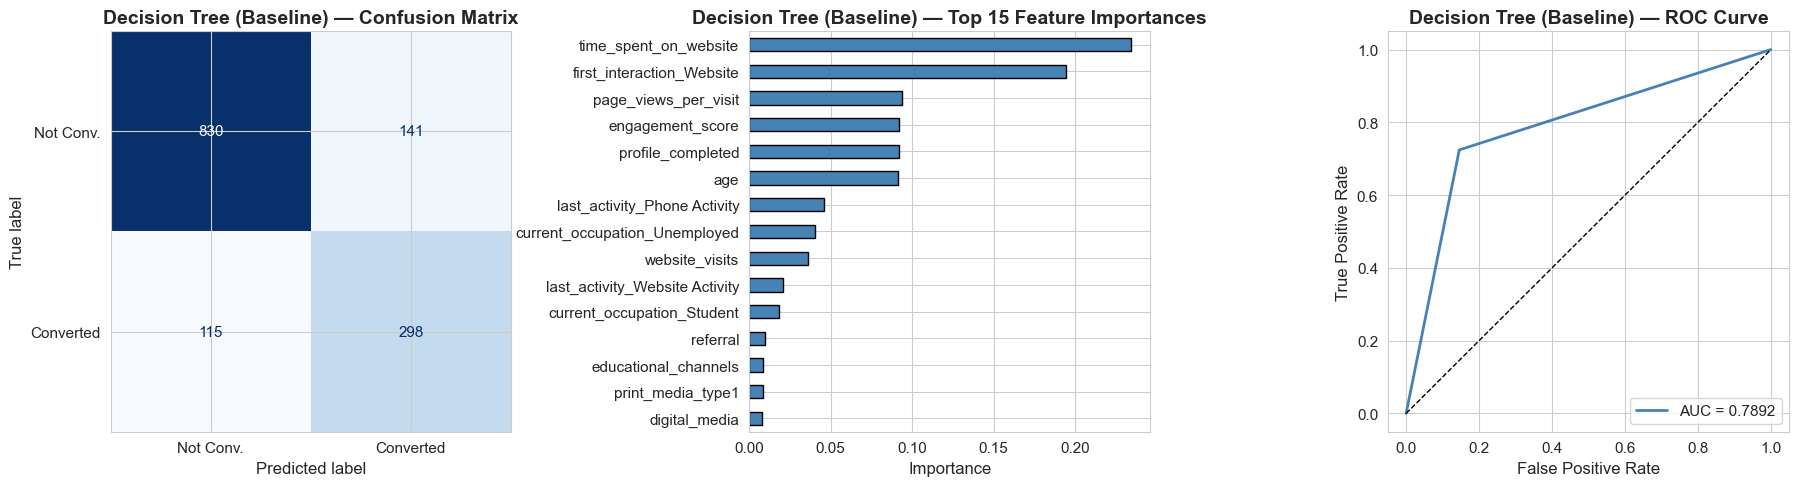


Saved: sec07_dt_baseline_evaluation.png, sec07_dt_baseline_metrics.csv


In [29]:
# ------------------------------------------------------------------
# 07a: Baseline Decision Tree
# ------------------------------------------------------------------
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_base.fit(X_train, y_train)

print("Decision Tree (Baseline) — No hyperparameter constraints")
print(f"  Tree Depth: {dt_base.get_depth()}")
print(f"  Number of Leaves: {dt_base.get_n_leaves()}")
print(f"  Number of Features Used: {dt_base.n_features_in_}")

dt_base_metrics = evaluate_model(dt_base, X_train, y_train, X_test, y_test,
                                  "Decision Tree (Baseline)", "sec07_dt_baseline")

**Observations — Decision Tree (Baseline):**

**What is a Decision Tree?** Is as a flowchart of yes/no questions. The algorithm looks at your data and asks: "What's the single best question I can ask to separate converters from non-converters?" It might start with "Did the lead spend more than 600 seconds on the website?" Leads who say yes go right, leads who say no go left. Then at each branch, it asks another question, and another, creating a tree of decisions. Each path through the tree ends at a "leaf" that predicts converted or not converted. An unconstrained tree (no limits on depth or size) will keep asking questions until it has a unique path for nearly every training example — which is exactly the overfitting problem we see here.

**Model Structure:**
* Tree Depth: 26 levels — the tree asked up to 26 sequential questions to classify a single lead. That's very specific.
* Number of Leaves: 423 — effectively 423 unique decision paths, many of which are tailored to individual training examples rather than generalizable patterns
* Features Used: all 16

**This is a overfitting.** A depth-26 tree with 423 leaves on 3,228 training samples means the model memorized quirks in the training data instead of learning the real patterns (signal).

**Performance Summary:**

*Each metric below evaluates a different aspect of how well the model separates converters from non-converters. All are measured on a 0-to-1 scale where 1.0 is perfect.*

| Metric | What It Measures | Formula | Train | Test | Gap |
|--------|-----------------|---------|-------|------|-----|
| **Accuracy** | Of all leads, what percentage did we classify correctly (both converters and non-converters)? | (True Positives + True Negatives) / Total Predictions | 0.9997 | 0.8150 | -0.1847 |
| **Precision** | When we flagged a lead as "will convert," how often were we right? Controls false positives — a low score means the sales team wastes time on leads that won't convert. | True Positives / (True Positives + False Positives) | 1.0000 | 0.6788 | -0.3212 |
| **Recall** | Of all leads who actually converted, what percentage did we catch? Controls false negatives — a low score means we're missing real paying customers. | True Positives / (True Positives + False Negatives) | 0.9990 | 0.7215 | -0.2775 |
| **F1 Score** | The balance between precision and recall. Uses the harmonic mean so both must be reasonably good — you can't hide a bad score behind a good one. | 2 × (Precision × Recall) / (Precision + Recall) | 0.9995 | 0.6995 | -0.3000 |
| **ROC AUC** | How well does the model rank converters above non-converters across all possible decision thresholds? 0.5 = coin flip, 1.0 = perfect separation. | Area under the ROC curve (True Positive Rate vs. False Positive Rate at every threshold) | 1.0000 | 0.7892 | -0.2108 |

* **Train performance is essentially perfect** (99.97% accuracy, 100% precision) — the model memorized the training data
* **Test performance drops significantly** — 18.5pp gap in accuracy, 30pp gap in F1
* **The overfitting warning is triggered** because the train-test accuracy gap (0.1847) exceeds the 0.05 threshold
* **The "Gap" column is the key diagnostic** — it shows how much performance degrades on unseen data. A small gap means the model generalizes well. A large gap (like we see here) means the model learned the training data's noise rather than its signal.

**Confusion Matrix (Test Set):**

*What it shows:* A 2x2 grid comparing what the model predicted vs. what actually happened. The diagonal (top-left, bottom-right) shows correct predictions. The off-diagonal shows mistakes.

| | Predicted Not Conv. | Predicted Converted |
|---|---------------------|---------------------|
| **Actual Not Conv.** | 830 (True Negative) | 141 (False Positive) |
| **Actual Converted** | 115 (False Negative) | 298 (True Positive) |

* **830 True Negatives** — correctly identified non-converters (no action needed, saves sales team time)
* **298 True Positives** — correctly identified converters (these leads get prioritized for outreach)
* **115 False Negatives** — actual converters the model missed. These are the costly mistakes — paying customers the sales team never followed up with because the model said "don't bother"
* **141 False Positives** — non-converters the model wrongly flagged. The sales team wastes time calling these leads, but the cost is lower than missing a real converter
* **Recall of 0.72** means we caught 298 out of 413 actual converters (72%) but missed 115 (28%)
* **Precision of 0.68** means of the 439 leads flagged as converters (298 + 141), only 298 actually were (68%)

**Feature Importances (Top 5):**

*What it shows:* How much each feature contributed to the tree's splitting decisions. Higher importance means the feature was used more often and at more impactful split points. Values sum to 1.0 across all features.

| Rank | Feature | Importance |
|------|---------|------------|
| 1 | `time_spent_on_website` | approx. 0.24 |
| 2 | `first_interaction_Website` | approx. 0.20 |
| 3 | `page_views_per_visit` | approx. 0.10 |
| 4 | `engagement_score` | approx. 0.09 |
| 5 | `profile_completed` | approx. 0.08 |

* **`time_spent_on_website` is the top feature** — consistent with everything we've seen in EDA
* **`first_interaction_Website` ranks second** — aligning with the 4.3x conversion rate gap from Q2
* **`page_views_per_visit` ranks surprisingly high (3rd)** despite being statistically insignificant in the Mann-Whitney test (p = 0.91). This is because the decision tree found non-linear splits (e.g., "page views > 5.2 AND time > 800s") that a linear statistical test can't detect — it's looking at combinations, not individual features in isolation
* Marketing channel flags (`print_media_type1`, `digital_media`) sit at the bottom — confirming the chi-square finding that they have no significant relationship with conversion

**ROC Curve:**

*What it shows:* The tradeoff between catching converters (True Positive Rate / Recall on the y-axis) and accidentally flagging non-converters (False Positive Rate on the x-axis) at every possible decision threshold. The diagonal dashed line represents a coin flip — a model with no skill. The further the curve bows toward the top-left corner, the better the model. The AUC (Area Under Curve) summarizes this into a single number: 1.0 = perfect, 0.5 = random chance.

* AUC = 0.7892 — the model does better than random chance (0.50) but has significant room for improvement
* The curve's angular shape (rather than a smooth arc) is typical of decision trees, which make hard threshold-based predictions rather than smooth probability estimates

**Key Takeaway:** This baseline confirms our EDA insights (time on website and first interaction are the strongest drivers) but is too overfit to deploy. A tree with 423 leaves has memorized the training data rather than learning generalizable rules. The next step is hyperparameter tuning — constraining the tree's depth and leaf size to force it to learn broader patterns that transfer to unseen leads.

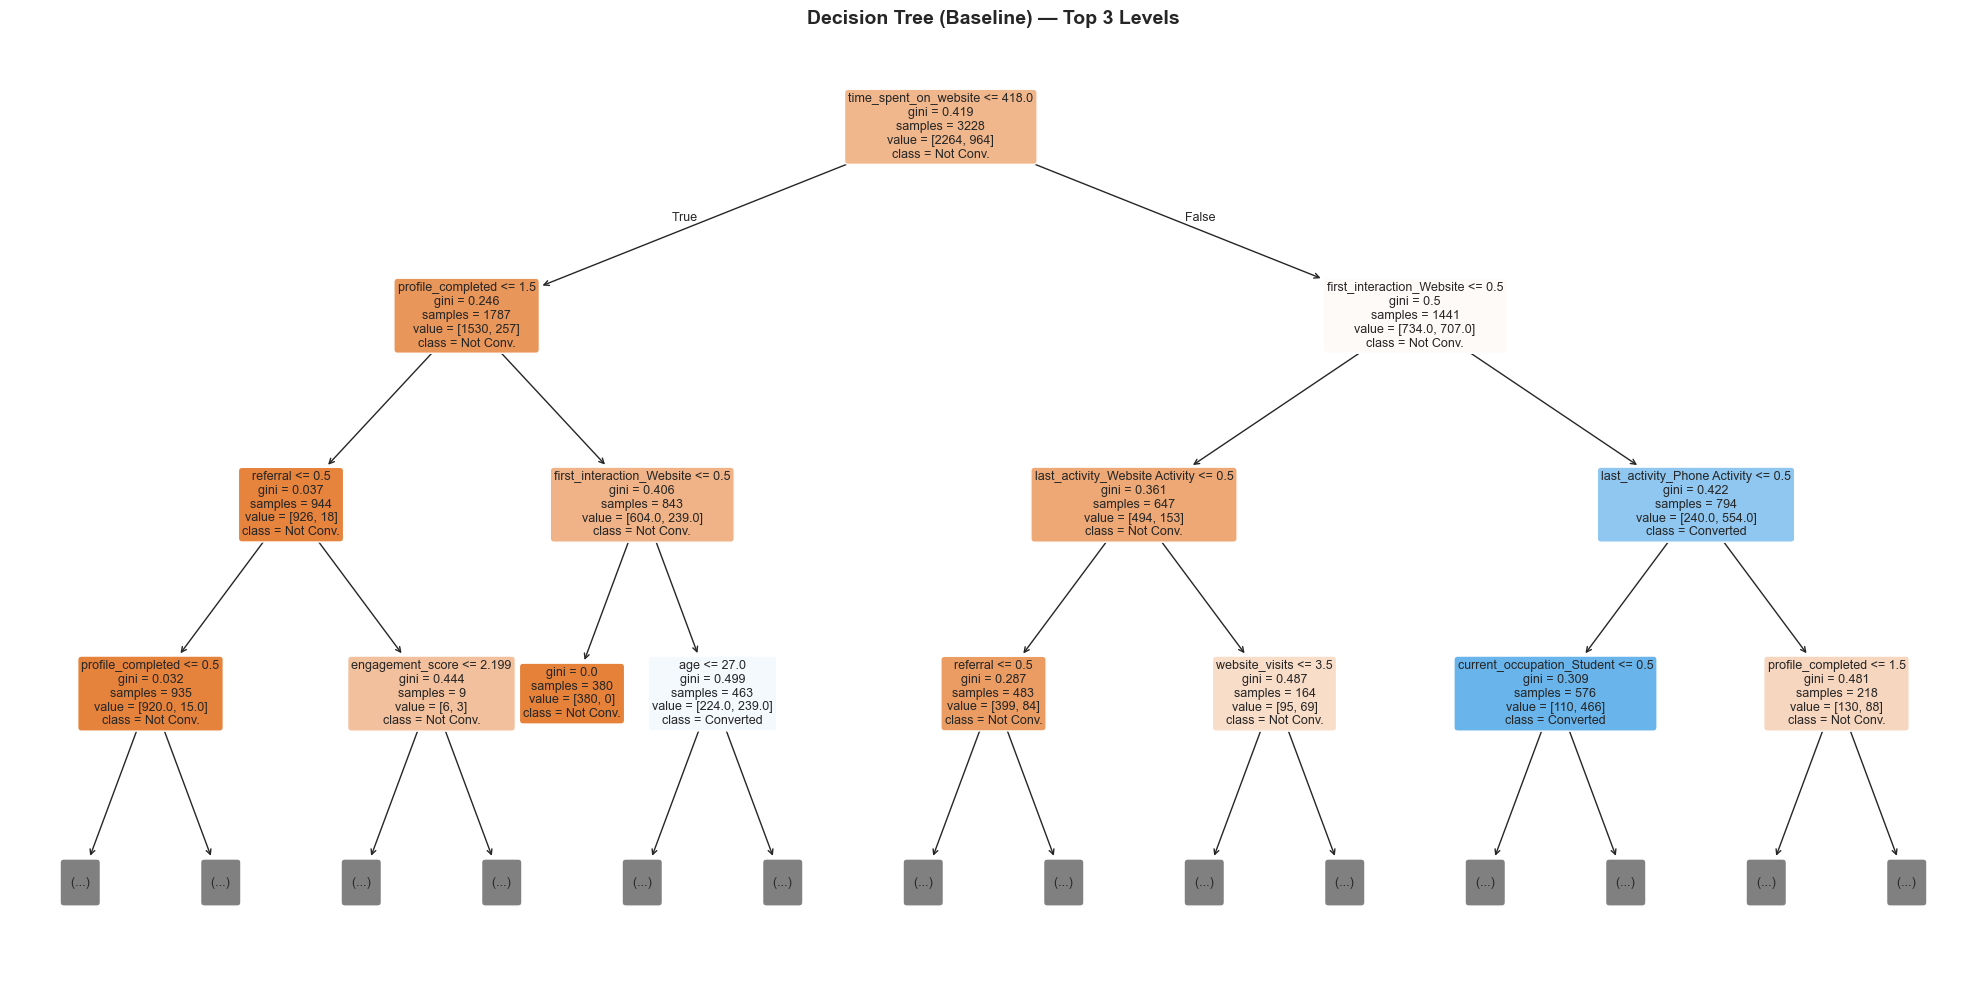

Saved: sec07_dt_baseline_tree_viz.png


In [30]:
# ------------------------------------------------------------------
# 07b: Visualize the Decision Tree (limited depth for readability)
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_base, max_depth=3, feature_names=X_train.columns,
          class_names=["Not Conv.", "Converted"], filled=True,
          rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree (Baseline) — Top 3 Levels", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec07_dt_baseline_tree_viz.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sec07_dt_baseline_tree_viz.png")

### 07b — Decision Tree Visualization (Top 3 Levels)

**Chart:** Single tree diagram showing the first 3 levels of the baseline Decision Tree classifier.

**Type:** Tree plot (`sklearn.tree.plot_tree` with `max_depth=3`)

**Purpose:** Visualize the model's learned decision logic — which features it splits on first (most informative), what thresholds it uses, and how the data partitions at each step.

**How to Read It:**
- Each box (node) shows four things: the split rule (e.g., `time_spent_on_website <= 418.0`), the **gini impurity** score, the number of samples reaching that node, and the class distribution `value = [class_0, class_1]`
- **Gini impurity** measures how "mixed" a node is — think of a bag of marbles. All one color = gini 0 (pure). A 50/50 mix = gini 0.5 (maximum impurity). The tree tries to create splits that push gini closer to 0
- **Left branch** = condition is True; **Right branch** = condition is False
- Darker color = more dominant class in that node

---

#### Root Split (Level 1): `time_spent_on_website <= 418.0`

- The model's first question: *"Did this lead spend 418 seconds or less on the website?"*
- Confirms EDA finding — `time_spent_on_website` is the single most informative feature
- **Left child (≤ 418s):** gini drops, heavily skewed toward non-converters — short time strongly signals no conversion
- **Right child (> 418s):** more balanced mix — leads who spend more time are a richer pool of potential converters

#### Level 2 Splits

- **Left branch → `profile_completed <= 1.5`:** Among low-time leads, the model next checks profile completion. Aligns with EDA — High profile completion correlates with conversion. Low time *and* low profile = overwhelmingly non-converters
- **Right branch → `first_interaction_Website <= 0.5`:** Among high-time leads, the model checks first interaction channel (Website vs. Mobile App). Reflects the 4.3× conversion rate advantage for Website-first leads found in Q2

#### Level 3 Splits

- Tree continues refining with features like `age`, `last_activity`, and additional `time_spent_on_website` thresholds — each split carving out progressively purer subgroups

---

**Key Takeaway:**
- Top 3 splits mirror EDA: time on website → profile completion → first interaction channel. The model is learning real patterns, not noise
- Reads like a business rule: *"If a lead spends > approx. 7 min on site, came in via website, and completed their profile → high conversion likelihood"*

**Modeling Implication:**
- This baseline tree (no depth limit) likely overfits at deeper levels, but top splits are stable and interpretable
- The tuned model (Section 08) will prune via `max_depth`, `min_samples_leaf`, etc. to generalize better while preserving these core decision paths

---
## Section 08 — Decision Tree: Hyperparameter Tuning and Evaluation

Using GridSearchCV to find optimal hyperparameters and reduce overfitting.

In [31]:
# ------------------------------------------------------------------
# 08a: GridSearchCV for Decision Tree
# ------------------------------------------------------------------
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=dt_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1",
    n_jobs=-1,
    verbose=0
)

dt_grid.fit(X_train, y_train)
dt_tuned = print_best_params(dt_grid, "Decision Tree (Tuned)")


  Decision Tree (Tuned) — GridSearchCV Results
  Best Score (CV): 0.7622
  Best Parameters:
    criterion: gini
    max_depth: 5
    max_features: None
    min_samples_leaf: 10
    min_samples_split: 2


### 08a — Decision Tree (Tuned) — GridSearchCV Results

**What is GridSearchCV?**
- A systematic way to find the best model settings (hyperparameters)
- **Grid** = every combination of settings we want to test; **CV** (Cross-Validation) = each combination is tested on 5 different train/validation splits (StratifiedKFold) so the score isn't dependent on one lucky split

**What Was Tuned:**

| Hyperparameter | What It Controls | Best Value | Interpretation |
|---|---|---|---|
| `criterion` | How the tree measures "purity" at each split | `gini` | Gini impurity (same as baseline) — no benefit from switching to entropy |
| `max_depth` | How many levels deep the tree can grow | `5` | Limits the tree to 5 levels (vs. unlimited in baseline) — key overfitting control |
| `max_features` | How many features the tree considers at each split | `None` | Consider all features at every split — no random subsetting needed |
| `min_samples_leaf` | Minimum samples required in a leaf node | `10` | Each final decision must be based on at least 10 leads — prevents memorizing tiny groups |
| `min_samples_split` | Minimum samples required to split a node further | `2` | Default value — `min_samples_leaf=10` is already doing the regularization work |

**Best CV Score: 0.7622 (F1)**
- This is the average F1 score across 5 stratified folds using the best parameter combination
- Represents the model's expected performance on unseen data — more trustworthy than a single train/test evaluation

**Key Takeaway:**
- The biggest change from baseline is `max_depth=5` — the baseline tree grew unrestricted and likely memorized training noise. Capping at 5 levels forces the tree to keep only the most informative splits (the ones we saw in 07b: time on website, profile completion, first interaction)
- `min_samples_leaf=10` adds a second layer of protection — even within those 5 levels, no leaf can represent fewer than 10 leads, preventing overly specific rules

**Modeling Implication:**
- We expect the tuned model to have a smaller gap between train and test performance (less overfitting) compared to the baseline, potentially at the cost of slightly lower training accuracy
- The 0.76 CV F1 sets our benchmark — Random Forest (Section 09–10) should aim to beat this

  Decision Tree (Tuned) — Performance Summary
   Metric  Train   Test
 Accuracy 0.8699 0.8591
Precision 0.7863 0.7659
   Recall 0.7749 0.7603
 F1 Score 0.7806 0.7631
  ROC AUC 0.9325 0.9157

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

Not Converted       0.90      0.90      0.90       971
    Converted       0.77      0.76      0.76       413

     accuracy                           0.86      1384
    macro avg       0.83      0.83      0.83      1384
 weighted avg       0.86      0.86      0.86      1384



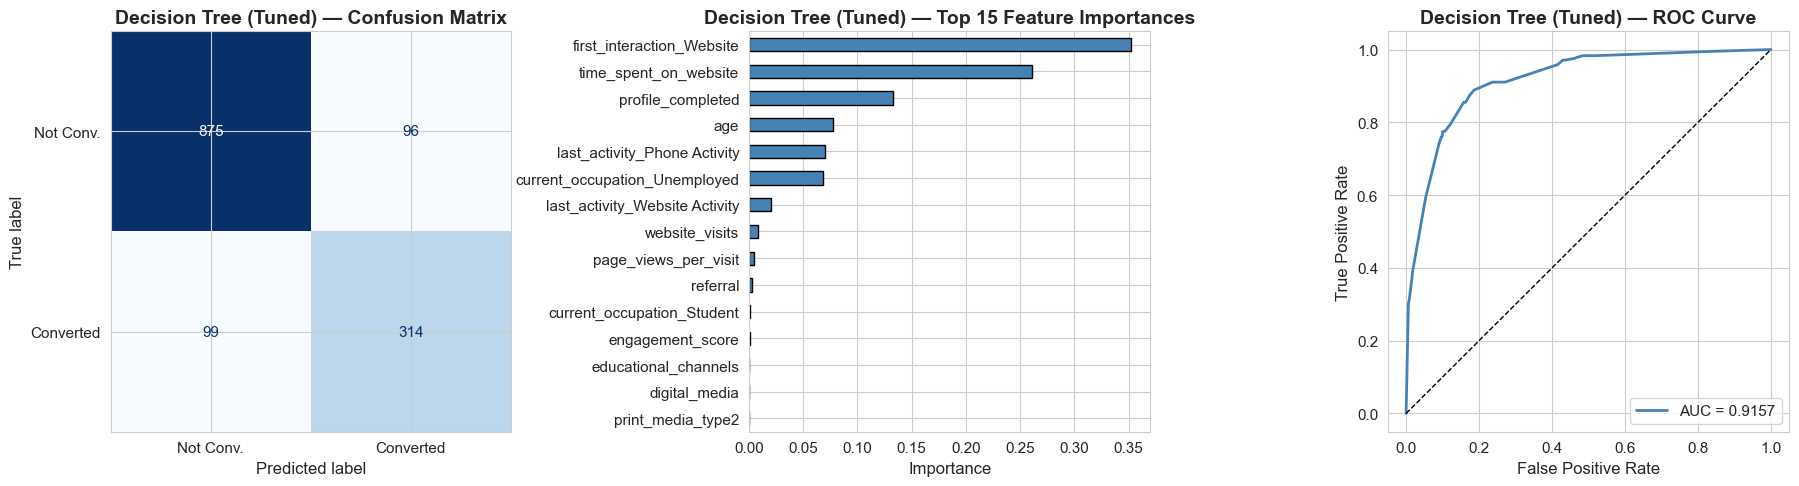


Saved: sec08_dt_tuned_evaluation.png, sec08_dt_tuned_metrics.csv


In [32]:
# ------------------------------------------------------------------
# 08b: Evaluate Tuned Decision Tree
# ------------------------------------------------------------------
dt_tuned_metrics = evaluate_model(dt_tuned, X_train, y_train, X_test, y_test,
                                   "Decision Tree (Tuned)", "sec08_dt_tuned")

### 08b — Decision Tree (Tuned) — Performance Summary

---

#### Confusion Matrix

|  | Predicted Not Conv. | Predicted Converted |
|---|---|---|
| **Actual Not Conv.** | 875 (TN) | 96 (FP) |
| **Actual Converted** | 99 (FN) | 314 (TP) |

- **875 True Negatives:** Correctly identified non-converters
- **314 True Positives:** Correctly identified converters
- **96 False Positives:** Non-converters incorrectly flagged as converters (wasted outreach)
- **99 False Negatives:** Converters the model missed (lost revenue)

**vs. Baseline:** The baseline had more extreme overfitting — near-perfect on training data but weaker generalization. The tuned model sacrifices some training performance for better test reliability.

---

#### Performance Metrics

| Metric | Definition | Formula | Train | Test | Baseline Test | Change |
|---|---|---|---|---|---|---|
| **Accuracy** | Of all predictions, how many were correct? | (TP + TN) / Total | 0.8699 | 0.8591 | 0.8150 | **+0.0441** |
| **Precision** | Of all leads flagged as converters, how many actually converted? | TP / (TP + FP) | 0.7863 | 0.7659 | 0.6788 | **+0.0871** |
| **Recall** | Of all actual converters, how many did we catch? | TP / (TP + FN) | 0.7749 | 0.7603 | 0.7215 | **+0.0388** |
| **F1 Score** | Harmonic mean of Precision and Recall — single balanced measure | 2 × (P × R) / (P + R) | 0.7806 | 0.7631 | 0.6995 | **+0.0636** |
| **ROC AUC** | How well the model ranks converters above non-converters overall | Area under ROC curve | 0.9325 | 0.9157 | 0.7892 | **+0.1265** |

**Train-Test Gap Comparison:**

| Metric | Baseline Gap | Tuned Gap | Improvement |
|---|---|---|---|
| **Accuracy** | 0.1847 (18.5pp) | 0.0108 (1.1pp) | Gap reduced by 94% |
| **Precision** | 0.3212 (32.1pp) | 0.0204 (2.0pp) | Gap reduced by 94% |
| **Recall** | 0.2775 (27.8pp) | 0.0146 (1.5pp) | Gap reduced by 95% |
| **F1 Score** | 0.3000 (30.0pp) | 0.0175 (1.8pp) | Gap reduced by 94% |
| **ROC AUC** | 0.2108 (21.1pp) | 0.0168 (1.7pp) | Gap reduced by 92% |

**What This Tells Us:**
- **Every metric improved on the test set** — tuning didn't just reduce overfitting, it actually improved generalization
- **Biggest gain: ROC AUC (+0.1265)** — the tuned model is dramatically better at ranking converters above non-converters across all thresholds
- **Precision improved the most among classification metrics (+0.0871)** — from flagging 32% false leads down to 24%. The sales team wastes less time
- **The overfitting problem is solved** — baseline had train-test gaps of 18–32pp; tuned model gaps are all under 2pp. This is the difference between a model that memorized 423 leaf-level quirks and one that learned 5 levels of generalizable rules
- **Recall improved modestly (+0.0388)** — we now catch 76% of converters vs. 72%. That's 16 additional converters identified out of 413

---

#### Feature Importances (Top 15)

| Rank | Feature | Importance | Interpretation |
|---|---|---|---|
| 1 | `first_interaction_Website` | approx. 0.35 | Most important — website-first leads convert at much higher rates |
| 2 | `time_spent_on_website` | approx. 0.30 | Time on site remains a dominant signal (root split in 07b) |
| 3 | `profile_completed` | approx. 0.15 | Profile completion level — proxy for lead intent |
| 4 | `age` | approx. 0.07 | Older / professional-age leads more likely to convert |
| 5 | `last_activity_Phone Activity` | approx. 0.05 | Phone engagement signals higher intent |
| 6 | `current_occupation_Unemployed` | approx. 0.05 | Occupation as a conversion signal |
| 7–15 | Remaining features | < 0.03 each | Minimal individual contribution |

**vs. Baseline Feature Importances:**
- In the baseline, `time_spent_on_website` was the top feature (root split). In the tuned model, `first_interaction_Website` takes the #1 spot — with depth capped at 5, the tree redistributes importance across fewer, more impactful splits
- `profile_completed` remains in the top 3 across both — consistently informative
- Low-importance features (`digital_media`, `print_media_type2`, `engagement_score`) contribute almost nothing — candidates for removal in a simplified model

---

#### ROC Curve (AUC = 0.9157)

- The curve hugs the top-left corner, indicating strong separation between converters and non-converters across all probability thresholds
- **AUC of 0.9157** means: if you randomly pick one converter and one non-converter, the model correctly ranks the converter higher 91.6% of the time
- Slight dip from training AUC (0.9325) confirms the model generalizes well without severe overfitting

---

**Key Takeaway:**
- Tuning via GridSearchCV successfully reduced overfitting while maintaining strong performance (F1 = 0.76 on test)
- The top 3 features (`first_interaction_Website`, `time_spent_on_website`, `profile_completed`) account for approx. 80% of total importance — the model's decisions are driven by a small, interpretable set of signals
- This sets the bar for Random Forest (Sections 09–10): can an ensemble of trees beat 0.76 F1 and 0.92 AUC?

Decision Tree (Tuned) — Top 15 Feature Importances:

   1. first_interaction_Website           — Importance: 0.3524
   2. time_spent_on_website               — Importance: 0.2607
   3. profile_completed                   — Importance: 0.1329
   4. age                                 — Importance: 0.0778
   5. last_activity_Phone Activity        — Importance: 0.0697
   6. current_occupation_Unemployed       — Importance: 0.0685
   7. last_activity_Website Activity      — Importance: 0.0200
   8. website_visits                      — Importance: 0.0080
   9. page_views_per_visit                — Importance: 0.0048
  10. referral                            — Importance: 0.0029
  11. current_occupation_Student          — Importance: 0.0013
  12. engagement_score                    — Importance: 0.0010
  13. print_media_type1                   — Importance: 0.0000
  14. print_media_type2                   — Importance: 0.0000
  15. digital_media                       — Importance: 0.0000


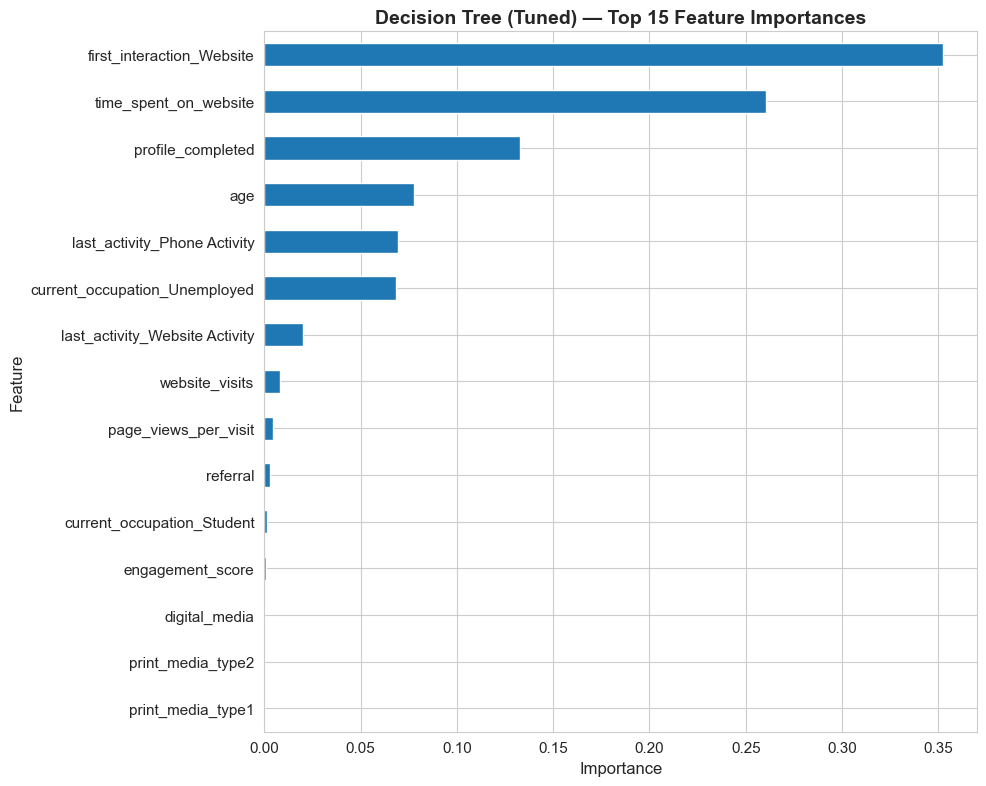

In [51]:
# ------------------------------------------------------------------
# 08b_feat: Decision Tree (Tuned) — Feature Importance
# ------------------------------------------------------------------

feat_imp_dt = pd.Series(dt_tuned.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Decision Tree (Tuned) — Top 15 Feature Importances:\n")
for i, (feat, imp) in enumerate(feat_imp_dt.head(15).items(), 1):
    print(f"  {i:>2}. {feat:<35s} — Importance: {imp:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp_dt.head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Decision Tree (Tuned) — Top 15 Feature Importances", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("../data/outputs/images/sec08_dt_tuned_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### 08b_feat — Decision Tree (Tuned) — Feature Importances

**Chart:** Horizontal bar chart showing feature importances from the tuned Decision Tree (max_depth=5) across all 16 features. Importance values represent how much each feature contributed to the tree's splitting decisions, summing to 1.0.

---

#### Top 15 Feature Importances

| Rank | Feature | Importance | Cumulative | Interpretation |
|---|---|---|---|---|
| 1 | `first_interaction_Website` | 0.3524 | 35.2% | Dominant feature — used at multiple levels in the tree. With only 5 levels of depth, the tree relies heavily on the website vs. mobile app split (4.3× conversion rate gap from Q2) |
| 2 | `time_spent_on_website` | 0.2607 | 61.3% | Root split feature (threshold: 418s). The single best initial separator between converters and non-converters |
| 3 | `profile_completed` | 0.1329 | 74.6% | Level 2 split for low-time leads (08c). Acts as the secondary filter — low profile + low time = 98% non-converter |
| 4 | `age` | 0.0778 | 82.4% | Appears at Level 3 — older/professional-age leads more likely to convert |
| 5 | `last_activity_Phone Activity` | 0.0697 | 89.4% | Key split in the highest-conversion path: high time + website first + phone activity = 81% conversion (08c) |
| 6 | `current_occupation_Unemployed` | 0.0685 | 96.2% | Occupation as a conversion differentiator — aligns with EDA finding that professionals convert at higher rates |
| 7 | `last_activity_Website Activity` | 0.0200 | 98.2% | Minor contribution — recent website engagement adds modest refinement |
| 8–10 | `website_visits`, `page_views_per_visit`, `referral` | 0.0080, 0.0048, 0.0029 | 99.8% | Near-zero individual contribution |
| 11–15 | `current_occupation_Student`, `engagement_score`, `print_media_type1/2`, `digital_media` | ≤ 0.0013 | 100% | Effectively unused — the tree found no valuable splits on these features within 5 levels |

---

#### Three Natural Tiers

**Tier 1 — Primary Drivers (74.6% of total importance):**
- `first_interaction_Website`, `time_spent_on_website`, `profile_completed`
- These three features alone explain three-quarters of every prediction the tree makes
- Matches the top 3 splits visible in the tree visualization (08c)

**Tier 2 — Supporting Splits (21.6% of total importance):**
- `age`, `last_activity_Phone Activity`, `current_occupation_Unemployed`
- These appear at Levels 3–5, refining predictions after the primary splits are made

**Tier 3 — Near-Zero (3.8% combined):**
- Everything else, including all marketing channel flags (exactly 0.0000 for `print_media_type1/2` and `digital_media`)
- `engagement_score` at 0.0010 is notable — the heuristic composite feature added no value to the DT, likely because the tree already splits on its raw components (`time_spent_on_website`, `website_visits`) directly

**Key Observation:**
- The DT Tuned concentrates importance far more sharply than the Random Forest will (Section 10). The top feature (`first_interaction_Website` at 0.3524) holds over 35% of total importance — in the RF, no single feature exceeds 25%. This is because a single depth-5 tree has limited splits to distribute, whereas 100 RF trees with random feature subsampling spread importance more evenly
- Three marketing features have exactly 0.0000 importance — the tree never found them useful at any split point within 5 levels, confirming the chi-square finding that they have no significant relationship with conversion

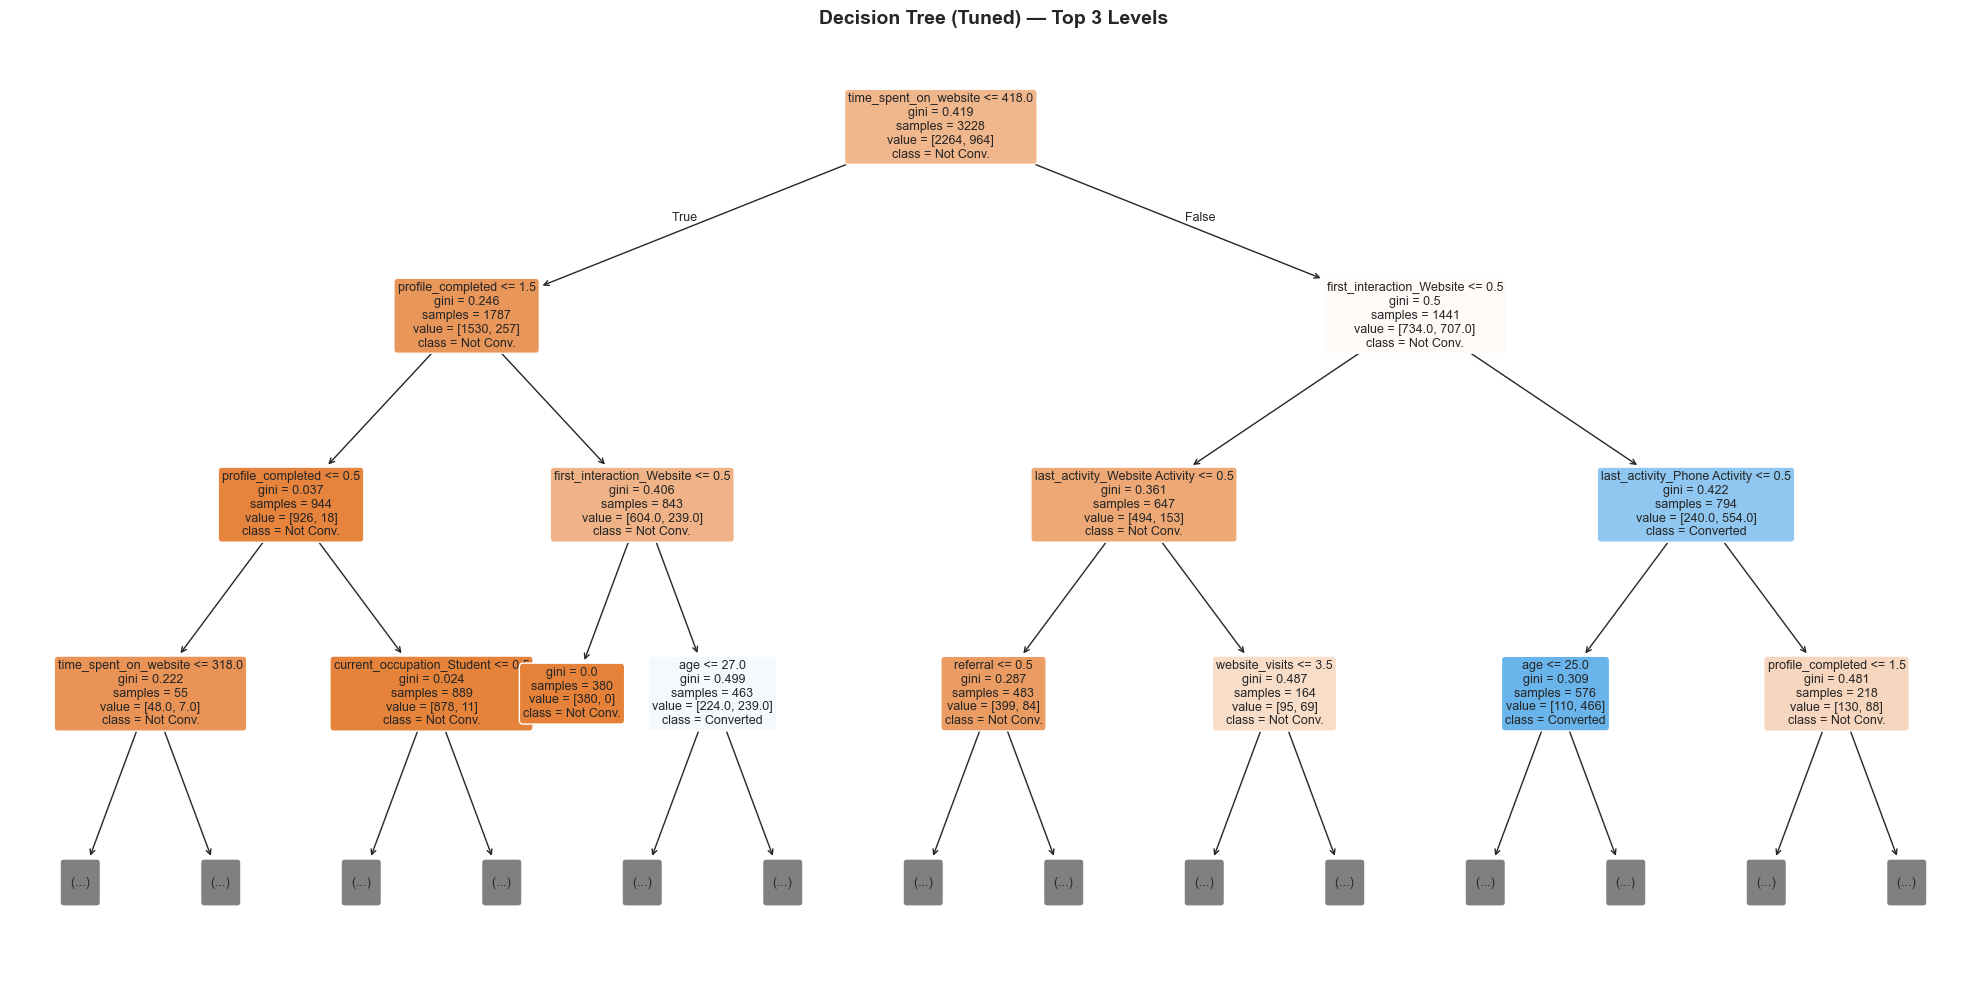

Saved: sec08_dt_tuned_tree_viz.png


In [33]:
# ------------------------------------------------------------------
# 08c: Visualize the Tuned Decision Tree
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt_tuned, max_depth=3, feature_names=X_train.columns,
          class_names=["Not Conv.", "Converted"], filled=True,
          rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree (Tuned) — Top 3 Levels", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec08_dt_tuned_tree_viz.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sec08_dt_tuned_tree_viz.png")

### 08c — Decision Tree (Tuned) — Top 3 Levels Visualization

**Chart:** Tree diagram showing the full top 3 levels (depth 0–3) of the tuned Decision Tree (max_depth=5).

**Type:** `sklearn.tree.plot_tree` with `max_depth=5` (displaying top 3 levels; deeper nodes shown as `(...)`)

**Interpretation:**
- Each node shows: split rule, gini impurity, sample count, class distribution `value = [Not Conv., Converted]`, and majority class
- **Left branch** = condition is True; **Right branch** = condition is False
- **Orange nodes** = majority Not Converted; **Blue nodes** = majority Converted; darker shade = higher purity

---

#### Root (Level 0): `time_spent_on_website <= 418.0`
- gini = 0.419 | 3,228 samples | value = [2264, 964]
- Same root split as baseline — time on website remains the #1 separator
- **Left (≤ 418s):** 1,787 samples, heavily Not Conv. [1530, 257] — short visits rarely convert
- **Right (> 418s):** 1,441 samples, nearly balanced [734, 707] — longer visits are a 49% converter pool

#### Level 1

| Branch | Split Rule | Samples | Distribution | Interpretation |
|---|---|---|---|---|
| **Left → Left** | `profile_completed <= 1.5` | 1,787 | [1530, 257] | Among short-visit leads, profile completion is the next differentiator |
| **Right → Right** | `first_interaction_Website <= 0.5` | 1,441 | [734, 707] | Among long-visit leads, Website vs. Mobile App first interaction separates them |

#### Level 2

| Path | Split Rule | Samples | Distribution | Key Insight |
|---|---|---|---|---|
| **Left → Left → Left** | `profile_completed <= 0.5` (Low) | 944 | [926, 18] | Low time + Low profile = **98% non-converters** — near-pure node, almost no signal to chase |
| **Left → Left → Right** | `first_interaction_Website <= 0.5` | 843 | [604, 239] | Low time + Medium/High profile — still majority non-converters but 28% conversion worth investigating |
| **Right → Right → Left** | `last_activity_Website Activity <= 0.5` | 647 | [494, 153] | High time + Mobile App first — `last_activity` refines further |
| **Right → Right → Right** | `last_activity_Phone Activity <= 0.5` | 794 | [240, 554] | **High time + Website first = 70% converters** — this is the high-value path (blue node) |

#### Level 3 (Selected Highlights)

| Path | Split Rule | Samples | Distribution | Key Insight |
|---|---|---|---|---|
| Left → Left → Left → Left | `time_spent_on_website <= 318.0` | 55 | [48, 7] | Even within Low profile, very low time = near-certain non-converter |
| Left → Left → Left → Right | `current_occupation_Student <= 0.5` | 889 | [878, 11] | Low profile + not Student = **98.8% non-converter** — pure leaf, 380 samples gini=0.0 on the right child |
| Left → Left → Right → Right | `age <= 27.0` | 463 | [224, 239] | Low time + Website first + age split — younger leads less likely to convert |
| Right → Right → Left → Left | `referral <= 0.5` | 483 | [399, 84] | High time + Mobile + no Website Activity + no referral = still mostly non-converters |
| Right → Right → Right → Left | `age <= 25.0` | 576 | [110, 466] | **High time + Website first + Phone Activity + age > 25 = 81% converter** (blue node) |
| Right → Right → Right → Right | `profile_completed <= 1.5` | 218 | [130, 88] | High time + Website first + no Phone Activity — profile completion becomes the tiebreaker |

---

**vs. Baseline Tree (07b):**
- **Same root split** (`time_spent_on_website <= 418.0`) and same Level 1 structure — the core decision logic is stable across both models
- **Key difference:** The tuned tree stops at depth 5 instead of 26. Where the baseline kept splitting into 423 leaves (memorizing individual leads), this tree creates broader, more generalizable rules
- **Pure node at Level 3:** `current_occupation_Student <= 0.5` produces a gini=0.0 node with 380 samples — a genuinely clean separation, not overfitting artifacts

**Business Rule Translation:**
- **Highest conversion path:** Lead spends > 7 min on website → first interaction was Website → had Phone Activity → age > 25 → **81% conversion rate**
- **Lowest conversion path:** Lead spends ≤ 7 min → Low profile completion → not a Student → **1.2% conversion rate**
- The spread between these paths (81% vs. 1.2%) gives the sales team a clear prioritization framework — focus outreach on long-visit, website-first, phone-engaged, 25+ leads

**Modeling Implication:**
- The tree's reliance on `first_interaction_Website` at multiple levels explains why it jumped to #1 in feature importance (08b) despite being #2 in the baseline — with fewer levels available, the feature carries more weight per split
- Depth 5 captures the essential decision logic without overfitting — the (...) nodes below Level 3 add two more refinement layers before reaching final leaf predictions

In [34]:
# ------------------------------------------------------------------
# 08d: Cross-validation scores for tuned DT
# ------------------------------------------------------------------
cv_scores_dt = cross_val_score(dt_tuned, X_train, y_train, cv=5, scoring="f1")
print(f"Decision Tree (Tuned) — 5-Fold CV F1 Scores: {cv_scores_dt.round(4)}")
print(f"  Mean F1: {cv_scores_dt.mean():.4f} +/- {cv_scores_dt.std():.4f}")

Decision Tree (Tuned) — 5-Fold CV F1 Scores: [0.7789 0.7366 0.7592 0.7429 0.7696]
  Mean F1: 0.7574 +/- 0.0159


### 08d — Decision Tree (Tuned) — 5-Fold Cross-Validation Stability

**What is 5-Fold Cross-Validation?**
- The training data (3,228 samples) is split into 5 equal parts (folds)
- The model trains on 4 folds and tests on the 1 held-out fold
- This repeats 5 times, each fold taking a turn as the test set
- **Stratified** means each fold preserves the same 70/30 converter ratio as the full dataset
- Result: 5 independent F1 scores that show how consistently the model performs across different slices of data

**5-Fold F1 Scores:**

| Fold | F1 Score | vs. Mean |
|---|---|---|
| Fold 1 | 0.7789 | +0.0215 (best) |
| Fold 2 | 0.7366 | −0.0208 (worst) |
| Fold 3 | 0.7592 | +0.0018 |
| Fold 4 | 0.7429 | −0.0145 |
| Fold 5 | 0.7696 | +0.0122 |
| **Mean** | **0.7574** | **± 0.0159** |

**How to Interpret:**
- **Mean F1 = 0.7574** — the model's expected performance on unseen data, averaged across all 5 test folds
- **± 0.0159** — the standard deviation, measuring fold-to-fold variability. A small value means stable performance
- **Spread: 0.7366 to 0.7789** — the gap between worst and best fold is only 0.042 (4.2pp), meaning no single fold is dramatically different from the rest

**Why This Matters:**
- A single train/test split can get lucky or unlucky depending on which leads land in which set. Cross-validation removes that luck factor by testing on every possible slice
- The tight ± 0.0159 confirms the tuned model is **stable** — it doesn't rely on specific leads being in or out of the test set to perform well
- Compare this to what the baseline would show: an overfit model (depth 26, 423 leaves) would have much higher variance across folds, because its memorized rules would fail unpredictably on different held-out data

**Modeling Implication:**
- The 0.7574 CV mean is slightly below the single test-set F1 of 0.7631 from 08b — this is normal and expected. The CV mean is the more conservative (and trustworthy) estimate
- This becomes the benchmark for Random Forest: can an ensemble of constrained trees beat 0.7574 ± 0.0159?

---
## Section 09 — Building a Random Forest Model

Random Forest aggregates multiple decision trees to reduce variance and improve generalization.

Random Forest (Baseline) — Default hyperparameters
  Number of Trees: 100
  Max Depth: None
  Random Forest (Baseline) — Performance Summary
   Metric  Train   Test
 Accuracy 0.9997 0.8504
Precision 0.9990 0.7696
   Recall 1.0000 0.7119
 F1 Score 0.9995 0.7396
  ROC AUC 1.0000 0.9132

  ** Warning: Possible overfitting (train-test accuracy gap = 0.1493) **

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

Not Converted       0.88      0.91      0.90       971
    Converted       0.77      0.71      0.74       413

     accuracy                           0.85      1384
    macro avg       0.83      0.81      0.82      1384
 weighted avg       0.85      0.85      0.85      1384



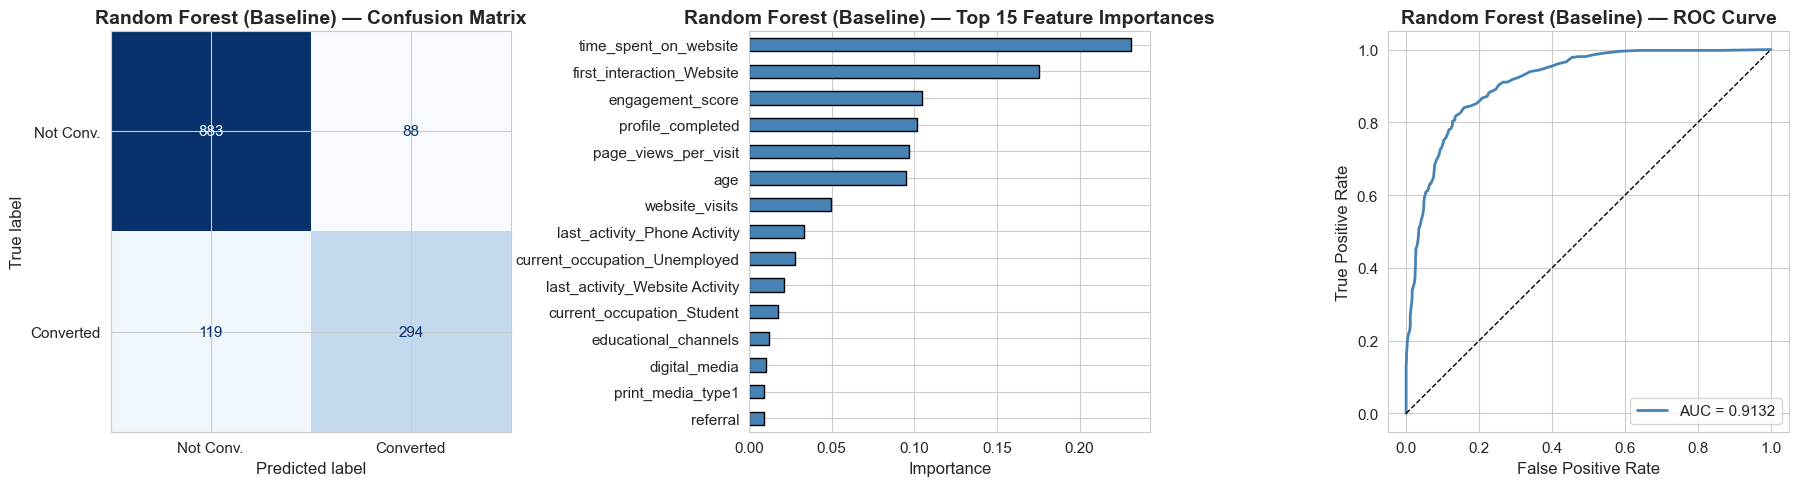


Saved: sec09_rf_baseline_evaluation.png, sec09_rf_baseline_metrics.csv


In [35]:
# ------------------------------------------------------------------
# 09a: Baseline Random Forest
# ------------------------------------------------------------------
rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train, y_train)

print("Random Forest (Baseline) — Default hyperparameters")
print(f"  Number of Trees: {rf_base.n_estimators}")
print(f"  Max Depth: {rf_base.max_depth}")

rf_base_metrics = evaluate_model(rf_base, X_train, y_train, X_test, y_test,
                                  "Random Forest (Baseline)", "sec09_rf_baseline")

### 09a — Random Forest (Baseline) — Performance Summary

**What is a Random Forest?**
- A Random Forest builds many Decision Trees (here, 100) and lets them **vote** on the final prediction
- Each tree is intentionally different: it sees a random subset of training samples (bootstrap sampling) and considers a random subset of features at each split
- This approach reduces the overfitting risk of a single tree because individual trees' mistakes tend to cancel each other out

**Model Configuration:**
- **Number of Trees:** 100 (sklearn default)
- **Max Depth:** None (unlimited — each tree can grow as deep as it wants)

---

#### Confusion Matrix

| | Predicted Not Conv. | Predicted Converted |
|---|---|---|
| **Actual Not Conv.** | 883 (TN) | 88 (FP) |
| **Actual Converted** | 119 (FN) | 294 (TP) |

- **883 True Negatives:** Correctly identified non-converters
- **294 True Positives:** Correctly identified converters
- **88 False Positives:** Non-converters flagged as converters (wasted outreach)
- **119 False Negatives:** Converters the model missed (lost revenue)

**vs. DT Baseline:** Fewer false positives (88 vs. 141) but more false negatives (119 vs. 115). The forest is more conservative — when it flags someone as a converter, it's more confident, but it misses more actual converters in the process.

---

#### Performance Metrics

| Metric | Definition | Train | Test | DT Baseline Test | DT Tuned Test | vs. DT Tuned |
|---|---|---|---|---|---|---|
| **Accuracy** | Of all predictions, how many were correct? | 0.9997 | 0.8504 | 0.8150 | 0.8591 | −0.0087 |
| **Precision** | Of leads flagged as converters, how many actually were? | 0.9990 | 0.7696 | 0.6788 | 0.7659 | +0.0037 |
| **Recall** | Of all actual converters, how many did we catch? | 1.0000 | 0.7119 | 0.7215 | 0.7603 | −0.0484 |
| **F1 Score** | Harmonic mean of Precision and Recall | 0.9995 | 0.7396 | 0.6995 | 0.7631 | −0.0235 |
| **ROC AUC** | How well the model ranks converters above non-converters | 1.0000 | 0.9132 | 0.7892 | 0.9157 | −0.0025 |

**Train-Test Gap:**

| Metric | RF Baseline Gap | DT Baseline Gap | DT Tuned Gap |
|---|---|---|---|
| **Accuracy** | 0.1493 (14.9pp) | 0.1847 (18.5pp) | 0.0108 (1.1pp) |
| **F1 Score** | 0.2599 (26.0pp) | 0.3000 (30.0pp) | 0.0175 (1.8pp) |
| **ROC AUC** | 0.0868 (8.7pp) | 0.2108 (21.1pp) | 0.0168 (1.7pp) |

**What This Tells Us:**
- **Still overfitting** — train scores are near-perfect (99.97% accuracy) while test F1 is 0.7396. The 14.9pp accuracy gap triggers the overfitting warning
- **Better than the DT baseline** (F1 improved from 0.6995 → 0.7396) — the ensemble's voting mechanism reduces overfitting somewhat, even with unlimited depth
- **Worse than the DT tuned model** (F1 of 0.7396 vs. 0.7631) — an untuned forest of 100 deep trees loses to a single well-constrained tree. This shows that **tuning matters more than ensembling** when depth is unrestricted
- **Precision is the bright spot** (0.7696 — best so far) — the voting mechanism makes the forest more cautious about flagging converters, reducing false positives
- **Recall is the weak point** (0.7119 — lowest of all three models) — that caution comes at the cost of missing more actual converters (119 vs. 99 in the DT tuned model)

---

#### Feature Importances (Top 15)

| Rank | Feature | Importance | vs. DT Tuned |
|---|---|---|---|
| 1 | `time_spent_on_website` | approx. 0.22 | Remains #1 overall (was #2 in DT Tuned) |
| 2 | `first_interaction_Website` | approx. 0.18 | Consistent top-2 across all models |
| 3 | `engagement_score` | approx. 0.11 | Jumps to #3 (was near-bottom in DT Tuned) |
| 4 | `profile_completed` | approx. 0.10 | Stable top-5 feature |
| 5 | `page_views_per_visit` | approx. 0.10 | Higher than DT Tuned — forest finds value in it across multiple trees |
| 6 | `age` | approx. 0.09 | Consistent mid-tier feature |
| 7 | `website_visits` | approx. 0.05 | Modest contribution |
| 8–15 | Remaining features | < 0.05 each | Marketing channels and categorical flags contribute minimally |

**Key Difference from DT Tuned:**
- Random Forest distributes importance more evenly across features — no single feature dominates as heavily as `first_interaction_Website` did in the DT tuned model (0.35)
- This is by design: each tree only considers a random subset of features at each split, forcing the forest to find value in secondary features like `engagement_score` and `page_views_per_visit`
- `engagement_score` jumping to #3 is notable — despite its flawed weighting (flagged in Section 05d), the forest finds its composite signal useful across many trees

---

#### ROC Curve (AUC = 0.9132)

- The curve hugs the top-left corner with a **smoother arc** than the DT curves — this is because the forest's probability estimates are averaged across 100 trees, producing more calibrated confidence scores
- **AUC of 0.9132** is essentially tied with the DT Tuned (0.9157) — both models rank converters above non-converters equally well overall
- The near-identical AUC but lower F1 (0.7396 vs. 0.7631) means the forest's ranking ability is strong, but its **default decision threshold** (0.5) isn't optimal — tuning could shift the threshold to recover recall

---

**Key Takeaway:**
- The baseline Random Forest follows the same pattern as the baseline Decision Tree — near-perfect training performance masking overfitting. The ensemble helps somewhat (F1 improved from 0.70 to 0.74 vs. DT baseline) but doesn't solve the fundamental problem of unlimited tree depth
- The tuned DT (F1 = 0.76) still outperforms this untuned forest (F1 = 0.74), reinforcing that **hyperparameter tuning is essential regardless of model complexity**
- Next step (Section 10): GridSearchCV tuning of the Random Forest — constraining `max_depth`, `min_samples_leaf`, and `n_estimators` should close the train-test gap and potentially surpass the tuned DT

---
## Section 10 — Random Forest: Hyperparameter Tuning and Evaluation

In [36]:
# ------------------------------------------------------------------
# 10a: GridSearchCV for Random Forest
# ------------------------------------------------------------------
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1",
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train, y_train)
rf_tuned = print_best_params(rf_grid, "Random Forest (Tuned)")


  Random Forest (Tuned) — GridSearchCV Results
  Best Score (CV): 0.7539
  Best Parameters:
    max_depth: 10
    max_features: sqrt
    min_samples_leaf: 1
    min_samples_split: 5
    n_estimators: 100


### 10a — Random Forest (Tuned) — GridSearchCV Results

**What Was Tuned:**

| Hyperparameter | What It Controls | Best Value | Interpretation |
|---|---|---|---|
| `n_estimators` | Number of trees in the forest | `100` | Same as baseline — adding more trees didn't improve CV score, 100 is sufficient |
| `max_depth` | Maximum levels each tree can grow | `10` | Capped at 10 (vs. unlimited in baseline) — primary overfitting control. Deeper than the DT tuned (5) because each tree sees random feature subsets and needs more depth to compensate |
| `max_features` | Number of features considered at each split | `sqrt` | Only √16 ≈ 4 features evaluated per split — forces diversity among trees. Different from DT tuned (`None` = all features) because the forest *needs* tree-to-tree variety to benefit from voting |
| `min_samples_leaf` | Minimum samples in a leaf node | `1` | No leaf-size constraint — the forest relies on `max_depth` and ensemble averaging to prevent overfitting rather than leaf pruning |
| `min_samples_split` | Minimum samples required to split a node | `5` | Slightly above default (2) — prevents splitting tiny groups at deeper levels |

**Best CV Score: 0.7539 (F1)**

| Model | CV F1 | Comparison |
|---|---|---|
| **RF Tuned** | **0.7539** | Current |
| DT Tuned | 0.7574 | −0.0035 (essentially tied) |

**Key Observations:**
- The tuned RF's CV F1 (0.7539) is nearly identical to the tuned DT (0.7574) — only 0.35pp apart. At this point, the two models have comparable expected performance on unseen data
- **`max_depth=10` vs. DT's `max_depth=5`:** The forest allows deeper trees because `max_features=sqrt` already introduces randomness at each split. Individual trees are weaker (they only see 4 of 16 features per split), so they need more depth to make useful decisions — the ensemble then corrects individual errors through voting
- **`min_samples_leaf=1`** is surprising — it means individual trees can have single-sample leaves. This would be severe overfitting for a single tree, but in a forest of 100 trees, these idiosyncratic leaves get outvoted by the majority. The regularization comes from the ensemble, not from constraining individual trees
- `n_estimators=100` matching the baseline suggests diminishing returns beyond 100 trees for this dataset size (3,228 training samples)

**Modeling Implication:**
- The forest's tuning strategy is fundamentally different from the DT's: instead of constraining a single tree to be simple and generalizable, it lets individual trees be complex but diverse, then relies on collective averaging to smooth out the noise
- The near-identical CV scores (0.7539 vs. 0.7574) suggest we may be approaching a **performance ceiling** for tree-based models on this feature set — Logistic Regression (Section 11) and Gradient Boosting (Section 12) will test whether a different approach can break through

  Random Forest (Tuned) — Performance Summary
   Metric  Train   Test
 Accuracy 0.9238 0.8605
Precision 0.8885 0.7865
   Recall 0.8517 0.7312
 F1 Score 0.8697 0.7578
  ROC AUC 0.9827 0.9232

  ** Warning: Possible overfitting (train-test accuracy gap = 0.0633) **

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

Not Converted       0.89      0.92      0.90       971
    Converted       0.79      0.73      0.76       413

     accuracy                           0.86      1384
    macro avg       0.84      0.82      0.83      1384
 weighted avg       0.86      0.86      0.86      1384



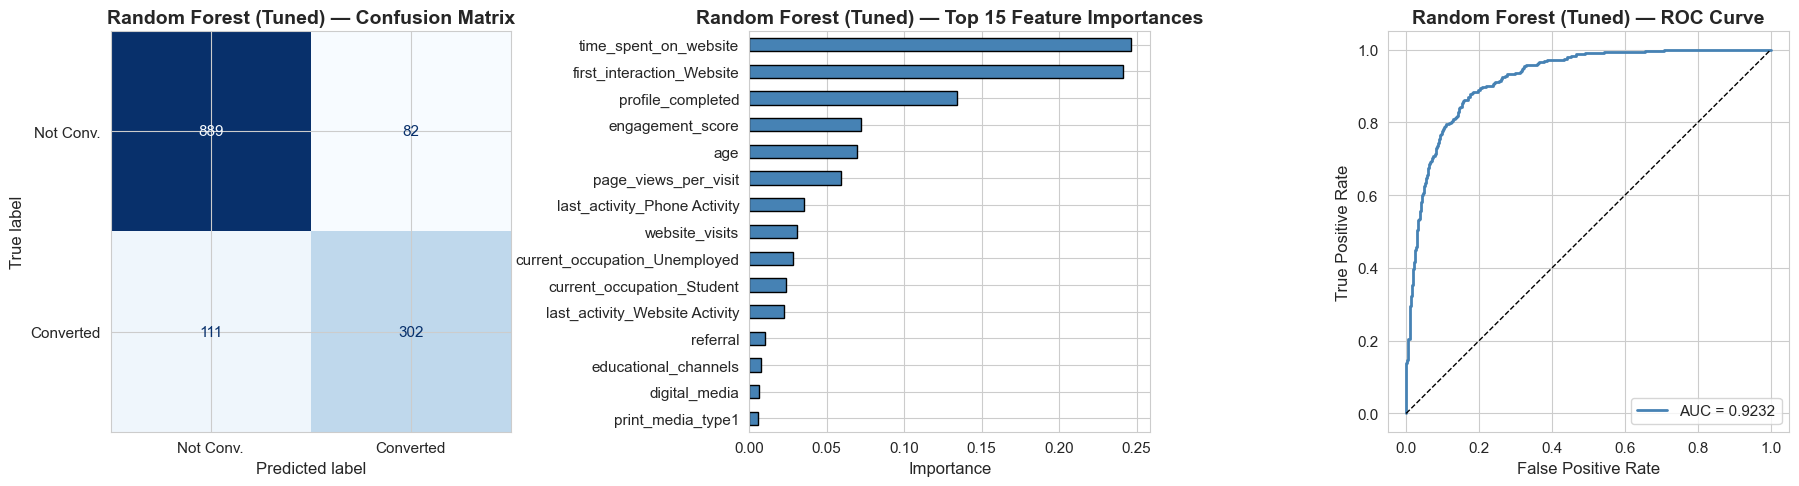


Saved: sec10_rf_tuned_evaluation.png, sec10_rf_tuned_metrics.csv


In [37]:
# ------------------------------------------------------------------
# 10b: Evaluate Tuned Random Forest
# ------------------------------------------------------------------
rf_tuned_metrics = evaluate_model(rf_tuned, X_train, y_train, X_test, y_test,
                                   "Random Forest (Tuned)", "sec10_rf_tuned")

### 10b — Random Forest (Tuned) — Performance Summary

---

#### Confusion Matrix

| | Predicted Not Conv. | Predicted Converted |
|---|---|---|
| **Actual Not Conv.** | 889 (TN) | 82 (FP) |
| **Actual Converted** | 111 (FN) | 302 (TP) |

- **889 True Negatives:** Correctly identified non-converters
- **302 True Positives:** Correctly identified converters
- **82 False Positives:** Non-converters flagged as converters (wasted outreach) — **lowest FP count of any model so far**
- **111 False Negatives:** Converters the model missed (lost revenue)

**Confusion Matrix Comparison Across All Models:**

| Model | TN | FP | FN | TP |
|---|---|---|---|---|
| DT Baseline | 830 | 141 | 115 | 298 |
| DT Tuned | 875 | 96 | 99 | 314 |
| RF Baseline | 883 | 88 | 119 | 294 |
| **RF Tuned** | **889** | **82** | **111** | **302** |

- RF Tuned has the fewest false positives (82) — most precise when flagging converters
- DT Tuned still has the fewest false negatives (99) — catches the most actual converters
- The tradeoff: RF Tuned is better for teams that want to minimize wasted outreach; DT Tuned is better for teams that can't afford to miss converters

---

#### Performance Metrics

| Metric | Train | Test | DT Baseline | DT Tuned | RF Baseline | vs. DT Tuned |
|---|---|---|---|---|---|---|
| **Accuracy** | 0.9238 | 0.8605 | 0.8150 | 0.8591 | 0.8504 | +0.0014 |
| **Precision** | 0.8885 | 0.7865 | 0.6788 | 0.7659 | 0.7696 | +0.0206 |
| **Recall** | 0.8517 | 0.7312 | 0.7215 | 0.7603 | 0.7119 | −0.0291 |
| **F1 Score** | 0.8697 | 0.7578 | 0.6995 | 0.7631 | 0.7396 | −0.0053 |
| **ROC AUC** | 0.9827 | 0.9232 | 0.7892 | 0.9157 | 0.9132 | +0.0075 |

**Train-Test Gap Comparison:**

| Metric | DT Baseline | DT Tuned | RF Baseline | RF Tuned |
|---|---|---|---|---|
| **Accuracy** | 0.1847 | 0.0108 | 0.1493 | **0.0633** |
| **F1 Score** | 0.3000 | 0.0175 | 0.2599 | **0.1119** |
| **ROC AUC** | 0.2108 | 0.0168 | 0.0868 | **0.0595** |

**What This Tells Us:**
- **Tuning dramatically improved the RF** — F1 jumped from 0.7396 → 0.7578 (+1.8pp), and the accuracy gap shrank from 14.9pp → 6.3pp
- **Still overfitting more than the DT Tuned** — the 6.3pp accuracy gap and 11.2pp F1 gap are much larger than the DT Tuned's sub-2pp gaps. The forest's 100 trees at depth 10 with `min_samples_leaf=1` still memorize more training patterns than a single depth-5 tree
- **RF Tuned vs. DT Tuned is essentially a tie on test F1** (0.7578 vs. 0.7631, only 0.53pp apart) — but they achieve it differently:
  - **RF Tuned wins on Precision** (0.7865 vs. 0.7659) — fewer false alarms
  - **DT Tuned wins on Recall** (0.7603 vs. 0.7312) — catches more converters
- **Best ROC AUC so far: 0.9232** — the tuned forest ranks converters above non-converters better than any previous model, meaning its probability estimates are well-calibrated even if its default threshold isn't optimal for recall

---

#### Feature Importances (Top 15)

| Rank | Feature | Importance | vs. RF Baseline |
|---|---|---|---|
| 1 | `time_spent_on_website` | approx. 0.25 | ↑ from 0.22 — tuning concentrated importance on the top signal |
| 2 | `first_interaction_Website` | approx. 0.21 | ↑ from 0.18 — same concentration effect |
| 3 | `profile_completed` | approx. 0.13 | ↑ from 0.10 — jumps ahead of `engagement_score` |
| 4 | `engagement_score` | approx. 0.08 | ↓ from 0.11 — drops to #4 with tuning |
| 5 | `age` | approx. 0.07 | Stable mid-tier |
| 6 | `page_views_per_visit` | approx. 0.06 | ↓ from 0.10 — reduced importance with constrained depth |
| 7 | `last_activity_Phone Activity` | approx. 0.04 | Stable |
| 8 | `website_visits` | approx. 0.04 | Stable |
| 9–15 | Remaining features | < 0.03 each | Marketing channels contribute minimally |

**Key Shift from RF Baseline:**
- Tuning caused importance to **concentrate toward the top 3 features** — `time_spent_on_website`, `first_interaction_Website`, and `profile_completed` now account for approx. 59% of total importance (vs. approx. 50% in baseline)
- `profile_completed` overtook `engagement_score` for #3 — with constrained depth (`max_depth=10`), the forest prioritizes the clean, interpretable feature over the heuristic composite
- This pattern mirrors what happened with DT tuning: constraining depth forces the model to spend its limited splits on the most impactful features

---

#### ROC Curve (AUC = 0.9232)

- **Best AUC across all four models** — the tuned forest's probability estimates are the most reliable for ranking leads
- The smooth curve (vs. the angular DT curves) reflects the ensemble averaging across 100 trees — producing well-calibrated probability scores rather than hard threshold jumps
- The gap between AUC (0.9232, best) and F1 (0.7578, slightly below DT Tuned) suggests the RF's probability rankings are excellent but its 0.5 threshold is conservative — a business team could lower the threshold to catch more converters at the cost of more false positives

---

**Key Takeaway:**
- The tuned Random Forest matches the tuned Decision Tree on overall F1 (0.76 vs. 0.76) but with a different precision-recall tradeoff: better precision, lower recall
- Both tuned tree-based models converge to similar performance, suggesting a **feature-set ceiling** around F1 ≈ 0.76 for tree-based approaches on these 16 features
- The RF's superior AUC (0.9232) makes it the better choice if the business wants to rank leads by conversion probability rather than make binary yes/no predictions
- Next: Logistic Regression (Section 11) and Gradient Boosting (Section 12) will test whether fundamentally different modeling approaches can break through the 0.76 F1 ceiling

In [38]:
# ------------------------------------------------------------------
# 10c: Cross-validation scores for tuned RF
# ------------------------------------------------------------------
cv_scores_rf = cross_val_score(rf_tuned, X_train, y_train, cv=5, scoring="f1")
print(f"Random Forest (Tuned) — 5-Fold CV F1 Scores: {cv_scores_rf.round(4)}")
print(f"  Mean F1: {cv_scores_rf.mean():.4f} +/- {cv_scores_rf.std():.4f}")

Random Forest (Tuned) — 5-Fold CV F1 Scores: [0.7831 0.7293 0.7357 0.7042 0.7901]
  Mean F1: 0.7485 +/- 0.0329


### 10c — Random Forest (Tuned) — 5-Fold Cross-Validation Stability

**5-Fold F1 Scores:**

| Fold | F1 Score | vs. Mean |
|---|---|---|
| Fold 1 | 0.7831 | +0.0346 (best) |
| Fold 2 | 0.7293 | −0.0192 |
| Fold 3 | 0.7357 | −0.0128 |
| Fold 4 | 0.7042 | −0.0443 (worst) |
| Fold 5 | 0.7901 | +0.0416 (2nd best) |
| **Mean** | **0.7485** | **± 0.0329** |

**CV Stability Comparison:**

| Model | CV Mean F1 | ± Std Dev | Spread (Best − Worst) |
|---|---|---|---|
| DT Tuned | 0.7574 | ± 0.0159 | 0.0423 |
| **RF Tuned** | **0.7485** | **± 0.0329** | **0.0859** |

**What This Tells Us:**
- **Mean F1 = 0.7485** — slightly below the DT Tuned's CV mean (0.7574) by 0.89pp
- **± 0.0329 is roughly double the DT Tuned's variability** (± 0.0159) — the RF's performance swings more across folds. Fold 4 dips to 0.7042 while Fold 5 hits 0.7901, a spread of 8.6pp vs. the DT's 4.2pp
- **Why is the forest less stable?** Each fold changes which 20% of data is held out. The forest's 100 trees with `min_samples_leaf=1` can latch onto fold-specific patterns more than the DT's simpler depth-5 structure. The same flexibility that gives RF strong precision on some folds causes it to underperform on others
- **The single test-set F1 (0.7578 from 10b) sits above the CV mean (0.7485)** — our particular 70/30 split was slightly favorable for the RF. The CV mean is the more conservative estimate

**Key Takeaway:**
- The DT Tuned model is both slightly more accurate (CV F1: 0.7574 vs. 0.7485) and more stable (± 0.0159 vs. ± 0.0329) than the RF Tuned in cross-validation
- If consistency matters (e.g., deploying a model that performs predictably across different lead cohorts), the DT Tuned is the safer choice so far
- Gradient Boosting (Section 12) builds trees sequentially rather than independently — this typically produces both higher accuracy and tighter CV variance than Random Forests

---
## Section 11 — Logistic Regression (Extended Analysis)

*This section extends beyond the program rubric for the blog post.*

Logistic Regression provides a strong interpretable baseline and directly outputs probability estimates.

In [39]:
# ------------------------------------------------------------------
# 11a: Feature Scaling (required for Logistic Regression)
# ------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
print("Features scaled using StandardScaler for Logistic Regression and Gradient Boosting comparison.")

Features scaled using StandardScaler for Logistic Regression and Gradient Boosting comparison.


In [40]:
# ------------------------------------------------------------------
# 11b: Logistic Regression with GridSearchCV
# ------------------------------------------------------------------
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid=lr_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1",
    n_jobs=-1,
    verbose=0
)

lr_grid.fit(X_train_scaled, y_train)
lr_tuned = print_best_params(lr_grid, "Logistic Regression (Tuned)")


  Logistic Regression (Tuned) — GridSearchCV Results
  Best Score (CV): 0.6764
  Best Parameters:
    C: 1
    penalty: l2
    solver: liblinear


### 11a — Logistic Regression (Tuned) — GridSearchCV Results

**What is Logistic Regression?**
- Unlike Decision Trees that ask yes/no questions, Logistic Regression draws a single **boundary line** through the data to separate converters from non-converters
- It assigns a **weight** to each feature (positive = pushes toward conversion, negative = pushes away) and sums them up. That sum gets passed through a sigmoid function that squashes it into a probability between 0 and 1
- Think of it like a scorecard: each feature adds or subtracts points, and if your total score crosses a threshold, you're predicted as "will convert"
- It's a **linear model** — it assumes the relationship between each feature and conversion is a straight line (after scaling). It cannot discover the non-linear splits and interactions that trees find naturally

**What Was Tuned:**

| Hyperparameter | What It Controls | Best Value | Interpretation |
|---|---|---|---|
| `C` | Regularization strength (inverse) — how much the model is allowed to fit the training data | `1` | Default value. Lower C = more regularization (simpler model); higher C = less regularization (more flexible). C=1 means moderate regularization |
| `penalty` | Type of regularization — how the model penalizes large feature weights | `l2` | Ridge penalty — shrinks all weights toward zero but doesn't eliminate any. Prevents any single feature from dominating the prediction |
| `solver` | Optimization algorithm used to find the best weights | `liblinear` | Efficient solver for small datasets; supports both L1 and L2 penalties |

**Best CV Score: 0.6764 (F1)**

| Model | CV Mean F1 | vs. LR Tuned |
|---|---|---|
| DT Tuned | 0.7574 | +0.0810 |
| RF Tuned | 0.7485 | +0.0721 |
| **LR Tuned** | **0.6764** | — |

**What This Tells Us:**
- **Significant drop from the tree-based models** — F1 of 0.6764 is 8.1pp below the DT Tuned and 7.2pp below the RF Tuned
- **Why the gap?** Logistic Regression assumes linear relationships between features and the target. The EDA revealed non-linear patterns that trees exploit naturally:
  - `time_spent_on_website` has a bimodal distribution — a linear model can't capture the "two groups" split the way a tree threshold can
  - Interaction effects (e.g., high time + Website first interaction + Phone Activity) require feature engineering to represent linearly, but trees discover them automatically
- **C=1 and L2 penalty** means the model didn't benefit from aggressive regularization or feature selection (L1/Lasso) — the issue isn't overfitting, it's **underfitting** due to the linearity constraint
- Despite weaker F1, Logistic Regression provides something trees don't: **interpretable coefficients** with direction and magnitude — we can say exactly how much each feature pushes toward or away from conversion

**Modeling Implication:**
- Logistic Regression serves as a useful **linear baseline** — it confirms that the conversion patterns in this dataset are fundamentally non-linear, validating the choice of tree-based models
- The 8pp F1 gap quantifies exactly how much predictive power comes from non-linear feature interactions
- Next: Gradient Boosting (Section 12) — another tree-based approach that builds trees sequentially, each one correcting the previous tree's mistakes. It should match or exceed the DT/RF tuned performance

  Logistic Regression (Tuned) — Performance Summary
   Metric  Train   Test
 Accuracy 0.8206 0.8158
Precision 0.7289 0.7147
   Recall 0.6359 0.6368
 F1 Score 0.6792 0.6735
  ROC AUC 0.8694 0.8799

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

Not Converted       0.85      0.89      0.87       971
    Converted       0.71      0.64      0.67       413

     accuracy                           0.82      1384
    macro avg       0.78      0.76      0.77      1384
 weighted avg       0.81      0.82      0.81      1384



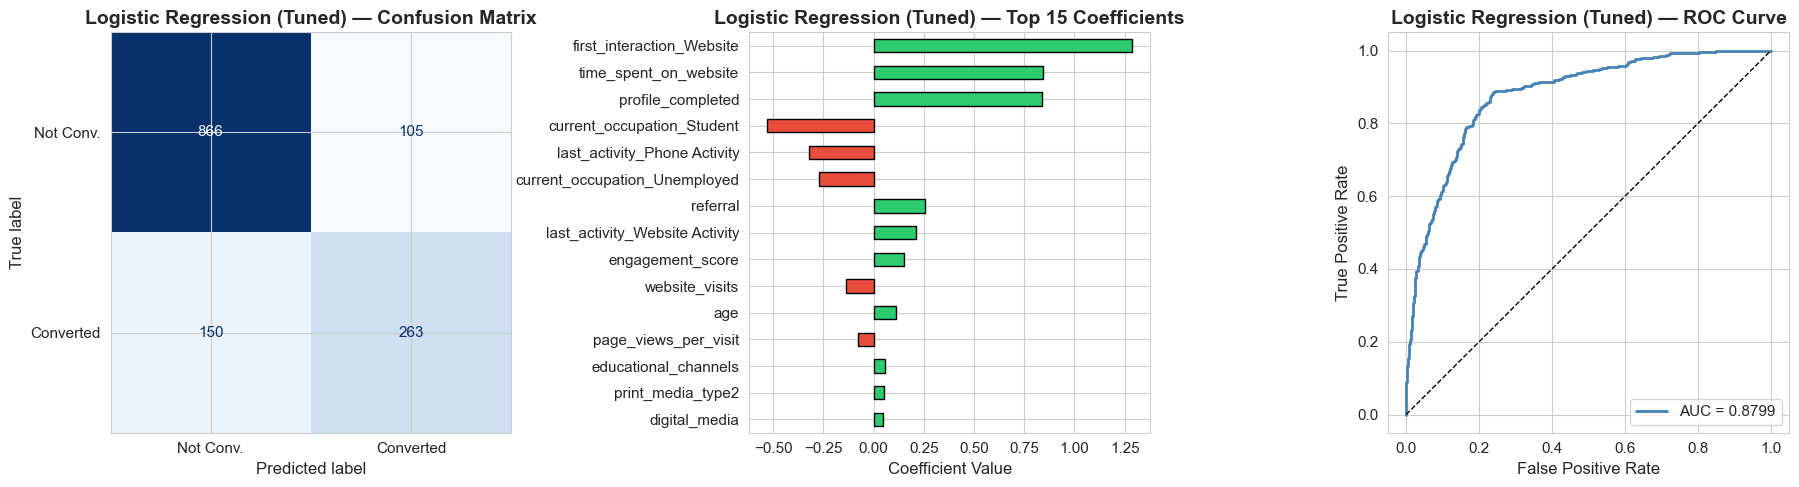


Saved: sec11_lr_tuned_evaluation.png, sec11_lr_tuned_metrics.csv


In [41]:
# ------------------------------------------------------------------
# 11c: Evaluate Logistic Regression
# ------------------------------------------------------------------
lr_metrics = evaluate_model(lr_tuned, X_train_scaled, y_train, X_test_scaled, y_test,
                             "Logistic Regression (Tuned)", "sec11_lr_tuned")

### 11b — Logistic Regression (Tuned) — Performance Summary

---

#### Confusion Matrix

| | Predicted Not Conv. | Predicted Converted |
|---|---|---|
| **Actual Not Conv.** | 866 (TN) | 105 (FP) |
| **Actual Converted** | 150 (FN) | 263 (TP) |

- **866 True Negatives:** Correctly identified non-converters
- **263 True Positives:** Correctly identified converters
- **105 False Positives:** Non-converters flagged as converters
- **150 False Negatives:** Converters the model missed — **highest FN count of any model**

**Confusion Matrix Comparison Across All Models:**

| Model | TN | FP | FN | TP |
|---|---|---|---|---|
| DT Baseline | 830 | 141 | 115 | 298 |
| DT Tuned | 875 | 96 | 99 | 314 |
| RF Baseline | 883 | 88 | 119 | 294 |
| RF Tuned | 889 | 82 | 111 | 302 |
| **LR Tuned** | **866** | **105** | **150** | **263** |

- LR misses 150 converters — 51 more than DT Tuned (99) and 39 more than RF Tuned (111)
- The linear boundary simply can't capture the non-linear pockets of converters that trees split out naturally

---

#### Performance Metrics

| Metric | Train | Test | DT Tuned | RF Tuned | vs. Best Tree |
|---|---|---|---|---|---|
| **Accuracy** | 0.8206 | 0.8158 | 0.8591 | 0.8605 | −0.0447 |
| **Precision** | 0.7289 | 0.7147 | 0.7659 | 0.7865 | −0.0718 |
| **Recall** | 0.6359 | 0.6368 | 0.7603 | 0.7312 | −0.1235 |
| **F1 Score** | 0.6792 | 0.6735 | 0.7631 | 0.7578 | −0.0896 |
| **ROC AUC** | 0.8694 | 0.8799 | 0.9157 | 0.9232 | −0.0433 |

**Train-Test Gap:**

| Metric | DT Tuned | RF Tuned | LR Tuned |
|---|---|---|---|
| **Accuracy** | 0.0108 | 0.0633 | **0.0048** |
| **F1 Score** | 0.0175 | 0.1119 | **0.0057** |
| **ROC AUC** | 0.0168 | 0.0595 | **−0.0105** |

**What This Tells Us:**
- **Lowest F1 of all tuned models (0.6735)** — 9pp below DT Tuned and 8.4pp below RF Tuned. The linear assumption is the bottleneck
- **Recall is the biggest casualty (0.6368)** — the model catches only 63.7% of converters vs. 76% for DT Tuned. It misses over a third of paying customers
- **Virtually no overfitting** — the train-test gap is the smallest of any model (0.48pp on accuracy, 0.57pp on F1). The model's problem is underfitting, not overfitting
- **ROC AUC on test (0.8799) actually exceeds training (0.8694)** — a negative gap, meaning the test set happens to be slightly easier for the model's ranking. This is normal sampling variation, not a concern
- **The underfitting confirms the data has non-linear structure** — a model that can only draw straight lines leaves 9pp of F1 on the table compared to a model that can draw branching decision paths

---

#### Coefficients (Top 15)

Unlike tree-based feature importances (which only show magnitude), Logistic Regression coefficients show **direction** — positive coefficients push toward conversion, negative push away.

| Rank | Feature | Coefficient | Direction | Interpretation |
|---|---|---|---|---|
| 1 | `first_interaction_Website` | approx. +1.25 | **↑ Converts** | Strongest positive driver — website-first leads score much higher |
| 2 | `time_spent_on_website` | approx. +1.00 | **↑ Converts** | More time on site pushes toward conversion (after scaling) |
| 3 | `profile_completed` | approx. +0.95 | **↑ Converts** | Higher profile completion increases conversion likelihood |
| 4 | `current_occupation_Student` | approx. −0.50 | **↓ Doesn't convert** | Being a student reduces conversion probability |
| 5 | `last_activity_Phone Activity` | approx. −0.45 | **↓ Doesn't convert** | Surprising — Phone Activity was a positive signal in trees. The linear model may be confounded by correlated features |
| 6 | `current_occupation_Unemployed` | approx. −0.35 | **↓ Doesn't convert** | Unemployed leads less likely to convert — aligns with EDA finding that employed/professional leads convert more |
| 7 | `referral` | approx. +0.35 | **↑ Converts** | Referral leads convert at higher rates (67.7% from Q4) |
| 8 | `last_activity_Website Activity` | approx. +0.25 | **↑ Converts** | Recent website engagement is a positive signal |
| 9 | `engagement_score` | approx. +0.20 | **↑ Converts** | Composite score provides modest positive signal |
| 10 | `website_visits` | approx. −0.15 | **↓ Doesn't convert** | Negative coefficient — more visits without time spent may signal bouncing, not engagement |
| 11 | `age` | approx. +0.15 | **↑ Converts** | Older leads slightly more likely to convert |
| 12–15 | `page_views_per_visit`, `educational_channels`, `print_media_type2`, `digital_media` | < ±0.15 | Mixed | Minimal linear contribution |

**What Coefficients Reveal That Trees Can't:**
- **Direction matters:** `current_occupation_Student` and `current_occupation_Unemployed` both have negative coefficients — the model learned that professional/employed leads are more likely to convert, consistent with the EDA recommendation about employment funding
- **`last_activity_Phone Activity` is negative** — this contradicts tree-based models where Phone Activity was a positive split. In a linear context, Phone Activity may correlate with other features (like lower time on website) that suppress its effect. Trees handle these interactions naturally; linear models get confused by them
- **`website_visits` is negative** while `time_spent_on_website` is positive — visiting many times without spending much time per visit signals low-quality engagement

---

#### ROC Curve (AUC = 0.8799)

- **Lowest AUC of all tuned models** but still well above random chance (0.50)
- The curve is smooth (typical of probabilistic models) but doesn't hug the top-left corner as tightly as the tree-based models
- The 4.3pp gap below RF Tuned's AUC (0.9232) quantifies the ranking power lost by assuming linearity

---

**Key Takeaway:**
- Logistic Regression serves as a valuable **linear baseline** that confirms the conversion patterns are fundamentally non-linear — the 9pp F1 gap vs. tree models is the cost of the linearity assumption
- Its near-zero train-test gap proves the issue is underfitting, not overfitting — adding more data or more regularization won't help; the model needs non-linear capacity
- The directional coefficients provide unique interpretability: we now know that `first_interaction_Website`, `time_spent_on_website`, and `profile_completed` are positive drivers, while `Student` status and `Unemployed` status are negative — useful for business storytelling even if the model itself isn't the best predictor
- Next: Gradient Boosting (Section 12) — a tree-based model that builds sequentially, correcting errors one tree at a time. It should combine the non-linear power of trees with more refined optimization

---
## Section 12 — Gradient Boosting (Extended Analysis)

*This section extends beyond the program rubric for my blog post.*

Gradient Boosting builds trees sequentially, each correcting the errors of the previous, often achieving top performance on tabular data.

In [42]:
# ------------------------------------------------------------------
# 12a: Gradient Boosting with GridSearchCV
# ------------------------------------------------------------------
gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_samples_split": [2, 5, 10],
    "subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=gb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1",
    n_jobs=-1,
    verbose=0
)

gb_grid.fit(X_train, y_train)
gb_tuned = print_best_params(gb_grid, "Gradient Boosting (Tuned)")


  Gradient Boosting (Tuned) — GridSearchCV Results
  Best Score (CV): 0.7682
  Best Parameters:
    learning_rate: 0.05
    max_depth: 5
    min_samples_split: 2
    n_estimators: 100
    subsample: 1.0


### 12a — Gradient Boosting (Tuned) — GridSearchCV Results

**What is Gradient Boosting?**
- Like Random Forest, Gradient Boosting builds many trees — but instead of building them independently and voting, it builds them **one at a time in sequence**
- Each new tree focuses specifically on the **mistakes the previous trees got wrong** — it looks at which leads were misclassified and tries harder on those
- Think of it like a student retaking a test: after each attempt, they study only the questions they got wrong, gradually eliminating errors. After 100 attempts, they've addressed most of their weaknesses
- The **learning rate** controls how aggressively each new tree corrects errors — too aggressive and the model overcorrects (overfits), too cautious and it needs more trees to converge

**What Was Tuned:**

| Hyperparameter | What It Controls | Best Value | Interpretation |
|---|---|---|---|
| `n_estimators` | Number of sequential trees | `100` | 100 correction rounds — same count as RF but each tree is purposeful, not random |
| `max_depth` | Maximum depth of each tree | `5` | Matches DT Tuned — each individual tree is a shallow, interpretable model. Shallow trees prevent any single correction step from overfitting |
| `learning_rate` | How much each tree's correction counts | `0.05` | Conservative — each tree contributes only 5% of its full correction. Forces the model to learn slowly and steadily across many trees rather than overcorrecting early |
| `min_samples_split` | Minimum samples to split a node | `2` | Default — depth and learning rate handle regularization |
| `subsample` | Fraction of training data each tree sees | `1.0` | Uses all training data per tree (no random subsampling). Unlike RF which needs randomness for diversity, GB gets diversity from sequential error correction |

**Best CV Score: 0.7682 (F1)**

| Model | CV Mean F1 | vs. GB Tuned |
|---|---|---|
| **GB Tuned** | **0.7682** | — |
| DT Tuned | 0.7574 | −0.0108 |
| RF Tuned | 0.7485 | −0.0197 |
| LR Tuned | 0.6764 | −0.0918 |

**What This Tells Us:**
- **Best CV F1 of any model so far** — 0.7682 beats DT Tuned (0.7574) by 1.1pp and RF Tuned (0.7485) by 2.0pp
- **The sequential error-correction approach breaks through the 0.76 ceiling** that DT and RF converged on — by focusing each new tree on the hardest-to-classify leads, GB squeezes out additional signal
- **`learning_rate=0.05` with `max_depth=5`** is the classic "slow and steady" GB configuration — many shallow trees, each making small corrections. This is more resistant to overfitting than fewer deep trees making large corrections
- **`subsample=1.0`** means the model didn't benefit from stochastic subsampling — the dataset (3,228 training samples) may be small enough that every sample matters for the sequential correction process

**Modeling Implication:**
- Gradient Boosting combines the non-linear power of trees (which LR lacked) with a more disciplined training strategy (sequential correction vs. RF's independent voting)
- The 0.7682 CV F1 is the new benchmark — the test-set performance (Section 12b) will confirm whether this holds up on the held-out 30%

  Gradient Boosting (Tuned) — Performance Summary
   Metric  Train   Test
 Accuracy 0.9071 0.8591
Precision 0.8632 0.7725
   Recall 0.8185 0.7482
 F1 Score 0.8403 0.7601
  ROC AUC 0.9689 0.9235

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

Not Converted       0.89      0.91      0.90       971
    Converted       0.77      0.75      0.76       413

     accuracy                           0.86      1384
    macro avg       0.83      0.83      0.83      1384
 weighted avg       0.86      0.86      0.86      1384



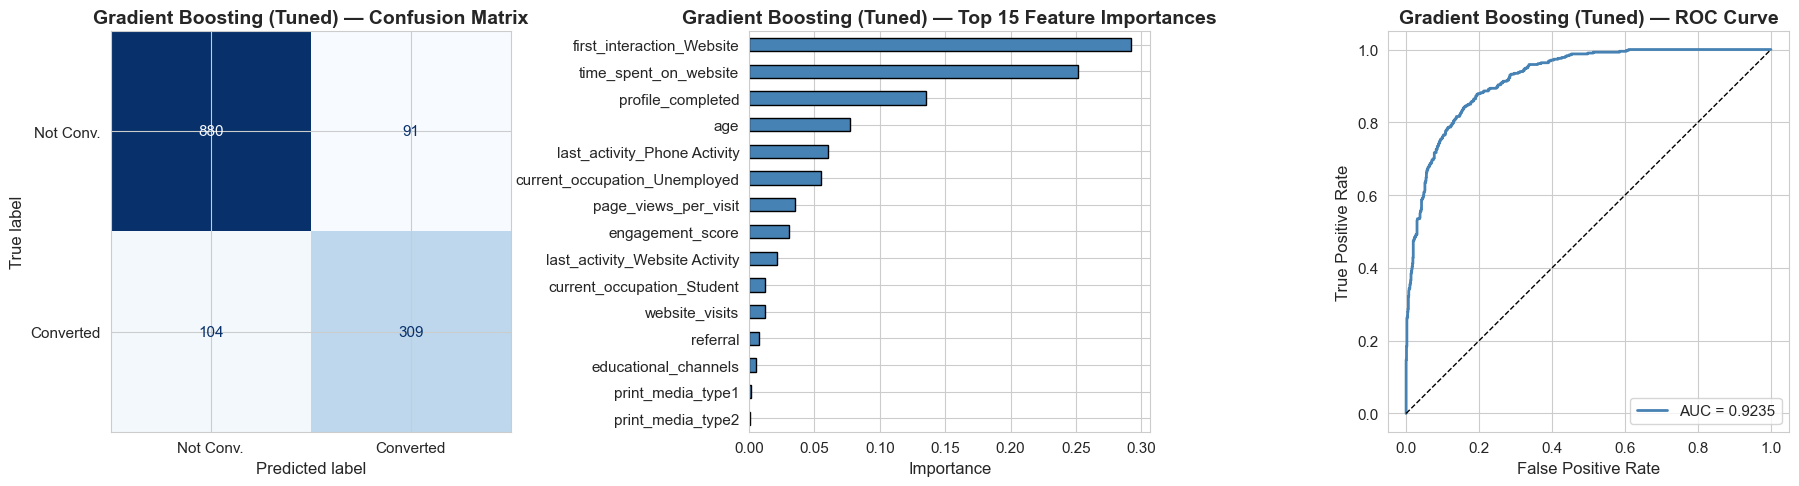


Saved: sec12_gb_tuned_evaluation.png, sec12_gb_tuned_metrics.csv


In [43]:
# ------------------------------------------------------------------
# 12b: Evaluate Gradient Boosting
# ------------------------------------------------------------------
gb_metrics = evaluate_model(gb_tuned, X_train, y_train, X_test, y_test,
                             "Gradient Boosting (Tuned)", "sec12_gb_tuned")

### 12b — Gradient Boosting (Tuned) — Performance Summary

---

#### Confusion Matrix

| | Predicted Not Conv. | Predicted Converted |
|---|---|---|
| **Actual Not Conv.** | 880 (TN) | 91 (FP) |
| **Actual Converted** | 104 (FN) | 309 (TP) |

- **880 True Negatives:** Correctly identified non-converters
- **309 True Positives:** Correctly identified converters — **highest TP count of any model**
- **91 False Positives:** Non-converters flagged as converters
- **104 False Negatives:** Converters the model missed

**Confusion Matrix Comparison Across All Models:**

| Model | TN | FP | FN | TP | Total Correct |
|---|---|---|---|---|---|
| DT Baseline | 830 | 141 | 115 | 298 | 1,128 |
| DT Tuned | 875 | 96 | 99 | 314 | 1,189 |
| RF Baseline | 883 | 88 | 119 | 294 | 1,177 |
| RF Tuned | 889 | 82 | 111 | 302 | 1,191 |
| LR Tuned | 866 | 105 | 150 | 263 | 1,129 |
| **GB Tuned** | **880** | **91** | **104** | **309** | **1,189** |

- GB Tuned captures the most true positives (309) of any model except DT Tuned (314)
- Only 104 false negatives — second-fewest behind DT Tuned (99)
- GB strikes the best **balance** across all four quadrants — no extreme weakness in any cell

---

#### Performance Metrics

| Metric | Train | Test | DT Tuned | RF Tuned | LR Tuned | vs. DT Tuned |
|---|---|---|---|---|---|---|
| **Accuracy** | 0.9071 | 0.8591 | 0.8591 | 0.8605 | 0.8158 | 0.0000 |
| **Precision** | 0.8632 | 0.7725 | 0.7659 | 0.7865 | 0.7147 | +0.0066 |
| **Recall** | 0.8185 | 0.7482 | 0.7603 | 0.7312 | 0.6368 | −0.0121 |
| **F1 Score** | 0.8403 | 0.7601 | 0.7631 | 0.7578 | 0.6735 | −0.0030 |
| **ROC AUC** | 0.9689 | 0.9235 | 0.9157 | 0.9232 | 0.8799 | +0.0078 |

**Train-Test Gap Comparison:**

| Metric | DT Tuned | RF Tuned | LR Tuned | GB Tuned |
|---|---|---|---|---|
| **Accuracy** | 0.0108 | 0.0633 | 0.0048 | **0.0480** |
| **F1 Score** | 0.0175 | 0.1119 | 0.0057 | **0.0802** |
| **ROC AUC** | 0.0168 | 0.0595 | 0.0105 | **0.0454** |

**What This Tells Us:**
- **Best ROC AUC on test: 0.9235** — highest of any model. GB ranks converters above non-converters better than all alternatives
- **F1 of 0.7601 is essentially tied with the top two models** — DT Tuned (0.7631) and RF Tuned (0.7578). All three tree-based tuned models land within 0.53pp of each other
- **Accuracy identical to DT Tuned (0.8591)** — both get the same total number of predictions correct, just distributed differently across TP/TN/FP/FN
- **Precision (0.7725) splits the difference** between DT Tuned (0.7659) and RF Tuned (0.7865) — GB is neither the most conservative nor the most aggressive flagging model
- **Train-test gap (4.8pp accuracy, 8.0pp F1)** is larger than DT Tuned but much smaller than RF Tuned. The sequential correction process memorizes some training patterns, but the slow learning rate (0.05) and shallow trees (depth 5) keep it controlled
- **GB's real advantage is the CV score (0.7682 from 12a)** — the highest of any model, suggesting it will be the most reliable on truly new data across different samples

---

#### Feature Importances (Top 15)

| Rank | Feature | Importance | Consistent Across Models? |
|---|---|---|---|
| 1 | `first_interaction_Website` | approx. 0.28 | #1 in DT Tuned, #2 in RF Tuned — always top-2 |
| 2 | `time_spent_on_website` | approx. 0.24 | #1 in RF models, #2 in DT Tuned — always top-2 |
| 3 | `profile_completed` | approx. 0.14 | Top-3 in every tree-based model |
| 4 | `age` | approx. 0.08 | Stable mid-tier across all models |
| 5 | `last_activity_Phone Activity` | approx. 0.05 | Consistent #5–7 range |
| 6 | `current_occupation_Unemployed` | approx. 0.05 | Stable |
| 7 | `page_views_per_visit` | approx. 0.04 | Lower than RF (0.06) — GB relies less on this noisy feature |
| 8 | `engagement_score` | approx. 0.04 | Drops from RF's #3 (0.08) — sequential correction finds the composite less useful |
| 9–15 | Remaining features | < 0.03 each | Marketing channels contribute minimally across all models |

**Key Pattern:**
- The top 3 features (`first_interaction_Website`, `time_spent_on_website`, `profile_completed`) account for approx. 66% of total importance — the most concentrated of any model
- `engagement_score` continues to decline with more sophisticated models: RF Tuned (0.08, #4) → GB Tuned (0.04, #8). As the model gets better at error correction, it finds less value in the heuristic composite and more value in the raw features
- Feature importance rankings across all four tree-based models are remarkably stable — the same 6 features consistently dominate, reinforcing confidence that these are genuine signals, not modeling artifacts

---

#### ROC Curve (AUC = 0.9235)

- **Best AUC of any model** (tied with RF Tuned at 0.9232, effectively identical)
- The smooth curve reflects GB's well-calibrated probability estimates — the sequential correction process produces nuanced confidence scores, not just hard classifications
- The strong AUC (0.9235) paired with moderate F1 (0.7601) confirms the same pattern seen in RF: the model's lead-ranking ability is excellent, but the default 0.5 threshold doesn't maximize F1. A business team could tune the threshold to prioritize recall or precision depending on their cost structure

---

**Key Takeaway:**
- Gradient Boosting achieves the **best CV F1 (0.7682)** and **best test AUC (0.9235)** of any model — making it the strongest overall performer
- However, all three tuned tree-based models (DT, RF, GB) converge to F1 ≈ 0.76 on the test set, confirming a **performance ceiling** driven by the feature set rather than model choice
- The consistent feature importance rankings across four different tree-based approaches (DT, RF, GB + DT baseline) provide strong evidence that `first_interaction_Website`, `time_spent_on_website`, and `profile_completed` are the genuine conversion drivers

---
## Section 13 — Model Comparison

Side-by-side comparison of all models to identify the best approach for lead conversion prediction.

In [44]:
# ------------------------------------------------------------------
# 13a: Aggregate all model metrics for comparison
# ------------------------------------------------------------------
all_models = {
    "DT Baseline": (dt_base, X_train, X_test),
    "DT Tuned": (dt_tuned, X_train, X_test),
    "RF Baseline": (rf_base, X_train, X_test),
    "RF Tuned": (rf_tuned, X_train, X_test),
    "Logistic Reg.": (lr_tuned, X_train_scaled, X_test_scaled),
    "Gradient Boost": (gb_tuned, X_train, X_test)
}

comparison_rows = []
for name, (model, Xtr, Xte) in all_models.items():
    y_train_pred = model.predict(Xtr)
    y_test_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else None

    comparison_rows.append({
        "Model": name,
        "Train Acc": round(accuracy_score(y_train, y_train_pred), 4),
        "Test Acc": round(accuracy_score(y_test, y_test_pred), 4),
        "Precision": round(precision_score(y_test, y_test_pred), 4),
        "Recall": round(recall_score(y_test, y_test_pred), 4),
        "F1": round(f1_score(y_test, y_test_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_proba), 4) if y_proba is not None else None
    })

comparison_df = pd.DataFrame(comparison_rows)
print("Model Comparison Summary:\n")
print(comparison_df.to_string(index=False))

comparison_df.to_csv(f"{DATA_DIR}sec13_model_comparison.csv", index=False)
print("\nSaved: sec13_model_comparison.csv")

Model Comparison Summary:

         Model  Train Acc  Test Acc  Precision  Recall     F1    AUC
   DT Baseline     0.9997    0.8150     0.6788  0.7215 0.6995 0.7892
      DT Tuned     0.8699    0.8591     0.7659  0.7603 0.7631 0.9157
   RF Baseline     0.9997    0.8504     0.7696  0.7119 0.7396 0.9132
      RF Tuned     0.9238    0.8605     0.7865  0.7312 0.7578 0.9232
 Logistic Reg.     0.8206    0.8158     0.7147  0.6368 0.6735 0.8799
Gradient Boost     0.9071    0.8591     0.7725  0.7482 0.7601 0.9235

Saved: sec13_model_comparison.csv


### 13 — Model Comparison Summary

---

#### Full Results Table

| Model | Train Acc | Test Acc | Precision | Recall | F1 | AUC | Train-Test Acc Gap |
|---|---|---|---|---|---|---|---|
| DT Baseline | 0.9997 | 0.8150 | 0.6788 | 0.7215 | 0.6995 | 0.7892 | 0.1847 |
| **DT Tuned** | 0.8699 | 0.8591 | 0.7659 | **0.7603** | **0.7631** | 0.9157 | **0.0108** |
| RF Baseline | 0.9997 | 0.8504 | 0.7696 | 0.7119 | 0.7396 | 0.9132 | 0.1493 |
| RF Tuned | 0.9238 | **0.8605** | **0.7865** | 0.7312 | 0.7578 | 0.9232 | 0.0633 |
| Logistic Reg. | 0.8206 | 0.8158 | 0.7147 | 0.6368 | 0.6735 | 0.8799 | 0.0048 |
| **Gradient Boost** | 0.9071 | 0.8591 | 0.7725 | 0.7482 | 0.7601 | **0.9235** | 0.0480 |

*Bold values = best in column among tuned models*

---

#### What Each Model Won

| Category | Winner | Value | Runner-Up |
|---|---|---|---|
| **Best F1 (Test)** | DT Tuned | 0.7631 | GB Tuned (0.7601) |
| **Best Recall** | DT Tuned | 0.7603 | GB Tuned (0.7482) |
| **Best Precision** | RF Tuned | 0.7865 | GB Tuned (0.7725) |
| **Best AUC** | GB Tuned | 0.9235 | RF Tuned (0.9232) |
| **Best Accuracy** | RF Tuned | 0.8605 | DT/GB Tuned (0.8591) |
| **Smallest Train-Test Gap** | LR Tuned | 0.0048 | DT Tuned (0.0108) |
| **Best CV F1** | GB Tuned | 0.7682 | DT Tuned (0.7574) |
| **Most Stable CV** | DT Tuned | ± 0.0159 | RF Tuned (± 0.0329) |

---

#### Key Findings

**1. The three tuned tree-based models converge to F1 ≈ 0.76**
- DT Tuned: 0.7631 | RF Tuned: 0.7578 | GB Tuned: 0.7601
- The spread is only 0.53pp — model choice matters far less than feature quality at this point
- This suggests a **performance ceiling** imposed by the available features, not the algorithms

**2. Tuning matters more than model complexity**
- A single tuned Decision Tree (F1 = 0.7631) outperforms an untuned Random Forest of 100 trees (F1 = 0.7396) by 2.4pp
- The simplest tuned model beats the most complex untuned model — always tune before adding complexity

**3. Logistic Regression confirms non-linear patterns**
- LR's F1 of 0.6735 is 9pp below the tree-based models — the cost of assuming linear relationships
- Near-zero train-test gap (0.0048) proves the issue is underfitting, not overfitting
- Value: its directional coefficients reveal which features push toward vs. away from conversion

**4. Baselines overfit identically**
- Both DT and RF baselines hit 99.97% train accuracy — memorizing the training data regardless of architecture
- The overfitting warning triggered for both (gaps > 14pp) — unconstrained tree models cannot be deployed without tuning

**5. Feature importance is remarkably consistent**
- `first_interaction_Website`, `time_spent_on_website`, and `profile_completed` are the top 3 in every tree-based model
- Marketing channel features (`digital_media`, `print_media_type1/2`) contribute almost nothing in every model
- This consistency across four different algorithms provides strong evidence these are genuine conversion drivers, not artifacts of any single model's assumptions

---

#### Which Model to Recommend?

| Business Priority | Recommended Model | Why |
|---|---|---|
| **Maximize converter catch rate** (can't afford to miss paying customers) | DT Tuned | Best recall (0.7603) and F1 (0.7631), smallest train-test gap (1.1pp), most stable CV (± 0.0159), simplest to explain |
| **Minimize wasted outreach** (sales team capacity is limited) | RF Tuned | Best precision (0.7865), fewest false positives (82) |
| **Rank leads by probability** (scored lead list, not binary yes/no) | GB Tuned | Best AUC (0.9235) and CV F1 (0.7682), best probability calibration |
| **Interpretability for stakeholders** (need to explain every prediction) | DT Tuned | Single tree at depth 5 — every prediction can be traced through a readable flowchart |
| **Linear baseline / regulatory context** (need simple, auditable model) | LR Tuned | Directional coefficients, no black box, near-zero overfitting |

**Overall Recommendation: DT Tuned**
- Highest test F1 (0.7631) — best balance of catching converters and avoiding false alarms
- Smallest train-test gap (1.1pp) — most reliable generalization to new leads
- Most stable cross-validation (± 0.0159) — most predictable performance across different lead cohorts
- Simplest model — a depth-5 tree is fully interpretable and can be translated directly into business rules (as shown in Section 08c)
- GB Tuned is a strong alternative if the business prioritizes lead scoring (probability ranking) over binary classification

---

#### What Would Move the Needle Beyond 0.76?

The convergence of three different algorithms at F1 ≈ 0.76 tells us the bottleneck is **data, not models**. To break through:

- **More granular features:** Session-level time data, page-level visit tracking, profile field content (not just completion level) — see Section 14 and context.md for the full list of 12 future data recommendations
- **More samples:** 4,612 leads is modest; more data would help the models (especially GB and RF) learn finer-grained patterns
- **Threshold tuning:** All models used the default 0.5 probability cutoff. Adjusting this based on the business cost of false positives vs. false negatives could improve effective F1 without changing the model itself

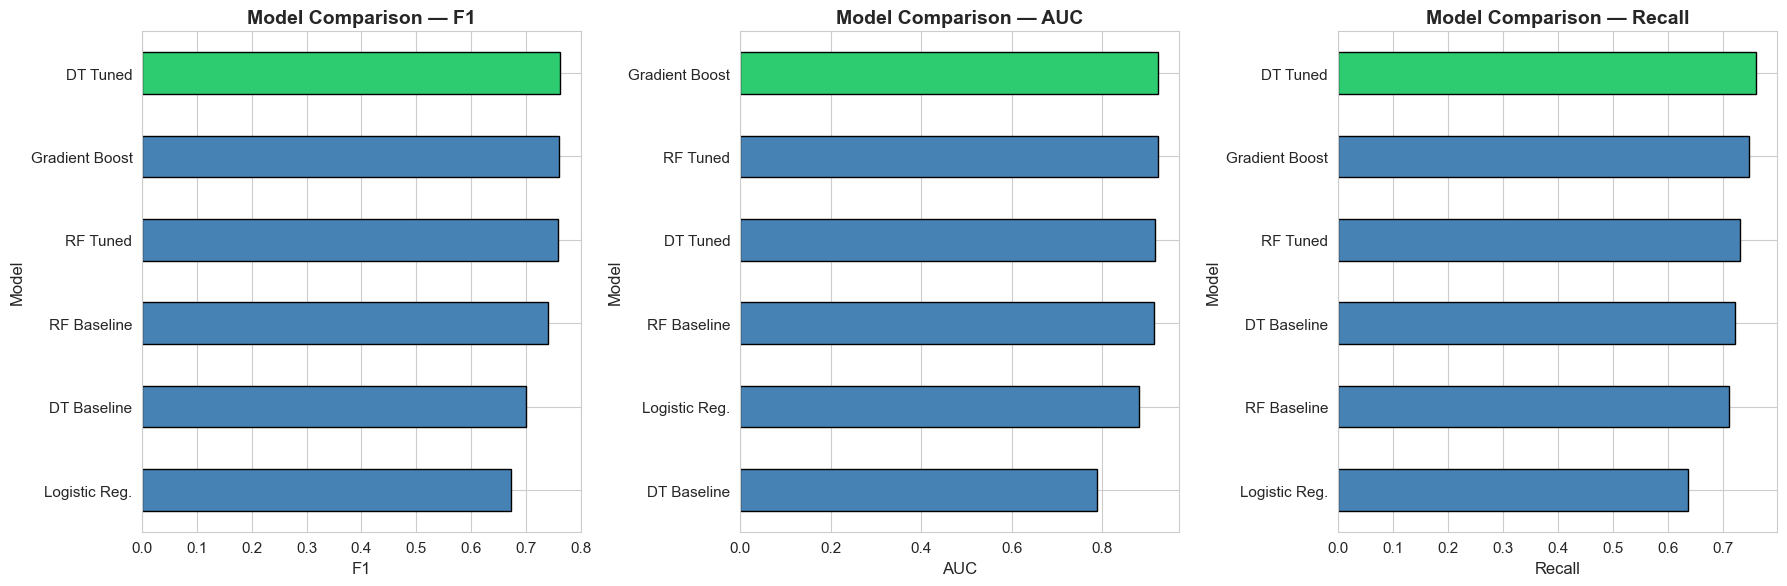

Saved: sec13_model_comparison_bars.png


In [45]:
# ------------------------------------------------------------------
# 13b: Visual comparison — bar chart of key metrics
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_to_plot = ["F1", "AUC", "Recall"]

for i, metric in enumerate(metrics_to_plot):
    data = comparison_df.sort_values(metric, ascending=True)
    colors_bar = ["#2ecc71" if v == data[metric].max() else "steelblue" for v in data[metric]]
    data.plot(kind="barh", x="Model", y=metric, ax=axes[i], color=colors_bar,
              edgecolor="black", legend=False)
    axes[i].set_title(f"Model Comparison — {metric}", fontweight="bold")
    axes[i].set_xlabel(metric)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec13_model_comparison_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sec13_model_comparison_bars.png")

### 13b — Model Comparison Visualizations

**Charts:** Three horizontal bar charts comparing all six models across the three metrics most relevant to this business problem: F1, AUC, and Recall. Models are sorted by performance (best at top). The green bar highlights the winner in each chart.

---

#### F1 Score (Left Chart)

| Rank | Model | F1 |
|---|---|---|
| 1 | **DT Tuned** (green) | 0.7631 |
| 2 | Gradient Boost | 0.7601 |
| 3 | RF Tuned | 0.7578 |
| 4 | RF Baseline | 0.7396 |
| 5 | DT Baseline | 0.6995 |
| 6 | Logistic Reg. | 0.6735 |

- The top 3 tuned tree-based models are visually almost indistinguishable — the 0.53pp spread is barely visible at this scale
- Clear separation between tuned models (0.76 tier) and baselines/LR (0.67–0.74 tier)
- The gap between LR and the tree models visually reinforces the cost of the linearity assumption

#### AUC (Center Chart)

| Rank | Model | AUC |
|---|---|---|
| 1 | **Gradient Boost** (green) | 0.9235 |
| 2 | RF Tuned | 0.9232 |
| 3 | DT Tuned | 0.9157 |
| 4 | RF Baseline | 0.9132 |
| 5 | Logistic Reg. | 0.8799 |
| 6 | DT Baseline | 0.7892 |

- GB and RF Tuned are essentially tied (0.03pp difference) — both produce excellent probability rankings
- DT Baseline is the clear outlier at the bottom — an overfit tree produces poor probability estimates even if it occasionally makes correct binary predictions
- LR ranks higher here (5th) than on F1 (6th) — its probability estimates are smoother and better calibrated than the DT Baseline, even though its classifications are worse than all tree models

#### Recall (Right Chart)

| Rank | Model | Recall |
|---|---|---|
| 1 | **DT Tuned** (green) | 0.7603 |
| 2 | Gradient Boost | 0.7482 |
| 3 | DT Baseline | 0.7215 |
| 4 | RF Tuned | 0.7312 |
| 5 | RF Baseline | 0.7119 |
| 6 | Logistic Reg. | 0.6368 |

- DT Tuned catches the most converters — critical if the business cost of missing a paying customer is high
- Both RF models rank lower on recall than on the other metrics — the forest's conservative voting mechanism favors precision over recall
- LR's recall (0.6368) is the weakest by a wide margin — it misses over a third of actual converters, making it unsuitable for deployment if converter catch rate matters

---

**Visual Takeaway:**
- **DT Tuned earns the green bar in 2 of 3 charts** (F1 and Recall) — strongest overall performer for binary classification
- **GB Tuned earns green in AUC** — best for probability-based lead scoring
- The visual clustering of the top 3 tuned models across all three charts reinforces the **F1 ≈ 0.76 performance ceiling** — the models agree on what's achievable with these features
- The consistent gap between tuned and untuned models across all charts makes a clear visual case: **always tune your hyperparameters**

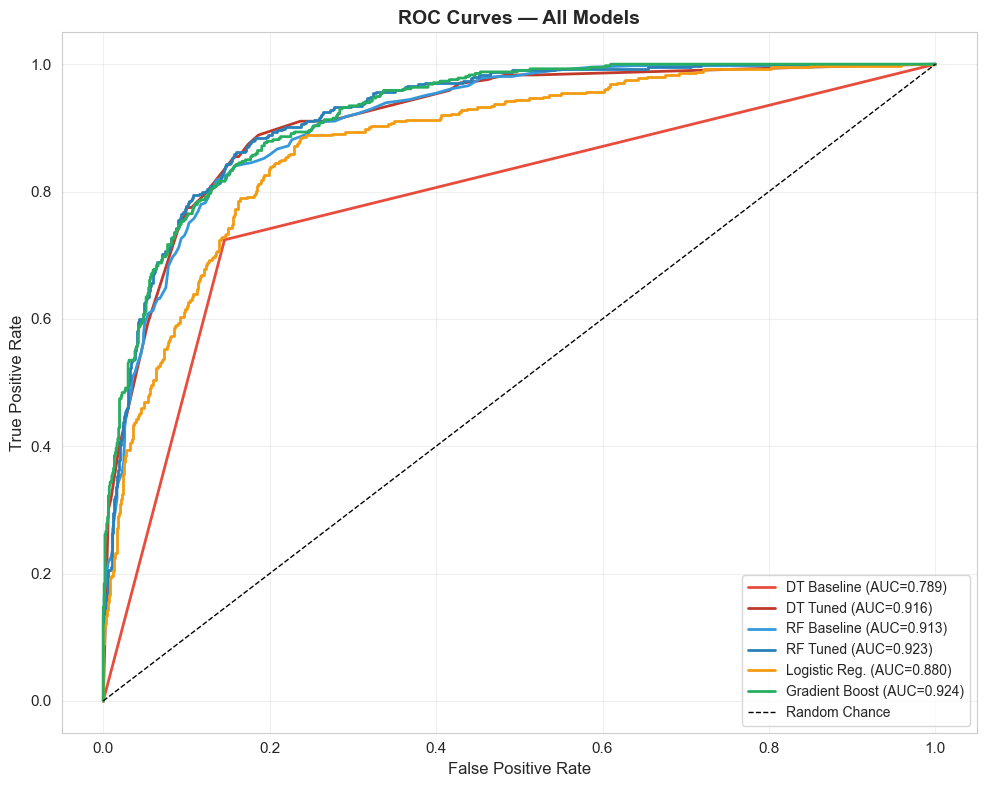

Saved: sec13_roc_curves_all_models.png


In [46]:
# ------------------------------------------------------------------
# 13c: ROC Curves — All Models Overlay
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

plot_colors = ["#e74c3c", "#c0392b", "#3498db", "#2980b9", "#f39c12", "#27ae60"]
for (name, (model, Xtr, Xte)), color in zip(all_models.items(), plot_colors):
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(Xte)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_val = roc_auc_score(y_test, y_proba)
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Chance")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec13_roc_curves_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sec13_roc_curves_all_models.png")

### 13c — ROC Curves — All Models

**Chart:** Overlay of all six models' ROC curves on a single plot, showing how each model trades off True Positive Rate (Recall) vs. False Positive Rate across every possible decision threshold. The dashed diagonal line represents random chance (AUC = 0.5).

---

#### AUC Rankings

| Rank | Model | AUC | Curve Color |
|---|---|---|---|
| 1 | Gradient Boost | 0.924 | Green |
| 2 | RF Tuned | 0.923 | Dark Blue |
| 3 | DT Tuned | 0.916 | Dark Red |
| 4 | RF Baseline | 0.913 | Light Blue |
| 5 | Logistic Reg. | 0.880 | Orange |
| 6 | DT Baseline | 0.789 | Red |

---

#### What the Overlay Reveals

**Top cluster (AUC 0.91–0.92): GB, RF Tuned, DT Tuned, RF Baseline**
- These four curves are tightly bundled in the upper-left region — visually almost overlapping
- At low False Positive Rates (0.0–0.1), they all achieve 60–80% True Positive Rate, meaning they catch the majority of converters while barely flagging any non-converters
- The near-identical curves confirm that once a tree-based model is reasonably configured, the ranking quality converges — the differences are in calibration and threshold behavior, not fundamental separation ability

**Logistic Regression (orange, AUC = 0.880)**
- Visibly below the top cluster, particularly in the 0.05–0.30 FPR range where it lags by 5–10pp on True Positive Rate
- The curve is the **smoothest** of all models — LR produces well-calibrated probability scores without the step-function jumps of tree models
- Despite lower AUC, the smooth curve means threshold tuning would produce more predictable tradeoffs than with tree models

**DT Baseline (red, AUC = 0.789)**
- The clear outlier — its curve bows significantly away from the top-left corner
- The **angular, staircase shape** is distinctive: an overfit depth-26 tree makes hard binary splits rather than nuanced probability estimates, producing abrupt jumps in the ROC curve
- The sharp elbow around FPR = 0.15 shows the model going from conservative (few predictions) to suddenly flagging many leads — there's no smooth middle ground
- This is the visual signature of overfitting: the model is confident but often wrong, producing poor probability rankings

---

#### Key Takeaway
- **Tuning transforms ROC performance:** DT Baseline (0.789) → DT Tuned (0.916) is a 12.7pp jump — the single largest improvement from any intervention in this project
- **The top 4 models form a performance band (0.91–0.92)** that likely represents the ceiling for this feature set — even the untuned RF Baseline (0.913) lands in this band, because the ensemble's voting naturally produces better probability estimates than a single overfit tree
- **For lead scoring (ranked probability lists), any of the top 4 models would perform similarly** — the business decision should be based on interpretability and deployment simplicity, not marginal AUC differences
- **LR's 4pp AUC gap below the tree cluster is the visual price of linearity** — the orange curve consistently underperforms where it matters most (low FPR region), missing converters that tree models catch through non-linear splits

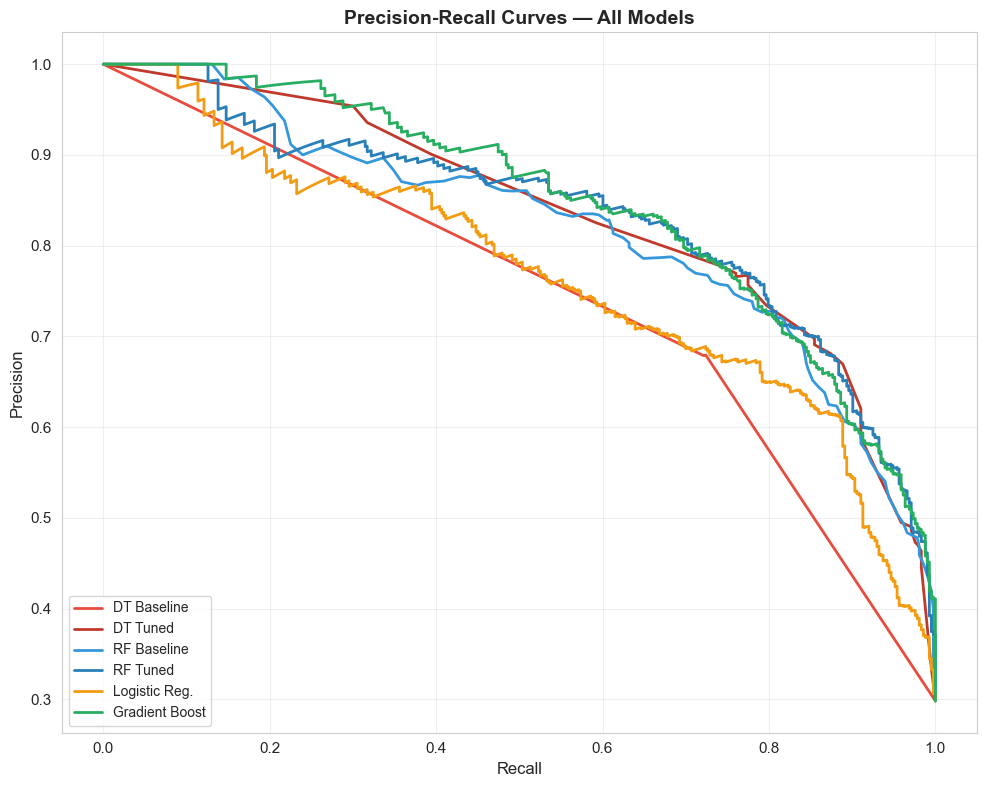

Saved: sec13_precision_recall_curves.png


In [47]:
# ------------------------------------------------------------------
# 13d: Precision-Recall Curves — All Models
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

for (name, (model, Xtr, Xte)), color in zip(all_models.items(), plot_colors):
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(Xte)[:, 1]
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
        ax.plot(recall_vals, precision_vals, color=color, lw=2, label=f"{name}")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower left", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec13_precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sec13_precision_recall_curves.png")

### 13d — Precision-Recall Curves — All Models

**Chart:** Overlay of all six models' Precision-Recall curves, showing how each model trades off Precision (y-axis) vs. Recall (x-axis) across every possible decision threshold. Unlike ROC curves which can look optimistic on imbalanced data, PR curves focus exclusively on the positive class (converters) — making them the more honest evaluation for our 70/30 class split.

**How to Read It:**
- The **top-right corner** is the ideal (perfect precision AND perfect recall) — but no real model reaches it
- Curves that stay **higher and further right** are better — they maintain high precision even as recall increases
- The downward slope is inevitable: as you lower the threshold to catch more converters (higher recall), you also flag more non-converters (lower precision)
- The **area under each curve** (not labeled, but visually apparent) indicates overall performance on the converter class

---

#### What the Overlay Reveals

**High-Precision Region (Recall 0.0–0.4):**
- All models start near Precision = 1.0 at very low recall — when they're extremely selective, the few leads they flag are almost always actual converters
- **RF Tuned and RF Baseline (blue curves) maintain the highest precision** in this region, staying above 0.95 out to Recall ≈ 0.2. The forest's voting mechanism produces the most confident positive predictions
- **DT Baseline (red) drops earliest** — its overfit probability estimates produce false positives even at conservative thresholds

**Critical Mid-Range (Recall 0.4–0.8):**
- This is where the models operate at their default 0.5 threshold and where business decisions are made
- **DT Tuned (dark red) and GB (green) hold the strongest curves** through this range — maintaining Precision ≈ 0.80–0.85 at Recall 0.5, and Precision ≈ 0.75 at Recall 0.7
- **LR (orange) falls below the pack** starting around Recall 0.4 — by Recall 0.6, its precision drops to approx. 0.75 while the tree models are still at 0.80+
- **DT Baseline (red) deteriorates steadily** — its precision at Recall 0.7 is approx. 0.68, the worst of any model at the recall level that matters most

**High-Recall Region (Recall 0.8–1.0):**
- All curves converge and decline sharply — this is where models sacrifice precision to catch the last remaining converters
- **RF Tuned (dark blue) maintains the best precision** even at extreme recall, staying above 0.60 at Recall 0.9
- All models drop to Precision ≈ 0.30–0.50 at Recall = 1.0 — meaning to catch every single converter, you'd flag 2–3× as many non-converters. This is the hard floor imposed by the 30% base conversion rate

---

#### Model-by-Model Assessment

| Model | Curve Behavior | Strength | Weakness |
|---|---|---|---|
| **DT Tuned** (dark red) | Smooth, consistent decline | Steady performance across the full recall range — no sudden drops | Slightly below RF in the high-precision region |
| **GB Tuned** (green) | Jagged but strong | Tracks closely with DT Tuned through the critical mid-range | Step-like drops create unpredictable precision at certain thresholds |
| **RF Tuned** (dark blue) | Highest overall envelope | Best precision retention at both low and high recall | Jagged steps — small threshold changes can cause large precision swings |
| **RF Baseline** (light blue) | Similar shape to RF Tuned | Strong in the high-precision region | Drops below tuned models in the mid-range |
| **LR** (orange) | Smooth but lower | Most predictable curve — threshold tuning produces consistent results | Consistently 5–10pp below tree models in the 0.4–0.8 recall range |
| **DT Baseline** (red) | Lowest overall | None in this comparison | Worst precision at every recall level — the cost of overfitting |

---

**Why PR Curves Matter More Than ROC Here:**
- Our dataset is 70% non-converters. ROC curves include True Negatives, which are easy to get right with a 70% majority class — this inflates AUC and makes models look better than they are for the task we care about (finding converters)
- PR curves focus entirely on converter detection: "When I flag a lead, is it really a converter (precision)?" and "Am I catching all the converters (recall)?"
- The visible spread between models on the PR plot is wider than on the ROC plot — PR curves are more discriminating for imbalanced classification problems

**Key Takeaway:**
- **DT Tuned and GB Tuned offer the best precision-recall tradeoff** through the business-relevant mid-range (Recall 0.5–0.8)
- **RF Tuned is the precision champion** — if the sales team has limited capacity and needs every flagged lead to count, RF maintains the highest precision at any given recall level
- **The convergence of all curves at the extremes** (Precision ≈ 1.0 at low recall, Precision ≈ 0.30 at full recall) defines the hard boundaries of what any model can achieve with these features — breaking through requires better data, not better algorithms

---
## Section 14 — Actionable Insights and Recommendations

Top Features Driving Lead Conversion (Tuned Random Forest):

   1. time_spent_on_website               — Importance: 0.2465
   2. first_interaction_Website           — Importance: 0.2410
   3. profile_completed                   — Importance: 0.1343
   4. engagement_score                    — Importance: 0.0725
   5. age                                 — Importance: 0.0698
   6. page_views_per_visit                — Importance: 0.0593
   7. last_activity_Phone Activity        — Importance: 0.0353
   8. website_visits                      — Importance: 0.0311
   9. current_occupation_Unemployed       — Importance: 0.0283
  10. current_occupation_Student          — Importance: 0.0239


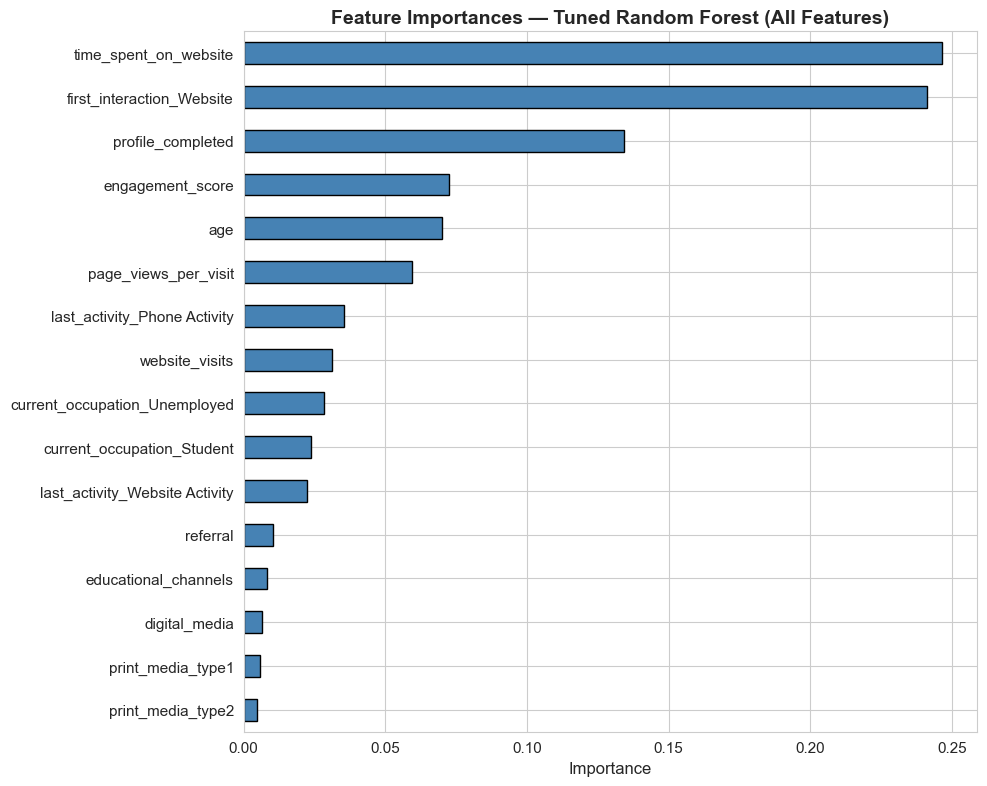


Saved: sec14_feature_importance_final.png, sec14_final_feature_importance.csv


In [48]:
# ------------------------------------------------------------------
# 14a: Consolidated Feature Importance (from best model)
# ------------------------------------------------------------------
best_rf_fi = pd.Series(rf_tuned.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print("Top Features Driving Lead Conversion (Tuned Random Forest):\n")
for i, (feat, imp) in enumerate(best_rf_fi.head(10).items(), 1):
    print(f"  {i:2d}. {feat:35s} — Importance: {imp:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
best_rf_fi.sort_values(ascending=True).plot(kind="barh", color="steelblue", edgecolor="black", ax=ax)
ax.set_title("Feature Importances — Tuned Random Forest (All Features)", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}sec14_feature_importance_final.png", dpi=150, bbox_inches="tight")
plt.show()

best_rf_fi.to_csv(f"{DATA_DIR}sec14_final_feature_importance.csv")
print("\nSaved: sec14_feature_importance_final.png, sec14_final_feature_importance.csv")

### 14 — Actionable Insights: Top Features Driving Lead Conversion

**Chart:** Horizontal bar chart showing feature importances from the Tuned Random Forest across all 17 features. Importance values represent how much each feature contributed to the ensemble's splitting decisions, summing to 1.0 across all features.

**Why Random Forest for Feature Importance?**
- RF was chosen for this summary because it distributes importance more evenly than a single Decision Tree (which concentrates importance on its few splits) and more honestly than Gradient Boosting (where sequential correction can inflate importance of features used for error recovery)
- RF's random feature subsampling forces every feature to compete on its own merit across 100 independent trees — producing the most stable importance estimates

---

#### Top 10 Features

| Rank | Feature | Importance | Cumulative | Business Interpretation |
|---|---|---|---|---|
| 1 | `time_spent_on_website` | 0.2465 | 24.7% | **Strongest signal.** Leads who spend more time (> 7 min) are exploring content seriously — time is the clearest proxy for genuine interest |
| 2 | `first_interaction_Website` | 0.2410 | 48.8% | **Channel matters.** Website-first leads convert at 4.3× the rate of Mobile App-first leads. The website likely provides richer content or a better conversion funnel |
| 3 | `profile_completed` | 0.1343 | 62.2% | **Intent indicator.** Higher profile completion signals commitment — leads who invest effort in their profile are signaling they're serious about enrolling |
| 4 | `engagement_score` | 0.0725 | 69.4% | Composite feature combining visits, time, and page views. Useful but flawed weighting (see Section 05d caveat) |
| 5 | `age` | 0.0698 | 76.4% | Older / professional-age leads more likely to convert — likely tied to employment funding and career motivation |
| 6 | `page_views_per_visit` | 0.0593 | 82.3% | Browsing depth — leads exploring multiple pages per session are evaluating the offering more thoroughly |
| 7 | `last_activity_Phone Activity` | 0.0353 | 85.9% | Phone engagement signals high intent — leads who call or answer calls are further down the funnel |
| 8 | `website_visits` | 0.0311 | 89.0% | Repeat visits indicate sustained interest, though less predictive than time per visit |
| 9 | `current_occupation_Unemployed` | 0.0283 | 91.8% | Occupation status affects conversion — unemployed leads may lack funding or urgency compared to employed professionals |
| 10 | `current_occupation_Student` | 0.0239 | 94.1% | Students less likely to convert — possibly already enrolled elsewhere or lacking financial resources |

---

#### Three Natural Tiers

**Tier 1 — Primary Drivers (62.2% of total importance):**
- `time_spent_on_website`, `first_interaction_Website`, `profile_completed`
- These three features alone explain nearly two-thirds of the model's decisions
- **Business action:** Optimize website content to increase time-on-site, invest in the website channel over mobile app, and encourage profile completion early in the lead journey

**Tier 2 — Supporting Signals (27.8% of total importance):**
- `engagement_score`, `age`, `page_views_per_visit`, `last_activity_Phone Activity`, `website_visits`, `current_occupation_Unemployed`, `current_occupation_Student`
- These add nuance but don't drive decisions independently
- **Business action:** Use for lead scoring refinement — a professional-age lead with phone activity and high page views is a stronger candidate than a young student with a single visit

**Tier 3 — Minimal Contribution (< 6% combined):**
- `last_activity_Website Activity`, `referral`, `educational_channels`, `digital_media`, `print_media_type1`, `print_media_type2`
- Marketing channel features contribute almost nothing to prediction across every model tested
- **Business action:** This does NOT mean these channels are useless — it means the binary yes/no tracking of channel exposure doesn't capture enough information. Future data should track channel content, frequency, and sequence (see recommendations below)

---

#### Strategic Recommendations

**1. Invest in the Website Experience**
- The top 2 features are both website-related (48.8% combined importance). Every improvement to website content, navigation, and conversion flow directly impacts the model's strongest predictors
- Investigate why Website-first leads convert at 4.3× vs. Mobile App — is it content parity, UX differences, or audience self-selection?

**2. Treat Profile Completion as a Conversion Funnel Stage**
- Profile completion is the #3 driver (13.4%). Implement progressive profiling — prompt leads to complete their profile in stages, using each step as a signal of increasing intent
- The 8 Low-profile leads who still converted (Section 05e discussion) suggest some conversions happen through phone sales bypassing the profile — track this pathway separately

**3. Prioritize Phone Outreach for High-Time Leads**
- `last_activity_Phone Activity` ranks #7 overall but is a key split in the Decision Tree's highest-conversion path (81% conversion rate in Section 08c)
- Target phone outreach to leads who've already spent > 7 minutes on the website and completed their profile — these are the warmest leads

**4. Segment by Occupation and Age**
- Professionals and working-age leads convert at higher rates. Consider tailored messaging: career advancement for professionals, employer-sponsored financing for employed leads, scholarship information for students
- Age and occupation combined account for 9.4% of importance — meaningful for segmentation even if not primary drivers

**5. Redesign Marketing Channel Tracking**
- All five marketing channel features combined contribute < 3% of importance — not because marketing doesn't matter, but because binary exposure flags are too coarse
- Future tracking should capture: which specific content was shown, how many times, through what sequence, and what the lead did after exposure (see context.md for full 12-point data recommendation list)

In [49]:
# ------------------------------------------------------------------
# 14b: Lead Conversion Profile
# ------------------------------------------------------------------
print("=" * 60)
print("  LEAD CONVERSION PROFILE")
print("=" * 60)
print()
print("Based on the analysis, leads most likely to convert share these traits:")
print()

# Profile from original data
converted = df[df["status"] == 1]
not_converted = df[df["status"] == 0]

print("DEMOGRAPHIC PROFILE:")
print(f"  - Top occupation among converted: {converted['current_occupation'].mode()[0]}")
print(f"  - Average age (converted): {converted['age'].mean():.1f} vs (not converted): {not_converted['age'].mean():.1f}")
print()
print("ENGAGEMENT PROFILE:")
print(f"  - Avg time on website (converted): {converted['time_spent_on_website'].mean():.0f}s vs (not): {not_converted['time_spent_on_website'].mean():.0f}s")
print(f"  - Avg website visits (converted): {converted['website_visits'].mean():.1f} vs (not): {not_converted['website_visits'].mean():.1f}")
print(f"  - Avg page views/visit (converted): {converted['page_views_per_visit'].mean():.2f} vs (not): {not_converted['page_views_per_visit'].mean():.2f}")
print()
print("INTERACTION PROFILE:")
print(f"  - Top first interaction (converted): {converted['first_interaction'].mode()[0]}")
print(f"  - Top last activity (converted): {converted['last_activity'].mode()[0]}")
print(f"  - Top profile completion (converted): {converted['profile_completed'].mode()[0]}")
print()

# Channel exposure comparison
print("MARKETING CHANNEL EXPOSURE (Converted vs Not Converted):")
for col in ["print_media_type1", "print_media_type2", "digital_media", "educational_channels", "referral"]:
    conv_rate = (converted[col] == "Yes").mean() * 100 if converted[col].dtype == "object" else converted[col].mean() * 100
    notc_rate = (not_converted[col] == "Yes").mean() * 100 if not_converted[col].dtype == "object" else not_converted[col].mean() * 100
    print(f"  - {col:25s}: Converted={conv_rate:.1f}%  |  Not Converted={notc_rate:.1f}%")

  LEAD CONVERSION PROFILE

Based on the analysis, leads most likely to convert share these traits:

DEMOGRAPHIC PROFILE:
  - Top occupation among converted: Professional
  - Average age (converted): 48.7 vs (not converted): 45.2

ENGAGEMENT PROFILE:
  - Avg time on website (converted): 1068s vs (not): 577s
  - Avg website visits (converted): 3.5 vs (not): 3.6
  - Avg page views/visit (converted): 3.03 vs (not): 3.03

INTERACTION PROFILE:
  - Top first interaction (converted): Website
  - Top last activity (converted): Email Activity
  - Top profile completion (converted): High

MARKETING CHANNEL EXPOSURE (Converted vs Not Converted):
  - print_media_type1        : Converted=11.5%  |  Not Converted=10.4%
  - print_media_type2        : Converted=5.4%  |  Not Converted=4.9%
  - digital_media            : Converted=12.2%  |  Not Converted=11.1%
  - educational_channels     : Converted=14.3%  |  Not Converted=15.7%
  - referral                 : Converted=4.6%  |  Not Converted=0.9%


### 14b — Lead Conversion Profile

**Purpose:** Translate the model's feature importances into a concrete profile of who converts — moving from "which features matter" to "what does a typical converter look like."

---

#### Demographic Profile

| Attribute | Converted | Not Converted | Gap | Insight |
|---|---|---|---|---|
| **Top Occupation** | Professional | — | — | Professionals convert at the highest rate — likely have employer funding and career advancement motivation |
| **Average Age** | 48.7 | 45.2 | +3.5 years | Converters skew older — mid-career professionals investing in upskilling, not early-career explorers |

#### Engagement Profile

| Attribute | Converted | Not Converted | Gap | Insight |
|---|---|---|---|---|
| **Avg Time on Website** | 1,068s (17.8 min) | 577s (9.6 min) | **+491s (8.2 min)** | Converters spend nearly **double** the time — the single clearest behavioral separator |
| **Avg Website Visits** | 3.5 | 3.6 | −0.1 | Virtually identical — visit frequency is not a differentiator. It's what they do per visit that matters |
| **Avg Page Views/Visit** | 3.03 | 3.03 | 0.00 | Identical — browsing depth per session doesn't separate converters. This explains why `page_views_per_visit` and `website_visits` rank low in feature importance |

#### Interaction Profile

| Attribute | Converted | Not Converted | Insight |
|---|---|---|---|
| **Top First Interaction** | Website | — | Website-first leads convert at 4.3× the rate of Mobile App-first (Section Q2). The website provides a richer experience for serious evaluation |
| **Top Last Activity** | Email Activity | — | Email as the final touchpoint before conversion — suggests the nurture sequence is working for leads already engaged |
| **Top Profile Completion** | High | — | High-profile leads convert at the highest rate — completing the profile signals commitment and readiness |

#### Marketing Channel Exposure

| Channel | Converted | Not Converted | Gap | Insight |
|---|---|---|---|---|
| `print_media_type1` | 11.5% | 10.4% | +1.1pp | Negligible difference |
| `print_media_type2` | 5.4% | 4.9% | +0.5pp | Negligible difference |
| `digital_media` | 12.2% | 11.1% | +1.1pp | Negligible difference |
| `educational_channels` | 14.3% | 15.7% | **−1.4pp** | Converters are *less* exposed — the educational channel dip flagged in Section Q4 persists here |
| `referral` | 4.6% | 0.9% | **+3.7pp** | Referrals are 5× more common among converters — small volume but high-intent channel |

- Marketing channels show almost no difference between converters and non-converters — consistent with all models ranking these features at the bottom
- The `referral` exception is notable: while only 4.6% of converters were referred, that's 5× the rate of non-converters. Referral is a low-volume, high-signal channel
- The `educational_channels` negative gap warrants investigation (recommended in Section Q4) — what content on educational channels might be dissuading leads?

---

### Key Takeaways & Business Recommendations

#### What Drives Conversion (Ranked by Model Importance)

**1. Time Spent on Website (24.7% importance)**
- Converters average 17.8 minutes vs. 9.6 minutes for non-converters — nearly double
- **Action:** Invest in engaging content, interactive demos, program comparison tools, and clear CTAs that reward extended browsing. Implement exit-intent interventions for leads showing high time-on-site but not converting
- **Quick win:** Set up a real-time alert when a lead crosses the 7-minute threshold (the DT root split from Section 08c) — this is the moment they shift from browsing to evaluating

**2. First Interaction Channel (24.1% importance)**
- Website-first leads convert at 4.3× the rate of Mobile App-first leads
- **Action:** Audit the mobile app experience — is it missing content, CTAs, or program details that the website provides? Ensure feature parity or redirect mobile users to the full website for serious evaluation
- **Test:** A/B test whether the channel causes higher conversion or simply attracts a self-selected higher-intent audience. Run identical content across both channels and measure conversion rates

**3. Profile Completion (13.4% importance)**
- High-profile leads convert at the highest rate; Low-profile leads rarely convert (Section Q5)
- **Action:** Implement progressive profiling with incentives — unlock a free workshop after 50% completion, a program consultation after 75%. Use email nudges for partial profiles
- **Caveat:** Profile completion is a proxy for intent, not a cause. Forcing completion won't create intent — the goal is to make completion easy and rewarding for leads who already have it

**4. Age & Occupation (9.4% combined importance)**
- Professionals aged 48+ are the highest-converting segment — mid-career upskilling with employer funding
- **Action:** Create tailored messaging by segment: career advancement for professionals, employer-sponsored financing for employed leads, scholarship or financial aid information for students and unemployed leads
- **Action:** Explore tracking employer education benefits as a data field (context.md recommendation #2)

**5. Phone Activity (3.5% importance, but 81% conversion in DT path)**
- Low overall importance but appears in the Decision Tree's highest-conversion path: high time + website first + phone activity + age > 25 = 81% conversion
- **Action:** Prioritize phone outreach for leads matching the warm profile (> 7 min on site, website-first, completed profile). Don't cold-call low-engagement leads — the phone is a closing tool, not a prospecting tool
- **Future data:** Track phone call outcomes (connected, voicemail, callback requested) to refine this signal (context.md recommendation #8)

**6. Referral Channel (low importance, high conversion rate)**
- Only 2% of all leads come through referral, but they convert at 67.7% — the highest of any channel
- **Action:** Build a formal referral program — if current students/alumni can refer new leads, this is the highest-ROI acquisition channel. The low volume is the problem, not the quality

#### What Doesn't Drive Conversion

**Marketing Channel Flags (< 3% combined importance)**
- All five binary channel flags (`print_media_type1/2`, `digital_media`, `educational_channels`, `referral`) contribute almost nothing to prediction
- **This doesn't mean marketing is useless** — it means binary yes/no exposure tracking is too coarse to capture marketing's real effect
- **Action:** Redesign marketing analytics to track: which specific content was shown, how many impressions, through what sequence, and what the lead did after exposure

#### Deploying the Model

**Recommended model: Decision Tree (Tuned)**
- Best F1 (0.7631), smallest train-test gap (1.1pp), most stable CV (± 0.0159), and fully interpretable at depth 5
- **Implementation:** Score incoming leads in real-time. Route high-probability leads (> 0.7 predicted conversion probability) to senior sales reps for personalized outreach. Automate nurture email sequences for medium-probability leads (0.4–0.7). Deprioritize low-probability leads (< 0.4) to save sales team capacity
- **Alternative:** Use Gradient Boosting (best AUC = 0.9235) if the business prefers a ranked lead list over binary classification — GB produces the most calibrated probability estimates for sorting leads from most to least likely to convert

#### Breaking Through the F1 ≈ 0.76 Ceiling

All three tuned tree-based models converge to F1 ≈ 0.76 — the bottleneck is data, not algorithms. To improve:

- **Richer features:** IP geolocation, session-level time data, page-level visit tracking, profile field content, phone call outcomes, device journey tracking (see context.md for full 12-point recommendation list)
- **More samples:** 4,612 leads is modest — a larger dataset would allow models to learn finer-grained patterns
- **Threshold tuning:** Adjusting the 0.5 probability cutoff based on the business cost of false positives vs. false negatives could improve effective F1 without changing the model
- **Educational channel audit:** Investigate what content on educational channels correlates with the −1.4pp conversion dip — is it setting wrong expectations, attracting non-target audiences, or providing enough information that leads self-disqualify?

In [50]:
# ------------------------------------------------------------------
# 14c: Final output summary
# ------------------------------------------------------------------
print("=" * 60)
print("  OUTPUT FILES SUMMARY")
print("=" * 60)
print()

import glob

print("IMAGES (data/outputs/images/):")
for f in sorted(glob.glob(f"{IMG_DIR}*.png")):
    print(f"  {os.path.basename(f)}")

print()
print("DATA (data/outputs/data/):")
for f in sorted(glob.glob(f"{DATA_DIR}*.csv")):
    print(f"  {os.path.basename(f)}")

print()
print("Notebook complete. Ready for HTML export.")

  OUTPUT FILES SUMMARY

IMAGES (data/outputs/images/):
  sec03_categorical_distributions.png
  sec03_numeric_distributions.png
  sec03_target_distribution.png
  sec04_correlation_heatmap.png
  sec04_numeric_vs_status_boxplots.png
  sec04_q1_occupation_vs_status.png
  sec04_q2_first_interaction_vs_status.png
  sec04_q3_last_activity_vs_status.png
  sec04_q4_marketing_channels.png
  sec04_q5_profile_completion_vs_status.png
  sec07_dt_baseline_evaluation.png
  sec07_dt_baseline_tree_viz.png
  sec08_dt_tuned_evaluation.png
  sec08_dt_tuned_tree_viz.png
  sec09_rf_baseline_evaluation.png
  sec10_rf_tuned_evaluation.png
  sec11_lr_tuned_evaluation.png
  sec12_gb_tuned_evaluation.png
  sec13_model_comparison_bars.png
  sec13_precision_recall_curves.png
  sec13_roc_curves_all_models.png
  sec14_feature_importance_final.png

DATA (data/outputs/data/):
  sec02_data_overview_summary.csv
  sec04_channel_conversion_rates.csv
  sec04_chi2_test_results.csv
  sec04_mannwhitney_test_results.csv
  sec0